<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/risk_classifier_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# CELL 1 — GOOGLE DRIVE + TRAINING PATH SETUP
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

from google.colab import drive

import os


# =========================================================
# 1. MOUNT GOOGLE DRIVE
# =========================================================

DRIVE_MOUNT = "/content/drive"

drive.mount(
    DRIVE_MOUNT,
    force_remount=False
)

assert os.path.exists(
    f"{DRIVE_MOUNT}/MyDrive"
), "Google Drive belum mounted"


# =========================================================
# 2. STORAGE DIRECTORY
# =========================================================

SAVE_DIR = (
    f"{DRIVE_MOUNT}/MyDrive/command_risk"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)


# =========================================================
# 3. SUBDIRECTORIES
# =========================================================

RAW_DIR = (
    f"{SAVE_DIR}/raw"
)

PROCESSED_DIR = (
    f"{SAVE_DIR}/processed"
)

TEACHER_DIR = (
    f"{SAVE_DIR}/teacher"
)

TRUSTED_DIR = (
    f"{SAVE_DIR}/trusted"
)

SYNTHETIC_DIR = (
    f"{SAVE_DIR}/synthetic"
)

REPAIR_DIR = (
    f"{SAVE_DIR}/repair"
)

BLIND_TEST_DIR = (
    f"{SAVE_DIR}/blind_test"
)

MODEL_DIR = (
    f"{SAVE_DIR}/models"
)

ONNX_DIR = (
    f"{MODEL_DIR}/onnx"
)

REPORT_DIR = (
    f"{SAVE_DIR}/reports"
)

FEATURE_DIR = (
    f"{SAVE_DIR}/features"
)


for directory in [
    RAW_DIR,
    PROCESSED_DIR,
    TEACHER_DIR,
    TRUSTED_DIR,
    SYNTHETIC_DIR,
    REPAIR_DIR,
    BLIND_TEST_DIR,
    MODEL_DIR,
    ONNX_DIR,
    REPORT_DIR,
    FEATURE_DIR,
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


# =========================================================
# 4. MODEL 01 SOURCE PATHS
# =========================================================

ACTION_CLASSIFIER_DIR = (
    f"{DRIVE_MOUNT}/MyDrive/action_classifier"
)

ACTION_TRUSTED_PATH = (
    f"{ACTION_CLASSIFIER_DIR}/trusted/"
    "action_classifier_trusted_v1.jsonl"
)

ACTION_MODEL_DIR = (
    f"{ACTION_CLASSIFIER_DIR}/models"
)

ACTION_ONNX_PATH = (
    f"{ACTION_MODEL_DIR}/onnx/"
    "action_classifier.onnx"
)


# =========================================================
# 5. COMMAND RISK DATASET PATHS
# =========================================================

RAW_CORPUS_PATH = (
    f"{RAW_DIR}/command_risk_raw_v1.jsonl"
)

NORMALIZED_DATASET_PATH = (
    f"{PROCESSED_DIR}/normalized_dataset_v1.jsonl"
)

DEDUP_DATASET_PATH = (
    f"{PROCESSED_DIR}/dedup_dataset_v1.jsonl"
)

STATIC_FEATURES_PATH = (
    f"{FEATURE_DIR}/static_features_v1.jsonl"
)

ACTION_FEATURES_PATH = (
    f"{FEATURE_DIR}/action_features_v1.jsonl"
)

TEACHER_LABELED_PATH = (
    f"{TEACHER_DIR}/teacher_labeled_v1.jsonl"
)

TEACHER_REJECTED_PATH = (
    f"{TEACHER_DIR}/teacher_rejected_v1.jsonl"
)

SYNTHETIC_DATASET_PATH = (
    f"{SYNTHETIC_DIR}/synthetic_risk_v1.jsonl"
)

TRUSTED_TRAIN_PATH = (
    f"{TRUSTED_DIR}/command_risk_trusted_v1.jsonl"
)

REPAIR_DATASET_PATH = (
    f"{REPAIR_DIR}/targeted_repair_v1.jsonl"
)

BLIND_TEST_PATH = (
    f"{BLIND_TEST_DIR}/blind_test_v1.jsonl"
)


# =========================================================
# 6. MODEL OUTPUT PATHS
# =========================================================

MODEL_PATH = (
    f"{MODEL_DIR}/command_risk.joblib"
)

BEST_MODEL_PATH = (
    f"{MODEL_DIR}/command_risk_best.joblib"
)

VECTORIZER_PATH = (
    f"{MODEL_DIR}/command_risk_vectorizer.joblib"
)

FEATURE_CONFIG_PATH = (
    f"{MODEL_DIR}/feature_config.json"
)

ONNX_MODEL_PATH = (
    f"{ONNX_DIR}/command_risk.onnx"
)


# =========================================================
# 7. REPORT PATHS
# =========================================================

METRICS_PATH = (
    f"{REPORT_DIR}/training_metrics.json"
)

PREDICTIONS_PATH = (
    f"{REPORT_DIR}/test_predictions.csv"
)

ERROR_ANALYSIS_PATH = (
    f"{REPORT_DIR}/error_analysis.csv"
)

LABEL_DISTRIBUTION_PATH = (
    f"{REPORT_DIR}/label_distribution.csv"
)

CONFUSION_MATRIX_PATH = (
    f"{REPORT_DIR}/confusion_matrix.csv"
)

ONNX_PARITY_PATH = (
    f"{REPORT_DIR}/onnx_parity.json"
)

BENCHMARK_PATH = (
    f"{REPORT_DIR}/latency_benchmark.json"
)


# =========================================================
# 8. BASIC VALIDATION
# =========================================================

assert os.path.exists(
    SAVE_DIR
)

assert os.path.exists(
    MODEL_DIR
)

assert os.path.exists(
    REPORT_DIR
)


# =========================================================
# 9. STATUS
# =========================================================

print()
print("=" * 70)
print("MODEL 02 — COMMAND RISK CLASSIFIER STORAGE")
print("=" * 70)

print(
    "SAVE_DIR          :",
    SAVE_DIR
)

print(
    "Model 01 corpus   :",
    ACTION_TRUSTED_PATH
)

print(
    "Raw corpus        :",
    RAW_CORPUS_PATH
)

print(
    "Teacher labeled   :",
    TEACHER_LABELED_PATH
)

print(
    "Synthetic data    :",
    SYNTHETIC_DATASET_PATH
)

print(
    "Trusted train     :",
    TRUSTED_TRAIN_PATH
)

print(
    "Repair dataset    :",
    REPAIR_DATASET_PATH
)

print(
    "Best model        :",
    BEST_MODEL_PATH
)

print(
    "ONNX model        :",
    ONNX_MODEL_PATH
)

print(
    "Metrics           :",
    METRICS_PATH
)

print("=" * 70)

Mounted at /content/drive

MODEL 02 — COMMAND RISK CLASSIFIER STORAGE
SAVE_DIR          : /content/drive/MyDrive/command_risk
Model 01 corpus   : /content/drive/MyDrive/action_classifier/trusted/action_classifier_trusted_v1.jsonl
Raw corpus        : /content/drive/MyDrive/command_risk/raw/command_risk_raw_v1.jsonl
Teacher labeled   : /content/drive/MyDrive/command_risk/teacher/teacher_labeled_v1.jsonl
Synthetic data    : /content/drive/MyDrive/command_risk/synthetic/synthetic_risk_v1.jsonl
Trusted train     : /content/drive/MyDrive/command_risk/trusted/command_risk_trusted_v1.jsonl
Repair dataset    : /content/drive/MyDrive/command_risk/repair/targeted_repair_v1.jsonl
Best model        : /content/drive/MyDrive/command_risk/models/command_risk_best.joblib
ONNX model        : /content/drive/MyDrive/command_risk/models/onnx/command_risk.onnx
Metrics           : /content/drive/MyDrive/command_risk/reports/training_metrics.json


In [2]:
# =========================================================
# CELL 2 — DEPENDENCIES + IMPORTS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

!pip install -q \
    pandas \
    numpy \
    scipy \
    scikit-learn \
    joblib \
    requests \
    tqdm


# =========================================================
# 1. STANDARD LIBRARY
# =========================================================

import os
import re
import json
import time
import random
import hashlib
import shlex

from pathlib import Path
from collections import Counter, defaultdict


# =========================================================
# 2. DATA
# =========================================================

import numpy as np
import pandas as pd


# =========================================================
# 3. SCIKIT-LEARN
# =========================================================

from sklearn.model_selection import (
    train_test_split,
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
)

from sklearn.preprocessing import (
    StandardScaler,
)

from sklearn.linear_model import (
    LogisticRegression,
)

from sklearn.svm import (
    LinearSVC,
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

from scipy.sparse import (
    csr_matrix,
    hstack,
)

import joblib


# =========================================================
# 4. UTILITIES
# =========================================================

import requests

from tqdm.auto import tqdm


# =========================================================
# 5. RANDOM SEED
# =========================================================

RANDOM_SEED = 42

random.seed(
    RANDOM_SEED
)

np.random.seed(
    RANDOM_SEED
)


# =========================================================
# 6. PROJECT CONFIG
# =========================================================

MODEL_NAME = "command_risk_classifier"

MODEL_VERSION = "v1"


# =========================================================
# 7. STATUS
# =========================================================

print()
print("=" * 70)
print("MODEL 02 — DEPENDENCIES READY")
print("=" * 70)

print("Model       :", MODEL_NAME)
print("Version     :", MODEL_VERSION)
print("Random seed :", RANDOM_SEED)
print("SAVE_DIR    :", SAVE_DIR)

print("=" * 70)


MODEL 02 — DEPENDENCIES READY
Model       : command_risk_classifier
Version     : v1
Random seed : 42
SAVE_DIR    : /content/drive/MyDrive/command_risk


In [3]:
# =========================================================
# CELL 3 — RISK TAXONOMY + FEATURE SCHEMA
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. RISK LABELS
# =========================================================

RISK_LABELS = [
    "BENIGN",
    "SUSPICIOUS",
    "DESTRUCTIVE",
]


# =========================================================
# 2. RISK TAXONOMY
# =========================================================

RISK_TAXONOMY = {

    "BENIGN": {
        "description": (
            "Low-risk shell command. Primarily reads information, "
            "performs ordinary local operations, or makes bounded "
            "changes without clear destructive intent."
        ),

        "examples": [
            "ls -la",
            "pwd",
            "cat /etc/os-release",
            "git status",
            "mkdir test_dir",
            "cp test.txt backup.txt",
            "python app.py",
        ],
    },

    "SUSPICIOUS": {
        "description": (
            "Potentially risky command that may still be legitimate. "
            "Requires additional review because it contains privilege "
            "use, network-to-execution behavior, shell spawning, "
            "encoded payloads, sensitive paths, command substitution, "
            "or other high-risk execution patterns."
        ),

        "examples": [
            "sudo systemctl restart nginx",
            "curl <TEST_URL> | bash",
            "wget <TEST_URL> -O- | sh",
            "echo <BASE64_DATA> | base64 -d | bash",
            "chmod +x script.sh && ./script.sh",
        ],
    },

    "DESTRUCTIVE": {
        "description": (
            "Command clearly intended or highly likely to cause "
            "irreversible or major damage such as deleting critical "
            "files, overwriting storage, formatting devices, or "
            "destroying system state."
        ),

        "examples": [
            "rm -rf /",
            "rm -rf /*",
            "mkfs.ext4 /dev/sda",
            "dd if=/dev/zero of=/dev/sda",
            "find / -delete",
        ],
    },
}


# =========================================================
# 3. ACTION CLASSIFIER LABELS
# =========================================================

ACTION_LABELS = [
    "READ",
    "WRITE",
    "DELETE",
    "EXECUTE",
    "NETWORK",
    "INSTALL",
    "PRIVILEGED",
    "SYSTEM_CHANGE",
]


# =========================================================
# 4. STATIC FEATURE SCHEMA
# =========================================================

STATIC_FEATURE_NAMES = [
    "sudo_present",
    "pipe_present",
    "redirect_present",

    "curl_present",
    "wget_present",

    "chmod_present",
    "eval_present",
    "base64_present",

    "recursive_delete",
    "wildcard_delete",

    "systemctl_present",
    "shell_spawn",

    "credential_path",
    "system_path",

    "network_access",

    # tambahan untuk chained-command analysis
    "command_chain_present",
    "command_substitution",
]


# =========================================================
# 5. VALIDATION
# =========================================================

assert len(RISK_LABELS) == len(set(RISK_LABELS))
assert len(ACTION_LABELS) == len(set(ACTION_LABELS))
assert len(STATIC_FEATURE_NAMES) == len(
    set(STATIC_FEATURE_NAMES)
)


# =========================================================
# 6. STATUS
# =========================================================

print()
print("=" * 70)
print("MODEL 02 — RISK TAXONOMY")
print("=" * 70)

for label in RISK_LABELS:

    print()
    print(f"[{label}]")

    print(
        RISK_TAXONOMY[label]["description"]
    )


print()
print("=" * 70)

print(
    "Risk labels     :",
    len(RISK_LABELS)
)

print(
    "Action labels   :",
    len(ACTION_LABELS)
)

print(
    "Static features :",
    len(STATIC_FEATURE_NAMES)
)

print("=" * 70)


MODEL 02 — RISK TAXONOMY

[BENIGN]
Low-risk shell command. Primarily reads information, performs ordinary local operations, or makes bounded changes without clear destructive intent.

[SUSPICIOUS]
Potentially risky command that may still be legitimate. Requires additional review because it contains privilege use, network-to-execution behavior, shell spawning, encoded payloads, sensitive paths, command substitution, or other high-risk execution patterns.

[DESTRUCTIVE]
Command clearly intended or highly likely to cause irreversible or major damage such as deleting critical files, overwriting storage, formatting devices, or destroying system state.

Risk labels     : 3
Action labels   : 8
Static features : 17


In [4]:
# =========================================================
# CELL 3 — RISK TAXONOMY + FEATURE SCHEMA
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. RISK LABELS
# =========================================================

RISK_LABELS = [
    "BENIGN",
    "SUSPICIOUS",
    "DESTRUCTIVE",
]


# =========================================================
# 2. RISK TAXONOMY
# =========================================================

RISK_TAXONOMY = {

    "BENIGN": {
        "description": (
            "Low-risk shell command. Primarily reads information, "
            "performs ordinary local operations, or makes bounded "
            "changes without clear destructive intent."
        ),

        "examples": [
            "ls -la",
            "pwd",
            "cat /etc/os-release",
            "git status",
            "mkdir test_dir",
            "cp test.txt backup.txt",
            "python app.py",
        ],
    },

    "SUSPICIOUS": {
        "description": (
            "Potentially risky command that may still be legitimate. "
            "Requires additional review because it contains privilege "
            "use, network-to-execution behavior, shell spawning, "
            "encoded payloads, sensitive paths, command substitution, "
            "or other high-risk execution patterns."
        ),

        "examples": [
            "sudo systemctl restart nginx",
            "curl <TEST_URL> | bash",
            "wget <TEST_URL> -O- | sh",
            "echo <BASE64_DATA> | base64 -d | bash",
            "chmod +x script.sh && ./script.sh",
        ],
    },

    "DESTRUCTIVE": {
        "description": (
            "Command clearly intended or highly likely to cause "
            "irreversible or major damage such as deleting critical "
            "files, overwriting storage, formatting devices, or "
            "destroying system state."
        ),

        "examples": [
            "rm -rf /",
            "rm -rf /*",
            "mkfs.ext4 /dev/sda",
            "dd if=/dev/zero of=/dev/sda",
            "find / -delete",
        ],
    },
}


# =========================================================
# 3. ACTION CLASSIFIER LABELS
# =========================================================

ACTION_LABELS = [
    "READ",
    "WRITE",
    "DELETE",
    "EXECUTE",
    "NETWORK",
    "INSTALL",
    "PRIVILEGED",
    "SYSTEM_CHANGE",
]


# =========================================================
# 4. STATIC FEATURE SCHEMA
# =========================================================

STATIC_FEATURE_NAMES = [
    "sudo_present",
    "pipe_present",
    "redirect_present",

    "curl_present",
    "wget_present",

    "chmod_present",
    "eval_present",
    "base64_present",

    "recursive_delete",
    "wildcard_delete",

    "systemctl_present",
    "shell_spawn",

    "credential_path",
    "system_path",

    "network_access",

    # tambahan untuk chained-command analysis
    "command_chain_present",
    "command_substitution",
]


# =========================================================
# 5. VALIDATION
# =========================================================

assert len(RISK_LABELS) == len(set(RISK_LABELS))
assert len(ACTION_LABELS) == len(set(ACTION_LABELS))
assert len(STATIC_FEATURE_NAMES) == len(
    set(STATIC_FEATURE_NAMES)
)


# =========================================================
# 6. STATUS
# =========================================================

print()
print("=" * 70)
print("MODEL 02 — RISK TAXONOMY")
print("=" * 70)

for label in RISK_LABELS:

    print()
    print(f"[{label}]")

    print(
        RISK_TAXONOMY[label]["description"]
    )


print()
print("=" * 70)

print(
    "Risk labels     :",
    len(RISK_LABELS)
)

print(
    "Action labels   :",
    len(ACTION_LABELS)
)

print(
    "Static features :",
    len(STATIC_FEATURE_NAMES)
)

print("=" * 70)


MODEL 02 — RISK TAXONOMY

[BENIGN]
Low-risk shell command. Primarily reads information, performs ordinary local operations, or makes bounded changes without clear destructive intent.

[SUSPICIOUS]
Potentially risky command that may still be legitimate. Requires additional review because it contains privilege use, network-to-execution behavior, shell spawning, encoded payloads, sensitive paths, command substitution, or other high-risk execution patterns.

[DESTRUCTIVE]
Command clearly intended or highly likely to cause irreversible or major damage such as deleting critical files, overwriting storage, formatting devices, or destroying system state.

Risk labels     : 3
Action labels   : 8
Static features : 17


In [5]:
# =========================================================
# CELL 4 — STATIC FEATURE EXTRACTOR
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. HELPER
# =========================================================

def regex_present(pattern, command):

    return int(
        re.search(
            pattern,
            command,
            flags=re.IGNORECASE,
        )
        is not None
    )


# =========================================================
# 2. FEATURE EXTRACTOR
# =========================================================

def extract_static_features(command):

    command = str(command).strip()

    command_lower = command.lower()


    features = {}


    # -----------------------------------------------------
    # PRIVILEGE
    # -----------------------------------------------------

    features["sudo_present"] = regex_present(
        r"(^|\s|[;&|])sudo(\s|$)",
        command,
    )


    # -----------------------------------------------------
    # SHELL COMPOSITION
    # -----------------------------------------------------

    features["pipe_present"] = int(
        "|" in command
    )

    features["redirect_present"] = int(
        bool(
            re.search(
                r"(>>?|<<?)",
                command,
            )
        )
    )

    features["command_chain_present"] = int(
        bool(
            re.search(
                r"(&&|\|\||;)",
                command,
            )
        )
    )

    features["command_substitution"] = int(
        "$(" in command
        or
        bool(
            re.search(
                r"`[^`]+`",
                command,
            )
        )
    )


    # -----------------------------------------------------
    # NETWORK
    # -----------------------------------------------------

    features["curl_present"] = regex_present(
        r"(^|\s|[;&|])curl(\s|$)",
        command,
    )

    features["wget_present"] = regex_present(
        r"(^|\s|[;&|])wget(\s|$)",
        command,
    )

    features["network_access"] = int(
        features["curl_present"]
        or
        features["wget_present"]
        or
        bool(
            re.search(
                r"\bhttps?://",
                command_lower,
            )
        )
        or
        regex_present(
            r"(^|\s)(ssh|scp|sftp|nc|ncat|netcat)(\s|$)",
            command,
        )
    )


    # -----------------------------------------------------
    # EXECUTION
    # -----------------------------------------------------

    features["chmod_present"] = regex_present(
        r"(^|\s|[;&|])chmod(\s|$)",
        command,
    )

    features["eval_present"] = regex_present(
        r"(^|\s|[;&|])eval(\s|$)",
        command,
    )

    features["shell_spawn"] = int(
        bool(
            re.search(
                r"(^|\s|[;&|])"
                r"(bash|sh|zsh|dash|ksh)"
                r"(\s|$)",
                command_lower,
            )
        )
    )


    # -----------------------------------------------------
    # ENCODING / OBFUSCATION
    # -----------------------------------------------------

    features["base64_present"] = regex_present(
        r"(^|\s|[;&|])base64(\s|$)",
        command,
    )


    # -----------------------------------------------------
    # DELETE PATTERNS
    # -----------------------------------------------------

    features["recursive_delete"] = int(
        bool(
            re.search(
                r"\brm\s+[^;&|]*-[a-z]*r[a-z]*f?",
                command_lower,
            )
        )
        or
        bool(
            re.search(
                r"\brm\s+[^;&|]*-[a-z]*f[a-z]*r",
                command_lower,
            )
        )
    )

    features["wildcard_delete"] = int(
        bool(
            re.search(
                r"\brm\b[^;&|]*[\*\?]",
                command_lower,
            )
        )
    )


    # -----------------------------------------------------
    # SYSTEM
    # -----------------------------------------------------

    features["systemctl_present"] = regex_present(
        r"(^|\s|[;&|])systemctl(\s|$)",
        command,
    )


    # -----------------------------------------------------
    # SENSITIVE PATHS
    # -----------------------------------------------------

    credential_patterns = [
        r"/\.ssh(?:/|\s|$)",
        r"\.ssh/",
        r"id_rsa",
        r"id_ed25519",
        r"\.aws/credentials",
        r"\.config/gcloud",
        r"/etc/shadow",
        r"/etc/passwd",
    ]

    features["credential_path"] = int(
        any(
            re.search(
                pattern,
                command_lower,
            )
            for pattern in credential_patterns
        )
    )


    system_patterns = [
        r"/etc/",
        r"/boot/",
        r"/usr/",
        r"/bin/",
        r"/sbin/",
        r"/lib/",
        r"/lib64/",
        r"/var/lib/",
        r"/dev/",
        r"/proc/",
        r"/sys/",
    ]

    features["system_path"] = int(
        any(
            re.search(
                pattern,
                command_lower,
            )
            for pattern in system_patterns
        )
    )


    # -----------------------------------------------------
    # ORDER VALIDATION
    # -----------------------------------------------------

    features = {
        name: int(
            features.get(
                name,
                0,
            )
        )
        for name in STATIC_FEATURE_NAMES
    }


    return features


# =========================================================
# 3. VECTOR CONVERSION
# =========================================================

def static_features_to_vector(features):

    return np.array(
        [
            features[name]
            for name in STATIC_FEATURE_NAMES
        ],
        dtype=np.float32,
    )


# =========================================================
# 4. SANITY TEST
# =========================================================

STATIC_TEST_COMMANDS = [
    "ls -la",
    "sudo systemctl restart nginx",
    "curl <TEST_URL> | bash",
    "rm -rf /tmp/test",
    "rm -rf /*",
    "cat ~/.ssh/id_ed25519",
    "echo test > /etc/test.conf",
]


for command in STATIC_TEST_COMMANDS:

    features = extract_static_features(
        command
    )

    active = [
        name
        for name, value
        in features.items()
        if value == 1
    ]

    print()
    print("COMMAND:")
    print(command)

    print(
        "FEATURES:",
        active
    )


COMMAND:
ls -la
FEATURES: []

COMMAND:
sudo systemctl restart nginx
FEATURES: ['sudo_present', 'systemctl_present']

COMMAND:
curl <TEST_URL> | bash
FEATURES: ['pipe_present', 'redirect_present', 'curl_present', 'shell_spawn', 'network_access']

COMMAND:
rm -rf /tmp/test
FEATURES: ['recursive_delete']

COMMAND:
rm -rf /*
FEATURES: ['recursive_delete', 'wildcard_delete']

COMMAND:
cat ~/.ssh/id_ed25519
FEATURES: ['credential_path']

COMMAND:
echo test > /etc/test.conf
FEATURES: ['redirect_present', 'system_path']


In [6]:
# =========================================================
# CELL 5 — LOAD TRUSTED CORPUS FROM MODEL 01
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. CHECK SOURCE
# =========================================================

print()
print("=" * 70)
print("LOADING MODEL 01 TRUSTED CORPUS")
print("=" * 70)

print(
    "Source:",
    ACTION_TRUSTED_PATH
)


assert os.path.exists(
    ACTION_TRUSTED_PATH
), (
    "Model 01 trusted dataset tidak ditemukan:\n"
    f"{ACTION_TRUSTED_PATH}"
)


# =========================================================
# 2. JSONL LOADER
# =========================================================

def load_jsonl(path):

    rows = []

    with open(
        path,
        "r",
        encoding="utf-8",
    ) as f:

        for line_number, line in enumerate(
            f,
            start=1,
        ):

            line = line.strip()

            if not line:
                continue

            try:

                rows.append(
                    json.loads(line)
                )

            except Exception as exc:

                print(
                    f"Invalid JSON line "
                    f"{line_number}: {exc}"
                )

    return rows


# =========================================================
# 3. LOAD
# =========================================================

action_rows = load_jsonl(
    ACTION_TRUSTED_PATH
)

print()
print(
    "Rows loaded:",
    len(action_rows)
)


assert len(action_rows) > 0, (
    "Trusted corpus Model 01 kosong"
)


# =========================================================
# 4. INSPECT SCHEMA
# =========================================================

print()
print("=" * 70)
print("SAMPLE RECORD")
print("=" * 70)

print(
    json.dumps(
        action_rows[0],
        indent=2,
        ensure_ascii=False,
    )
)


print()
print("=" * 70)
print("AVAILABLE KEYS")
print("=" * 70)

all_keys = sorted(
    {
        key
        for row in action_rows
        for key in row.keys()
    }
)

for key in all_keys:
    print("-", key)


# =========================================================
# 5. COMMAND FIELD DETECTION
# =========================================================

COMMAND_FIELD_CANDIDATES = [
    "command",
    "cmd",
    "text",
    "input",
    "description",
]


COMMAND_FIELD = None


for candidate in COMMAND_FIELD_CANDIDATES:

    if candidate in all_keys:

        COMMAND_FIELD = candidate

        break


assert COMMAND_FIELD is not None, (
    "Tidak menemukan field command. "
    "Periksa SAMPLE RECORD di atas."
)


print()
print(
    "Detected command field:",
    COMMAND_FIELD
)


# =========================================================
# 6. NORMALIZE INTO MODEL 02 RAW CORPUS
# =========================================================

risk_raw_rows = []


for index, row in enumerate(
    action_rows
):

    command = str(
        row.get(
            COMMAND_FIELD,
            "",
        )
    ).strip()


    if not command:
        continue


    item = {
        "id": (
            f"model01_{index:06d}"
        ),

        "command": command,

        "source": (
            "model01_trusted"
        ),

        "model01_record": row,
    }


    risk_raw_rows.append(
        item
    )


# =========================================================
# 7. SAVE RAW CORPUS
# =========================================================

with open(
    RAW_CORPUS_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in risk_raw_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 8. SUMMARY
# =========================================================

print()
print("=" * 70)
print("MODEL 02 RAW CORPUS READY")
print("=" * 70)

print(
    "Model 01 rows :",
    len(action_rows)
)

print(
    "Usable rows   :",
    len(risk_raw_rows)
)

print(
    "Command field :",
    COMMAND_FIELD
)

print(
    "Saved to      :",
    RAW_CORPUS_PATH
)

print("=" * 70)


LOADING MODEL 01 TRUSTED CORPUS
Source: /content/drive/MyDrive/action_classifier/trusted/action_classifier_trusted_v1.jsonl

Rows loaded: 3167

SAMPLE RECORD
{
  "command": "pip install requests",
  "description": "Install a Python package",
  "actions": [
    "NETWORK",
    "INSTALL",
    "SYSTEM_CHANGE"
  ],
  "confidence": 1.0,
  "ambiguous": false,
  "source": "manual_seed",
  "split_origin": "manual",
  "latency": null,
  "sampling_reason": null,
  "teacher_model": null,
  "valid_actions": null,
  "action_count": null,
  "label_combo": null
}

AVAILABLE KEYS
- action_count
- actions
- ambiguous
- command
- confidence
- description
- label_combo
- latency
- sampling_reason
- source
- split_origin
- teacher_model
- valid_actions

Detected command field: command

MODEL 02 RAW CORPUS READY
Model 01 rows : 3167
Usable rows   : 3167
Command field : command
Saved to      : /content/drive/MyDrive/command_risk/raw/command_risk_raw_v1.jsonl


In [7]:
# =========================================================
# CELL 6 — NORMALIZE + DEDUP CORPUS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD RAW CORPUS
# =========================================================

raw_rows = load_jsonl(
    RAW_CORPUS_PATH
)

print()
print("=" * 70)
print("NORMALIZE + DEDUP")
print("=" * 70)

print(
    "Raw rows:",
    len(raw_rows)
)


# =========================================================
# 2. COMMAND NORMALIZER
# =========================================================

def normalize_command(command):

    command = str(command)

    # trim outer whitespace
    command = command.strip()

    # normalize line endings
    command = command.replace(
        "\r\n",
        "\n"
    ).replace(
        "\r",
        "\n"
    )

    # collapse repeated spaces/tabs
    command = re.sub(
        r"[ \t]+",
        " ",
        command
    )

    # normalize repeated blank lines
    command = re.sub(
        r"\n{3,}",
        "\n\n",
        command
    )

    return command.strip()


# =========================================================
# 3. HASH HELPER
# =========================================================

def command_hash(command):

    normalized = normalize_command(
        command
    )

    return hashlib.sha256(
        normalized.encode(
            "utf-8"
        )
    ).hexdigest()


# =========================================================
# 4. NORMALIZE
# =========================================================

normalized_rows = []

for row in raw_rows:

    command = normalize_command(
        row.get(
            "command",
            ""
        )
    )

    if not command:
        continue

    item = dict(row)

    item["command"] = command

    item["command_hash"] = (
        command_hash(command)
    )

    normalized_rows.append(
        item
    )


# =========================================================
# 5. SAVE NORMALIZED
# =========================================================

with open(
    NORMALIZED_DATASET_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in normalized_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 6. EXACT DEDUP
# =========================================================

seen_hashes = set()

dedup_rows = []

duplicate_count = 0


for row in normalized_rows:

    key = row["command_hash"]

    if key in seen_hashes:

        duplicate_count += 1

        continue

    seen_hashes.add(
        key
    )

    dedup_rows.append(
        row
    )


# =========================================================
# 7. SAVE DEDUP
# =========================================================

with open(
    DEDUP_DATASET_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in dedup_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 8. SUMMARY
# =========================================================

print()
print(
    "Normalized rows:",
    len(normalized_rows)
)

print(
    "Duplicates removed:",
    duplicate_count
)

print(
    "Dedup rows:",
    len(dedup_rows)
)

print()
print(
    "Normalized path:",
    NORMALIZED_DATASET_PATH
)

print(
    "Dedup path     :",
    DEDUP_DATASET_PATH
)

print("=" * 70)


NORMALIZE + DEDUP
Raw rows: 3167

Normalized rows: 3167
Duplicates removed: 0
Dedup rows: 3167

Normalized path: /content/drive/MyDrive/command_risk/processed/normalized_dataset_v1.jsonl
Dedup path     : /content/drive/MyDrive/command_risk/processed/dedup_dataset_v1.jsonl


In [8]:
# =========================================================
# CELL 7 — EXTRACT STATIC FEATURES
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD DEDUP DATASET
# =========================================================

dedup_rows = load_jsonl(
    DEDUP_DATASET_PATH
)


# =========================================================
# 2. FEATURE EXTRACTION
# =========================================================

feature_rows = []


for row in tqdm(
    dedup_rows,
    desc="Extracting static features"
):

    command = row["command"]

    features = extract_static_features(
        command
    )

    item = {
        "id": row.get("id"),
        "command_hash": row.get(
            "command_hash"
        ),
        "command": command,
        "static_features": features,
    }

    feature_rows.append(
        item
    )


# =========================================================
# 3. SAVE
# =========================================================

with open(
    STATIC_FEATURES_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in feature_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 4. FEATURE COUNTS
# =========================================================

feature_counts = Counter()


for row in feature_rows:

    for name, value in (
        row["static_features"].items()
    ):

        if value:
            feature_counts[name] += 1


# =========================================================
# 5. REPORT
# =========================================================

print()
print("=" * 70)
print("STATIC FEATURE EXTRACTION")
print("=" * 70)

print(
    "Rows:",
    len(feature_rows)
)

print()

for name in STATIC_FEATURE_NAMES:

    print(
        f"{name:<24}",
        feature_counts.get(
            name,
            0
        )
    )


print()
print(
    "Saved:",
    STATIC_FEATURES_PATH
)

print("=" * 70)

Extracting static features:   0%|          | 0/3167 [00:00<?, ?it/s]

ConnectionAbortedError: [Errno 103] Software caused connection abort: '/content/drive/MyDrive/command_risk/features/static_features_v1.jsonl'

In [10]:
# =========================================================
# CELL 8 — INSPECT MODEL 01 ACTION SCHEMA
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD ORIGINAL TRUSTED DATA
# =========================================================

action_rows = load_jsonl(
    ACTION_TRUSTED_PATH
)


# =========================================================
# 2. TOP-LEVEL KEY DISTRIBUTION
# =========================================================

key_counts = Counter()


for row in action_rows:

    for key in row.keys():

        key_counts[key] += 1


print()
print("=" * 70)
print("MODEL 01 — SCHEMA INSPECTION")
print("=" * 70)

print(
    "Rows:",
    len(action_rows)
)

print()
print("TOP LEVEL KEYS")
print("-" * 70)

for key, count in (
    key_counts.most_common()
):

    print(
        f"{key:<30}",
        count
    )


# =========================================================
# 3. SAMPLE RECORDS
# =========================================================

print()
print("=" * 70)
print("FIRST 3 RECORDS")
print("=" * 70)

for row in action_rows[:3]:

    print()

    print(
        json.dumps(
            row,
            indent=2,
            ensure_ascii=False,
        )
    )


# =========================================================
# 4. FIND POSSIBLE ACTION FIELDS
# =========================================================

ACTION_FIELD_CANDIDATES = [
    "actions",
    "labels",
    "action_labels",
    "teacher_actions",
    "target",
]


found_action_fields = []


for candidate in (
    ACTION_FIELD_CANDIDATES
):

    if any(
        candidate in row
        for row in action_rows
    ):

        found_action_fields.append(
            candidate
        )


print()
print("=" * 70)
print("POSSIBLE ACTION FIELDS")
print("=" * 70)

print(
    found_action_fields
)


# =========================================================
# 5. DISTRIBUTION IF FOUND
# =========================================================

for field in found_action_fields:

    counter = Counter()

    for row in action_rows:

        value = row.get(field)

        if isinstance(
            value,
            list
        ):

            counter.update(
                [
                    str(x).upper()
                    for x in value
                ]
            )

        elif value is not None:

            counter[
                str(value).upper()
            ] += 1

    print()
    print(
        f"FIELD: {field}"
    )

    print(
        counter
    )


print()
print("=" * 70)


MODEL 01 — SCHEMA INSPECTION
Rows: 3167

TOP LEVEL KEYS
----------------------------------------------------------------------
command                        3167
description                    3167
actions                        3167
confidence                     3167
ambiguous                      3167
source                         3167
split_origin                   3167
latency                        3167
sampling_reason                3167
teacher_model                  3167
valid_actions                  3167
action_count                   3167
label_combo                    3167

FIRST 3 RECORDS

{
  "command": "pip install requests",
  "description": "Install a Python package",
  "actions": [
    "NETWORK",
    "INSTALL",
    "SYSTEM_CHANGE"
  ],
  "confidence": 1.0,
  "ambiguous": false,
  "source": "manual_seed",
  "split_origin": "manual",
  "latency": null,
  "sampling_reason": null,
  "teacher_model": null,
  "valid_actions": null,
  "action_count": null,
  "label_combo

In [11]:
# =========================================================
# CELL 9 — TEACHER API SETUP
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import requests
import time
import re
import json

from google.colab import userdata


# =========================================================
# 1. API CONFIG
# =========================================================

BASE_URL = (
    "https://api.deepseek.com/chat/completions"
)

API_KEY = userdata.get(
    "DEEPSEEK"
)

TEACHER_MODEL = (
    "deepseek-v4-flash"
)

TEMPERATURE = 0

TIMEOUT_CONNECT = 10

TIMEOUT_READ = 45

MAX_RETRIES = 4


if not API_KEY:

    raise RuntimeError(
        "DEEPSEEK API key tidak ditemukan "
        "di Colab Secrets."
    )


# =========================================================
# 2. TEACHER SYSTEM PROMPT
# =========================================================

TEACHER_SYSTEM_PROMPT = """
You are a strict shell-command risk classifier.

Your task is NOT to execute commands.

Your task is to classify the operational risk of a shell
command if it were executed.

This is a SINGLE-LABEL classification task.

Allowed labels:

BENIGN
SUSPICIOUS
DESTRUCTIVE


=========================================================
BENIGN
=========================================================

A command with low expected operational risk.

Typical properties:

- reads or displays information
- performs ordinary local operations
- creates or modifies ordinary user-controlled files
- runs normal programs
- performs bounded and reversible changes
- has no strong destructive or suspicious pattern

Examples:

ls -la
-> BENIGN

cat /etc/os-release
-> BENIGN

git status
-> BENIGN

mkdir test_dir
-> BENIGN

python app.py
-> BENIGN


=========================================================
SUSPICIOUS
=========================================================

A command that may be legitimate but deserves additional
review because its behavior crosses a meaningful safety
boundary or combines risky execution patterns.

Typical indicators include:

- privilege escalation or sudo
- sensitive system paths
- credential paths
- network content piped directly to a shell
- encoded or obfuscated payload execution
- eval
- shell spawning combined with external input
- command substitution involving risky behavior
- chained commands that substantially change system state
- permission or service modifications
- potentially dangerous delete operations whose scope
  is limited or unclear

Examples:

sudo systemctl restart nginx
-> SUSPICIOUS

curl <TEST_URL> | bash
-> SUSPICIOUS

wget <TEST_URL> -O- | sh
-> SUSPICIOUS

echo <BASE64_DATA> | base64 -d | bash
-> SUSPICIOUS

chmod +x script.sh && ./script.sh
-> SUSPICIOUS

rm -rf <TEMP_DIR>
-> SUSPICIOUS


=========================================================
DESTRUCTIVE
=========================================================

A command whose clear behavior is highly likely to cause
major, irreversible, or widespread damage.

Typical indicators include:

- deleting root or broad filesystem scopes
- deleting critical system directories
- overwriting block devices
- formatting storage devices
- destructive disk operations
- mass deletion of critical system state
- commands clearly intended to render a system unusable

Examples:

rm -rf /
-> DESTRUCTIVE

rm -rf /*
-> DESTRUCTIVE

mkfs.ext4 /dev/sda
-> DESTRUCTIVE

dd if=/dev/zero of=/dev/sda
-> DESTRUCTIVE

find / -delete
-> DESTRUCTIVE


=========================================================
IMPORTANT BOUNDARIES
=========================================================

1. Do not classify a command as DESTRUCTIVE merely because
   it uses sudo.

2. Do not classify a command as DESTRUCTIVE merely because
   it uses rm.

3. Scope matters.

Example:

rm test.txt
-> BENIGN

rm -rf <TEMP_DIR>
-> SUSPICIOUS

rm -rf /
-> DESTRUCTIVE


4. Reading sensitive information can be SUSPICIOUS even
   when no files are modified.

Example:

cat ~/.ssh/id_ed25519
-> SUSPICIOUS


5. Network access alone is not automatically suspicious.

Example:

curl <TEST_URL>
-> BENIGN


6. Network-to-execution is suspicious.

Example:

curl <TEST_URL> | bash
-> SUSPICIOUS


7. Normal package installation may be suspicious when it
   crosses system or privilege boundaries, but is not
   inherently destructive.


8. Judge the entire chained shell command, not only the
   first program.


9. If the risk cannot be reliably determined from the
   command alone, set:

"ambiguous": true


10. Confidence must represent certainty in the risk label.


=========================================================
OUTPUT
=========================================================

Return ONLY valid JSON.

Schema:

{
  "risk": "BENIGN",
  "confidence": 0.95,
  "ambiguous": false
}

risk:
- must contain exactly one allowed label

confidence:
- number between 0 and 1

ambiguous:
- true or false

Do not include explanations.
Do not include markdown.
Do not include reasoning.
"""


# =========================================================
# 3. API CALL
# =========================================================

def call_risk_teacher(
    command
):

    headers = {

        "Authorization":
            f"Bearer {API_KEY}",

        "Content-Type":
            "application/json",
    }


    payload = {

        "model":
            TEACHER_MODEL,

        "temperature":
            TEMPERATURE,

        "thinking": {
            "type": "disabled"
        },

        "response_format": {
            "type": "json_object"
        },

        "messages": [

            {
                "role": "system",
                "content":
                    TEACHER_SYSTEM_PROMPT,
            },

            {
                "role": "user",
                "content":
                    command,
            },
        ],
    }


    start = time.time()


    response = requests.post(

        BASE_URL,

        headers=headers,

        json=payload,

        timeout=(
            TIMEOUT_CONNECT,
            TIMEOUT_READ,
        ),
    )


    latency = (
        time.time()
        - start
    )


    response.raise_for_status()


    data = response.json()


    content = (
        data["choices"][0]
            ["message"]
            ["content"]
    )


    return (
        content,
        latency
    )


# =========================================================
# 4. PARSER
# =========================================================

def parse_risk_teacher_output(
    text
):

    if not text:

        raise ValueError(
            "Teacher response kosong."
        )


    text = text.strip()


    text = re.sub(
        r"^```(?:json)?\s*",
        "",
        text,
        flags=re.I,
    )


    text = re.sub(
        r"\s*```$",
        "",
        text,
    )


    match = re.search(
        r"\{[\s\S]*?\}",
        text,
    )


    if not match:

        raise ValueError(
            "JSON tidak ditemukan: "
            + text[:300]
        )


    data = json.loads(
        match.group()
    )


    # -----------------------------------------------------
    # RISK
    # -----------------------------------------------------

    risk = str(
        data.get(
            "risk",
            ""
        )
    ).strip().upper()


    if risk not in RISK_LABELS:

        raise ValueError(
            f"Invalid risk label: {risk}"
        )


    # -----------------------------------------------------
    # CONFIDENCE
    # -----------------------------------------------------

    confidence = float(
        data.get(
            "confidence"
        )
    )


    if not 0 <= confidence <= 1:

        raise ValueError(
            f"Invalid confidence: "
            f"{confidence}"
        )


    # -----------------------------------------------------
    # AMBIGUOUS
    # -----------------------------------------------------

    ambiguous = data.get(
        "ambiguous"
    )


    if not isinstance(
        ambiguous,
        bool
    ):

        raise ValueError(
            "ambiguous harus boolean."
        )


    return {

        "risk":
            risk,

        "confidence":
            confidence,

        "ambiguous":
            ambiguous,
    }


# =========================================================
# 5. RETRY WRAPPER
# =========================================================

def call_risk_teacher_with_retry(
    command,
    max_retries=MAX_RETRIES,
):

    last_error = None


    for attempt in range(
        1,
        max_retries + 1,
    ):

        try:

            content, latency = (
                call_risk_teacher(
                    command
                )
            )


            parsed = (
                parse_risk_teacher_output(
                    content
                )
            )


            return {
                "success": True,
                "parsed": parsed,
                "latency": latency,
                "attempt": attempt,
                "raw_response": content,
                "error": None,
            }


        except Exception as exc:

            last_error = str(exc)


            if attempt < max_retries:

                sleep_seconds = (
                    2 ** attempt
                )

                print(
                    f"Attempt {attempt} failed. "
                    f"Retry in "
                    f"{sleep_seconds}s..."
                )

                time.sleep(
                    sleep_seconds
                )


    return {
        "success": False,
        "parsed": None,
        "latency": None,
        "attempt": max_retries,
        "raw_response": None,
        "error": last_error,
    }


# =========================================================
# 6. CHECKPOINT PATHS
# =========================================================

TEACHER_CHECKPOINT_PATH = (
    f"{TEACHER_DIR}/"
    "teacher_checkpoint_v1.jsonl"
)

TEACHER_PROGRESS_PATH = (
    f"{TEACHER_DIR}/"
    "teacher_progress_v1.json"
)


# =========================================================
# 7. STATUS
# =========================================================

print()
print("=" * 70)
print("COMMAND RISK — TEACHER API")
print("=" * 70)

print(
    "Model              :",
    TEACHER_MODEL
)

print(
    "API key            :",
    "OK"
)

print(
    "Risk labels        :",
    RISK_LABELS
)

print(
    "Retries            :",
    MAX_RETRIES
)

print(
    "Checkpoint         :",
    TEACHER_CHECKPOINT_PATH
)

print(
    "call teacher       :",
    "OK"
)

print(
    "parser             :",
    "OK"
)

print("=" * 70)


COMMAND RISK — TEACHER API
Model              : deepseek-v4-flash
API key            : OK
Risk labels        : ['BENIGN', 'SUSPICIOUS', 'DESTRUCTIVE']
Retries            : 4
Checkpoint         : /content/drive/MyDrive/command_risk/teacher/teacher_checkpoint_v1.jsonl
call teacher       : OK
parser             : OK


In [12]:
# =========================================================
# CELL 10 — TEACHER SANITY TEST DATASET
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


SANITY_TEST_CASES = [

    {
        "command": "ls -la",
        "expected": "BENIGN",
    },

    {
        "command": "cat /etc/os-release",
        "expected": "BENIGN",
    },

    {
        "command": "python app.py",
        "expected": "BENIGN",
    },

    {
        "command": "rm test.txt",
        "expected": "BENIGN",
    },

    {
        "command": "curl <TEST_URL>",
        "expected": "BENIGN",
    },

    {
        "command": "sudo systemctl restart nginx",
        "expected": "SUSPICIOUS",
    },

    {
        "command": "curl <TEST_URL> | bash",
        "expected": "SUSPICIOUS",
    },

    {
        "command": "echo <BASE64_DATA> | base64 -d | bash",
        "expected": "SUSPICIOUS",
    },

    {
        "command": "cat ~/.ssh/id_ed25519",
        "expected": "SUSPICIOUS",
    },

    {
        "command": "rm -rf /",
        "expected": "DESTRUCTIVE",
    },

    {
        "command": "mkfs.ext4 /dev/sda",
        "expected": "DESTRUCTIVE",
    },

    {
        "command": "dd if=/dev/zero of=/dev/sda",
        "expected": "DESTRUCTIVE",
    },
]


# =========================================================
# SUMMARY
# =========================================================

print()
print("=" * 70)
print("TEACHER SANITY TEST SET")
print("=" * 70)

print(
    "Cases:",
    len(SANITY_TEST_CASES)
)

for i, item in enumerate(
    SANITY_TEST_CASES,
    start=1,
):

    print(
        f"{i:02d}. "
        f"{item['expected']:<12} "
        f"{item['command']}"
    )

print("=" * 70)


TEACHER SANITY TEST SET
Cases: 12
01. BENIGN       ls -la
02. BENIGN       cat /etc/os-release
03. BENIGN       python app.py
04. BENIGN       rm test.txt
05. BENIGN       curl <TEST_URL>
06. SUSPICIOUS   sudo systemctl restart nginx
07. SUSPICIOUS   curl <TEST_URL> | bash
08. SUSPICIOUS   echo <BASE64_DATA> | base64 -d | bash
09. SUSPICIOUS   cat ~/.ssh/id_ed25519
10. DESTRUCTIVE  rm -rf /
11. DESTRUCTIVE  mkfs.ext4 /dev/sda
12. DESTRUCTIVE  dd if=/dev/zero of=/dev/sda


In [13]:
# =========================================================
# CELL 11 — RUN TEACHER SANITY TEST
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


sanity_results = []


print()
print("=" * 70)
print("RUNNING TEACHER SANITY TEST")
print("=" * 70)


for index, case in enumerate(
    SANITY_TEST_CASES,
    start=1,
):

    command = case["command"]

    expected = case["expected"]


    result = call_risk_teacher_with_retry(
        command
    )


    if not result["success"]:

        row = {
            "index": index,
            "command": command,
            "expected": expected,
            "predicted": None,
            "confidence": None,
            "ambiguous": None,
            "match": False,
            "error": result["error"],
        }

    else:

        parsed = result["parsed"]

        predicted = parsed["risk"]

        row = {
            "index": index,
            "command": command,
            "expected": expected,
            "predicted": predicted,
            "confidence": parsed[
                "confidence"
            ],
            "ambiguous": parsed[
                "ambiguous"
            ],
            "match": (
                predicted == expected
            ),
            "error": None,
        }


    sanity_results.append(
        row
    )


    print()

    print(
        f"[{index:02d}/"
        f"{len(SANITY_TEST_CASES):02d}]"
    )

    print(
        "Command    :",
        command
    )

    print(
        "Expected   :",
        expected
    )

    print(
        "Predicted  :",
        row["predicted"]
    )

    print(
        "Confidence :",
        row["confidence"]
    )

    print(
        "Ambiguous  :",
        row["ambiguous"]
    )

    print(
        "Match      :",
        row["match"]
    )


# =========================================================
# SUMMARY
# =========================================================

successful_results = [
    row
    for row in sanity_results
    if row["predicted"] is not None
]


exact_matches = sum(
    row["match"]
    for row in sanity_results
)


accuracy = (
    exact_matches
    / len(SANITY_TEST_CASES)
)


print()
print("=" * 70)
print("SANITY TEST RESULT")
print("=" * 70)

print(
    "Total       :",
    len(SANITY_TEST_CASES)
)

print(
    "API success :",
    len(successful_results)
)

print(
    "Exact match :",
    exact_matches
)

print(
    "Accuracy    :",
    round(
        accuracy,
        4
    )
)

print("=" * 70)


RUNNING TEACHER SANITY TEST

[01/12]
Command    : ls -la
Expected   : BENIGN
Predicted  : BENIGN
Confidence : 1.0
Ambiguous  : False
Match      : True

[02/12]
Command    : cat /etc/os-release
Expected   : BENIGN
Predicted  : BENIGN
Confidence : 1.0
Ambiguous  : False
Match      : True

[03/12]
Command    : python app.py
Expected   : BENIGN
Predicted  : BENIGN
Confidence : 0.95
Ambiguous  : False
Match      : True

[04/12]
Command    : rm test.txt
Expected   : BENIGN
Predicted  : BENIGN
Confidence : 0.98
Ambiguous  : False
Match      : True

[05/12]
Command    : curl <TEST_URL>
Expected   : BENIGN
Predicted  : BENIGN
Confidence : 0.95
Ambiguous  : False
Match      : True

[06/12]
Command    : sudo systemctl restart nginx
Expected   : SUSPICIOUS
Predicted  : SUSPICIOUS
Confidence : 0.9
Ambiguous  : False
Match      : True

[07/12]
Command    : curl <TEST_URL> | bash
Expected   : SUSPICIOUS
Predicted  : SUSPICIOUS
Confidence : 0.95
Ambiguous  : False
Match      : True

[08/12]
Command  

In [14]:
# =========================================================
# CELL 12 — BUILD TEACHER DRY-RUN SAMPLE
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD DATA
# =========================================================

dedup_rows = load_jsonl(
    DEDUP_DATASET_PATH
)


# =========================================================
# 2. ATTACH STATIC FEATURES
# =========================================================

candidate_rows = []


for row in dedup_rows:

    command = row["command"]

    features = extract_static_features(
        command
    )

    risk_signal_count = sum(
        features.values()
    )

    item = {
        "id": row["id"],
        "command_hash": row[
            "command_hash"
        ],
        "command": command,
        "risk_signal_count":
            risk_signal_count,
        "static_features":
            features,
    }

    candidate_rows.append(
        item
    )


# =========================================================
# 3. GROUP BY RISK SIGNAL DENSITY
# =========================================================

low_signal = [
    row
    for row in candidate_rows
    if row["risk_signal_count"] == 0
]


medium_signal = [
    row
    for row in candidate_rows
    if 1 <= row[
        "risk_signal_count"
    ] <= 2
]


high_signal = [
    row
    for row in candidate_rows
    if row[
        "risk_signal_count"
    ] >= 3
]


print()
print("=" * 70)
print("DRY-RUN CANDIDATE POOLS")
print("=" * 70)

print(
    "Low signal    :",
    len(low_signal)
)

print(
    "Medium signal :",
    len(medium_signal)
)

print(
    "High signal   :",
    len(high_signal)
)


# =========================================================
# 4. SAFE SAMPLER
# =========================================================

def safe_sample(
    rows,
    n,
):

    n = min(
        n,
        len(rows)
    )

    if n <= 0:
        return []

    return random.sample(
        rows,
        n
    )


# =========================================================
# 5. BUILD 40-SAMPLE DRY RUN
# =========================================================

dry_run_rows = []

dry_run_rows.extend(
    safe_sample(
        low_signal,
        15
    )
)

dry_run_rows.extend(
    safe_sample(
        medium_signal,
        15
    )
)

dry_run_rows.extend(
    safe_sample(
        high_signal,
        10
    )
)


# Fill if one pool was too small

selected_hashes = {
    row["command_hash"]
    for row in dry_run_rows
}


if len(dry_run_rows) < 40:

    remaining = [
        row
        for row in candidate_rows
        if row[
            "command_hash"
        ] not in selected_hashes
    ]

    needed = (
        40
        - len(dry_run_rows)
    )

    dry_run_rows.extend(
        safe_sample(
            remaining,
            needed
        )
    )


random.shuffle(
    dry_run_rows
)


# =========================================================
# 6. ASSIGN DRY-RUN IDS
# =========================================================

for index, row in enumerate(
    dry_run_rows,
    start=1,
):

    row["dry_run_id"] = (
        f"dryrun_{index:03d}"
    )


# =========================================================
# 7. SAVE SAMPLE
# =========================================================

DRY_RUN_SAMPLE_PATH = (
    f"{TEACHER_DIR}/"
    "dry_run_sample_v1.jsonl"
)


with open(
    DRY_RUN_SAMPLE_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in dry_run_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 8. SUMMARY
# =========================================================

print()
print("=" * 70)
print("DRY-RUN SAMPLE READY")
print("=" * 70)

print(
    "Sample size:",
    len(dry_run_rows)
)

print(
    "Saved:",
    DRY_RUN_SAMPLE_PATH
)

print("=" * 70)


DRY-RUN CANDIDATE POOLS
Low signal    : 935
Medium signal : 1915
High signal   : 317

DRY-RUN SAMPLE READY
Sample size: 40
Saved: /content/drive/MyDrive/command_risk/teacher/dry_run_sample_v1.jsonl


In [15]:
# =========================================================
# CELL 13 — TEACHER DRY-RUN LABELING
# CHECKPOINT + RESUME
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. PATHS
# =========================================================

DRY_RUN_CHECKPOINT_PATH = (
    f"{TEACHER_DIR}/"
    "dry_run_checkpoint_v1.jsonl"
)

DRY_RUN_RESULT_PATH = (
    f"{TEACHER_DIR}/"
    "dry_run_results_v1.jsonl"
)

DRY_RUN_PROGRESS_PATH = (
    f"{TEACHER_DIR}/"
    "dry_run_progress_v1.json"
)


# =========================================================
# 2. LOAD SAMPLE
# =========================================================

dry_run_rows = load_jsonl(
    DRY_RUN_SAMPLE_PATH
)


# =========================================================
# 3. LOAD EXISTING CHECKPOINT
# =========================================================

checkpoint_rows = []


if os.path.exists(
    DRY_RUN_CHECKPOINT_PATH
):

    checkpoint_rows = load_jsonl(
        DRY_RUN_CHECKPOINT_PATH
    )


processed_hashes = {
    row["command_hash"]
    for row in checkpoint_rows
    if row.get(
        "status"
    ) in [
        "accepted",
        "rejected",
    ]
}


print()
print("=" * 70)
print("DRY-RUN TEACHER LABELING")
print("=" * 70)

print(
    "Total sample      :",
    len(dry_run_rows)
)

print(
    "Already processed :",
    len(processed_hashes)
)

print(
    "Remaining         :",
    sum(
        row["command_hash"]
        not in processed_hashes
        for row in dry_run_rows
    )
)

print("=" * 70)


# =========================================================
# 4. APPEND CHECKPOINT HELPER
# =========================================================

def append_jsonl(
    path,
    row,
):

    with open(
        path,
        "a",
        encoding="utf-8",
    ) as f:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )

        f.flush()

        os.fsync(
            f.fileno()
        )


# =========================================================
# 5. SAVE PROGRESS HELPER
# =========================================================

def save_progress(
    total,
    completed,
    accepted,
    rejected,
):

    progress = {

        "total":
            total,

        "completed":
            completed,

        "remaining":
            total - completed,

        "accepted":
            accepted,

        "rejected":
            rejected,

        "teacher_model":
            TEACHER_MODEL,

        "updated_at":
            time.strftime(
                "%Y-%m-%d %H:%M:%S"
            ),
    }


    temp_path = (
        DRY_RUN_PROGRESS_PATH
        + ".tmp"
    )


    with open(
        temp_path,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            progress,
            f,
            indent=2,
            ensure_ascii=False,
        )


    os.replace(
        temp_path,
        DRY_RUN_PROGRESS_PATH
    )


# =========================================================
# 6. CURRENT COUNTERS
# =========================================================

accepted_count = sum(
    row.get("status")
    == "accepted"
    for row in checkpoint_rows
)

rejected_count = sum(
    row.get("status")
    == "rejected"
    for row in checkpoint_rows
)


# =========================================================
# 7. RUN LABELING
# =========================================================

for row in tqdm(
    dry_run_rows,
    desc="Teacher dry-run"
):

    command_hash_value = (
        row["command_hash"]
    )


    # resume support
    if (
        command_hash_value
        in processed_hashes
    ):

        continue


    command = row["command"]


    result = (
        call_risk_teacher_with_retry(
            command
        )
    )


    timestamp = time.strftime(
        "%Y-%m-%d %H:%M:%S"
    )


    # -----------------------------------------------------
    # SUCCESS
    # -----------------------------------------------------

    if result["success"]:

        parsed = result["parsed"]


        checkpoint_item = {

            "dry_run_id":
                row.get(
                    "dry_run_id"
                ),

            "source_id":
                row.get(
                    "id"
                ),

            "command_hash":
                command_hash_value,

            "command":
                command,

            "risk":
                parsed["risk"],

            "confidence":
                parsed["confidence"],

            "ambiguous":
                parsed["ambiguous"],

            "latency":
                result["latency"],

            "attempt":
                result["attempt"],

            "teacher_model":
                TEACHER_MODEL,

            "status":
                "accepted",

            "error":
                None,

            "timestamp":
                timestamp,
        }


        accepted_count += 1


    # -----------------------------------------------------
    # FAILURE
    # -----------------------------------------------------

    else:

        checkpoint_item = {

            "dry_run_id":
                row.get(
                    "dry_run_id"
                ),

            "source_id":
                row.get(
                    "id"
                ),

            "command_hash":
                command_hash_value,

            "command":
                command,

            "risk":
                None,

            "confidence":
                None,

            "ambiguous":
                None,

            "latency":
                None,

            "attempt":
                result["attempt"],

            "teacher_model":
                TEACHER_MODEL,

            "status":
                "rejected",

            "error":
                result["error"],

            "timestamp":
                timestamp,
        }


        rejected_count += 1


    # -----------------------------------------------------
    # IMMEDIATE CHECKPOINT
    # -----------------------------------------------------

    append_jsonl(
        DRY_RUN_CHECKPOINT_PATH,
        checkpoint_item
    )


    processed_hashes.add(
        command_hash_value
    )


    # -----------------------------------------------------
    # SAVE PROGRESS
    # -----------------------------------------------------

    completed = (
        accepted_count
        + rejected_count
    )


    save_progress(
        total=len(
            dry_run_rows
        ),
        completed=completed,
        accepted=accepted_count,
        rejected=rejected_count,
    )


# =========================================================
# 8. RELOAD FINAL CHECKPOINT
# =========================================================

final_rows = load_jsonl(
    DRY_RUN_CHECKPOINT_PATH
)


# keep only rows belonging to current sample

sample_hashes = {
    row["command_hash"]
    for row in dry_run_rows
}


final_rows = [
    row
    for row in final_rows
    if row.get(
        "command_hash"
    ) in sample_hashes
]


# =========================================================
# 9. SAVE CLEAN RESULT
# =========================================================

with open(
    DRY_RUN_RESULT_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in final_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 10. RESULT SUMMARY
# =========================================================

risk_distribution = Counter(
    row["risk"]
    for row in final_rows
    if row.get(
        "status"
    ) == "accepted"
)


confidences = [
    row["confidence"]
    for row in final_rows
    if (
        row.get(
            "status"
        ) == "accepted"
        and
        row.get(
            "confidence"
        ) is not None
    )
]


print()
print("=" * 70)
print("DRY-RUN COMPLETE")
print("=" * 70)

print(
    "Total:",
    len(dry_run_rows)
)

print(
    "Accepted:",
    sum(
        row["status"]
        == "accepted"
        for row in final_rows
    )
)

print(
    "Rejected:",
    sum(
        row["status"]
        == "rejected"
        for row in final_rows
    )
)

print(
    "Distribution:",
    dict(
        risk_distribution
    )
)

if confidences:

    print(
        "Mean confidence:",
        round(
            float(
                np.mean(
                    confidences
                )
            ),
            4
        )
    )

print()
print(
    "Checkpoint:",
    DRY_RUN_CHECKPOINT_PATH
)

print(
    "Final result:",
    DRY_RUN_RESULT_PATH
)

print(
    "Progress:",
    DRY_RUN_PROGRESS_PATH
)

print("=" * 70)


DRY-RUN TEACHER LABELING
Total sample      : 40
Already processed : 40
Remaining         : 0


Teacher dry-run:   0%|          | 0/40 [00:00<?, ?it/s]


DRY-RUN COMPLETE
Total: 40
Accepted: 40
Rejected: 0
Distribution: {'SUSPICIOUS': 11, 'BENIGN': 24, 'DESTRUCTIVE': 5}
Mean confidence: 0.8825

Checkpoint: /content/drive/MyDrive/command_risk/teacher/dry_run_checkpoint_v1.jsonl
Final result: /content/drive/MyDrive/command_risk/teacher/dry_run_results_v1.jsonl
Progress: /content/drive/MyDrive/command_risk/teacher/dry_run_progress_v1.json


In [16]:
# =========================================================
# CELL 14 — AUDIT DRY-RUN RESULTS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD RESULTS
# =========================================================

dry_results = load_jsonl(
    DRY_RUN_RESULT_PATH
)


# =========================================================
# 2. ACCEPTED ONLY
# =========================================================

accepted_rows = [
    row
    for row in dry_results
    if row.get("status") == "accepted"
]


# =========================================================
# 3. SORT BY CONFIDENCE
# =========================================================

accepted_sorted = sorted(
    accepted_rows,
    key=lambda x: x.get(
        "confidence",
        0
    )
)


# =========================================================
# 4. DISPLAY ALL
# =========================================================

print()
print("=" * 90)
print("DRY-RUN MANUAL AUDIT")
print("=" * 90)


for i, row in enumerate(
    accepted_sorted,
    start=1,
):

    print()
    print(
        f"[{i:02d}] "
        f"{row['risk']:<12} "
        f"conf={row['confidence']:.3f} "
        f"amb={row['ambiguous']}"
    )

    print(
        row["command"]
    )


# =========================================================
# 5. LOW CONFIDENCE
# =========================================================

LOW_CONF_THRESHOLD = 0.80


low_conf_rows = [
    row
    for row in accepted_rows
    if row["confidence"]
    < LOW_CONF_THRESHOLD
]


print()
print("=" * 90)
print(
    f"LOW CONFIDENCE < {LOW_CONF_THRESHOLD}"
)
print("=" * 90)

print(
    "Count:",
    len(low_conf_rows)
)


for row in sorted(
    low_conf_rows,
    key=lambda x: x["confidence"],
):

    print()

    print(
        f"{row['risk']:<12} "
        f"{row['confidence']:.3f} "
        f"| {row['command']}"
    )


# =========================================================
# 6. AMBIGUOUS
# =========================================================

ambiguous_rows = [
    row
    for row in accepted_rows
    if row.get("ambiguous") is True
]


print()
print("=" * 90)
print("AMBIGUOUS RESULTS")
print("=" * 90)

print(
    "Count:",
    len(ambiguous_rows)
)


for row in ambiguous_rows:

    print(
        row["risk"],
        row["confidence"],
        "|",
        row["command"],
    )


# =========================================================
# 7. DISTRIBUTION
# =========================================================

distribution = Counter(
    row["risk"]
    for row in accepted_rows
)


print()
print("=" * 90)
print("LABEL DISTRIBUTION")
print("=" * 90)

for label in RISK_LABELS:

    count = distribution.get(
        label,
        0
    )

    pct = (
        count
        / len(accepted_rows)
        * 100
    )

    print(
        f"{label:<12}: "
        f"{count:>4} "
        f"({pct:6.2f}%)"
    )

print("=" * 90)


DRY-RUN MANUAL AUDIT

[01] SUSPICIOUS   conf=0.600 amb=True
ping -c4 $(cut -d "=" -f 2- /etc/hosts | tr "\n" " " | sed 's/ $//' | awk '{ split($0,a," "); print a[int(rand()*(length(a)+1))] }')

[02] SUSPICIOUS   conf=0.700 amb=True
find . -mindepth 1 -maxdepth 3 -type f -exec chmod 400 {} \;

[03] SUSPICIOUS   conf=0.700 amb=True
find / -name "*.jpg" | xargs -I {} chmod 0644 {};

[04] SUSPICIOUS   conf=0.700 amb=False
sudo a2enmod --quiet module

[05] SUSPICIOUS   conf=0.700 amb=True
cat `find / -name '*.tmp'` | xargs -I {} mv -n {} ~/Documents

[06] SUSPICIOUS   conf=0.700 amb=True
find /custom_directory/ -type f -name "*.log" -exec rm -f {} \;

[07] SUSPICIOUS   conf=0.700 amb=True
add-apt-repository --enable-source repository_spec

[08] SUSPICIOUS   conf=0.700 amb=True
mv $(find -L . -name "*.doc" -type f -size +200M) /var/tmp;

[09] BENIGN       conf=0.900 amb=False
curl https://devops-tools.net | grep -oPi -e '[A-Z]{5}[0-9]{3}'

[10] SUSPICIOUS   conf=0.900 amb=False
find . -inum

In [17]:
# =========================================================
# CELL 15 — BUILD MASS LABELING CANDIDATES
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD DEDUP CORPUS
# =========================================================

dedup_rows = load_jsonl(
    DEDUP_DATASET_PATH
)


# =========================================================
# 2. BUILD CANDIDATES
# =========================================================

mass_candidates = []


for row in dedup_rows:

    command = row["command"]

    features = extract_static_features(
        command
    )


    active_features = [
        name
        for name, value
        in features.items()
        if value == 1
    ]


    mass_candidates.append({

        "id":
            row["id"],

        "command_hash":
            row["command_hash"],

        "command":
            command,

        "source":
            row.get(
                "source",
                "model01_trusted"
            ),

        "static_features":
            features,

        "active_static_features":
            active_features,

        "static_signal_count":
            len(active_features),
    })


# =========================================================
# 3. SAVE
# =========================================================

MASS_CANDIDATE_PATH = (
    f"{PROCESSED_DIR}/"
    "mass_label_candidates_v1.jsonl"
)


with open(
    MASS_CANDIDATE_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in mass_candidates:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 4. SUMMARY
# =========================================================

signal_distribution = Counter(
    row["static_signal_count"]
    for row in mass_candidates
)


print()
print("=" * 70)
print("MASS LABELING CANDIDATES")
print("=" * 70)

print(
    "Total:",
    len(mass_candidates)
)

print(
    "Unique hashes:",
    len(
        {
            row["command_hash"]
            for row in mass_candidates
        }
    )
)

print()
print(
    "Static signal distribution:"
)

for signal, count in sorted(
    signal_distribution.items()
):

    print(
        f"{signal:>2} signals :",
        count
    )


print()
print(
    "Saved:",
    MASS_CANDIDATE_PATH
)

print("=" * 70)


MASS LABELING CANDIDATES
Total: 3167
Unique hashes: 3167

Static signal distribution:
 0 signals : 935
 1 signals : 1152
 2 signals : 763
 3 signals : 248
 4 signals : 53
 5 signals : 12
 6 signals : 3
 7 signals : 1

Saved: /content/drive/MyDrive/command_risk/processed/mass_label_candidates_v1.jsonl


In [18]:
# =========================================================
# CELL 16 — MASS LABELING CHECKPOINT HELPERS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. PATHS
# =========================================================

MASS_CHECKPOINT_PATH = (
    f"{TEACHER_DIR}/"
    "mass_checkpoint_v1.jsonl"
)

MASS_PROGRESS_PATH = (
    f"{TEACHER_DIR}/"
    "mass_progress_v1.json"
)

MASS_RESULT_PATH = (
    f"{TEACHER_DIR}/"
    "mass_results_v1.jsonl"
)

MASS_ERROR_PATH = (
    f"{TEACHER_DIR}/"
    "mass_errors_v1.jsonl"
)


# =========================================================
# 2. LOAD CHECKPOINT
# =========================================================

def load_mass_checkpoint():

    if not os.path.exists(
        MASS_CHECKPOINT_PATH
    ):

        return []

    return load_jsonl(
        MASS_CHECKPOINT_PATH
    )


# =========================================================
# 3. GET PROCESSED HASHES
# =========================================================

def get_processed_hashes():

    rows = load_mass_checkpoint()

    return {
        row["command_hash"]
        for row in rows
        if row.get(
            "status"
        ) in [
            "accepted",
            "rejected",
        ]
    }


# =========================================================
# 4. ATOMIC PROGRESS SAVE
# =========================================================

def save_mass_progress(
    total,
    accepted,
    rejected,
):

    completed = (
        accepted
        + rejected
    )


    progress = {

        "total":
            total,

        "completed":
            completed,

        "remaining":
            max(
                total - completed,
                0
            ),

        "accepted":
            accepted,

        "rejected":
            rejected,

        "teacher_model":
            TEACHER_MODEL,

        "updated_at":
            time.strftime(
                "%Y-%m-%d %H:%M:%S"
            ),
    }


    tmp_path = (
        MASS_PROGRESS_PATH
        + ".tmp"
    )


    with open(
        tmp_path,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            progress,
            f,
            indent=2,
            ensure_ascii=False,
        )


    os.replace(
        tmp_path,
        MASS_PROGRESS_PATH
    )


# =========================================================
# 5. CHECKPOINT SUMMARY
# =========================================================

existing_checkpoint = (
    load_mass_checkpoint()
)


existing_accepted = sum(
    row.get("status")
    == "accepted"
    for row in existing_checkpoint
)

existing_rejected = sum(
    row.get("status")
    == "rejected"
    for row in existing_checkpoint
)


print()
print("=" * 70)
print("MASS LABELING CHECKPOINT")
print("=" * 70)

print(
    "Checkpoint:",
    MASS_CHECKPOINT_PATH
)

print(
    "Existing rows:",
    len(existing_checkpoint)
)

print(
    "Accepted:",
    existing_accepted
)

print(
    "Rejected:",
    existing_rejected
)

print("=" * 70)


MASS LABELING CHECKPOINT
Checkpoint: /content/drive/MyDrive/command_risk/teacher/mass_checkpoint_v1.jsonl
Existing rows: 3167
Accepted: 3167
Rejected: 0


In [19]:
# =========================================================
# CELL 17 — MASS TEACHER LABELING
# CHECKPOINT + RESUME
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD CANDIDATES
# =========================================================

mass_candidates = load_jsonl(
    MASS_CANDIDATE_PATH
)


# =========================================================
# 2. EXISTING CHECKPOINT
# =========================================================

checkpoint_rows = (
    load_mass_checkpoint()
)


processed_hashes = {
    row["command_hash"]
    for row in checkpoint_rows
    if row.get(
        "status"
    ) in [
        "accepted",
        "rejected",
    ]
}


accepted_count = sum(
    row.get("status")
    == "accepted"
    for row in checkpoint_rows
)


rejected_count = sum(
    row.get("status")
    == "rejected"
    for row in checkpoint_rows
)


remaining_count = sum(
    row["command_hash"]
    not in processed_hashes
    for row in mass_candidates
)


# =========================================================
# 3. START STATUS
# =========================================================

print()
print("=" * 70)
print("MASS TEACHER LABELING")
print("=" * 70)

print(
    "Total             :",
    len(mass_candidates)
)

print(
    "Already processed :",
    len(processed_hashes)
)

print(
    "Accepted          :",
    accepted_count
)

print(
    "Rejected          :",
    rejected_count
)

print(
    "Remaining         :",
    remaining_count
)

print("=" * 70)


# =========================================================
# 4. LABEL LOOP
# =========================================================

try:

    for row in tqdm(
        mass_candidates,
        desc="Mass teacher labeling",
    ):

        command_hash_value = (
            row["command_hash"]
        )


        # -------------------------------------------------
        # RESUME
        # -------------------------------------------------

        if (
            command_hash_value
            in processed_hashes
        ):

            continue


        command = (
            row["command"]
        )


        # -------------------------------------------------
        # API
        # -------------------------------------------------

        result = (
            call_risk_teacher_with_retry(
                command
            )
        )


        timestamp = time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )


        # -------------------------------------------------
        # SUCCESS
        # -------------------------------------------------

        if result["success"]:

            parsed = result[
                "parsed"
            ]


            checkpoint_item = {

                "id":
                    row.get("id"),

                "command_hash":
                    command_hash_value,

                "command":
                    command,

                "risk":
                    parsed["risk"],

                "confidence":
                    parsed[
                        "confidence"
                    ],

                "ambiguous":
                    parsed[
                        "ambiguous"
                    ],

                "static_features":
                    row.get(
                        "static_features"
                    ),

                "active_static_features":
                    row.get(
                        "active_static_features"
                    ),

                "latency":
                    result[
                        "latency"
                    ],

                "attempt":
                    result[
                        "attempt"
                    ],

                "teacher_model":
                    TEACHER_MODEL,

                "status":
                    "accepted",

                "error":
                    None,

                "timestamp":
                    timestamp,
            }


            accepted_count += 1


        # -------------------------------------------------
        # FAILURE
        # -------------------------------------------------

        else:

            checkpoint_item = {

                "id":
                    row.get("id"),

                "command_hash":
                    command_hash_value,

                "command":
                    command,

                "risk":
                    None,

                "confidence":
                    None,

                "ambiguous":
                    None,

                "static_features":
                    row.get(
                        "static_features"
                    ),

                "active_static_features":
                    row.get(
                        "active_static_features"
                    ),

                "latency":
                    None,

                "attempt":
                    result[
                        "attempt"
                    ],

                "teacher_model":
                    TEACHER_MODEL,

                "status":
                    "rejected",

                "error":
                    result[
                        "error"
                    ],

                "timestamp":
                    timestamp,
            }


            rejected_count += 1


        # -------------------------------------------------
        # IMMEDIATE CHECKPOINT
        # -------------------------------------------------

        append_jsonl(
            MASS_CHECKPOINT_PATH,
            checkpoint_item
        )


        processed_hashes.add(
            command_hash_value
        )


        # -------------------------------------------------
        # PROGRESS
        # -------------------------------------------------

        save_mass_progress(

            total=len(
                mass_candidates
            ),

            accepted=accepted_count,

            rejected=rejected_count,
        )


except KeyboardInterrupt:

    print()
    print("=" * 70)
    print("LABELING INTERRUPTED")
    print("=" * 70)

    print(
        "Checkpoint aman."
    )

    print(
        "Jalankan CELL 17 lagi "
        "untuk resume."
    )

    print("=" * 70)


# =========================================================
# 5. RELOAD CHECKPOINT
# =========================================================

final_checkpoint = (
    load_mass_checkpoint()
)


candidate_hashes = {
    row["command_hash"]
    for row in mass_candidates
}


final_checkpoint = [
    row
    for row in final_checkpoint
    if row.get(
        "command_hash"
    ) in candidate_hashes
]


# =========================================================
# 6. SPLIT ACCEPTED / REJECTED
# =========================================================

accepted_rows = [
    row
    for row in final_checkpoint
    if row.get(
        "status"
    ) == "accepted"
]


rejected_rows = [
    row
    for row in final_checkpoint
    if row.get(
        "status"
    ) == "rejected"
]


# =========================================================
# 7. SAVE CLEAN RESULTS
# =========================================================

with open(
    MASS_RESULT_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in accepted_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


with open(
    MASS_ERROR_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in rejected_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 8. DISTRIBUTION
# =========================================================

distribution = Counter(
    row["risk"]
    for row in accepted_rows
)


confidence_values = [
    row["confidence"]
    for row in accepted_rows
    if row.get(
        "confidence"
    ) is not None
]


ambiguous_count = sum(
    row.get(
        "ambiguous"
    ) is True
    for row in accepted_rows
)


# =========================================================
# 9. FINAL STATUS
# =========================================================

print()
print("=" * 70)
print("MASS LABELING STATUS")
print("=" * 70)

print(
    "Total candidates:",
    len(mass_candidates)
)

print(
    "Accepted:",
    len(accepted_rows)
)

print(
    "Rejected:",
    len(rejected_rows)
)

print(
    "Remaining:",
    max(
        len(mass_candidates)
        - len(final_checkpoint),
        0
    )
)

print()

print(
    "Distribution:",
    dict(
        distribution
    )
)

print(
    "Ambiguous:",
    ambiguous_count
)


if confidence_values:

    print(
        "Mean confidence:",
        round(
            float(
                np.mean(
                    confidence_values
                )
            ),
            4
        )
    )

    print(
        "Min confidence:",
        round(
            float(
                np.min(
                    confidence_values
                )
            ),
            4
        )
    )


print()
print(
    "Checkpoint:",
    MASS_CHECKPOINT_PATH
)

print(
    "Accepted result:",
    MASS_RESULT_PATH
)

print(
    "Rejected result:",
    MASS_ERROR_PATH
)

print("=" * 70)


MASS TEACHER LABELING
Total             : 3167
Already processed : 3167
Accepted          : 3167
Rejected          : 0
Remaining         : 0


Mass teacher labeling:   0%|          | 0/3167 [00:00<?, ?it/s]


MASS LABELING STATUS
Total candidates: 3167
Accepted: 3167
Rejected: 0
Remaining: 0

Distribution: {'BENIGN': 1958, 'SUSPICIOUS': 963, 'DESTRUCTIVE': 246}
Ambiguous: 658
Mean confidence: 0.8813
Min confidence: 0.6

Checkpoint: /content/drive/MyDrive/command_risk/teacher/mass_checkpoint_v1.jsonl
Accepted result: /content/drive/MyDrive/command_risk/teacher/mass_results_v1.jsonl
Rejected result: /content/drive/MyDrive/command_risk/teacher/mass_errors_v1.jsonl


In [20]:
# =========================================================
# CELL 18 — MASS LABEL QUALITY AUDIT
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD MASS RESULTS
# =========================================================

mass_rows = load_jsonl(
    MASS_RESULT_PATH
)


print()
print("=" * 80)
print("MASS LABEL QUALITY AUDIT")
print("=" * 80)

print(
    "Total rows:",
    len(mass_rows)
)


# =========================================================
# 2. BASIC COUNTS
# =========================================================

label_distribution = Counter(
    row["risk"]
    for row in mass_rows
)


ambiguous_rows = [
    row
    for row in mass_rows
    if row.get(
        "ambiguous"
    ) is True
]


non_ambiguous_rows = [
    row
    for row in mass_rows
    if row.get(
        "ambiguous"
    ) is False
]


print()
print("LABEL DISTRIBUTION")
print("-" * 80)

for label in RISK_LABELS:

    count = label_distribution.get(
        label,
        0
    )

    pct = (
        count
        / len(mass_rows)
        * 100
    )

    print(
        f"{label:<12}: "
        f"{count:>5} "
        f"({pct:6.2f}%)"
    )


print()
print(
    "Ambiguous     :",
    len(ambiguous_rows),
    f"({len(ambiguous_rows)/len(mass_rows)*100:.2f}%)"
)

print(
    "Non-ambiguous :",
    len(non_ambiguous_rows)
)


# =========================================================
# 3. CONFIDENCE BUCKETS
# =========================================================

CONFIDENCE_BUCKETS = [
    (0.95, 1.01, "0.95–1.00"),
    (0.90, 0.95, "0.90–0.949"),
    (0.80, 0.90, "0.80–0.899"),
    (0.70, 0.80, "0.70–0.799"),
    (0.00, 0.70, "<0.70"),
]


print()
print("=" * 80)
print("CONFIDENCE DISTRIBUTION")
print("=" * 80)


for low, high, name in CONFIDENCE_BUCKETS:

    bucket = [
        row
        for row in mass_rows
        if (
            row["confidence"] >= low
            and
            row["confidence"] < high
        )
    ]

    print(
        f"{name:<12}:",
        len(bucket),
        f"({len(bucket)/len(mass_rows)*100:.2f}%)"
    )


# =========================================================
# 4. CONFIDENCE BY LABEL
# =========================================================

print()
print("=" * 80)
print("CONFIDENCE BY LABEL")
print("=" * 80)


for label in RISK_LABELS:

    values = [
        row["confidence"]
        for row in mass_rows
        if row["risk"] == label
    ]

    if not values:
        continue

    print()
    print(
        label
    )

    print(
        "Count :",
        len(values)
    )

    print(
        "Mean  :",
        round(
            float(
                np.mean(values)
            ),
            4
        )
    )

    print(
        "Median:",
        round(
            float(
                np.median(values)
            ),
            4
        )
    )

    print(
        "Min   :",
        round(
            float(
                np.min(values)
            ),
            4
        )
    )


# =========================================================
# 5. AMBIGUOUS BY LABEL
# =========================================================

print()
print("=" * 80)
print("AMBIGUOUS BY LABEL")
print("=" * 80)


for label in RISK_LABELS:

    label_rows = [
        row
        for row in mass_rows
        if row["risk"] == label
    ]

    ambiguous_count = sum(
        row.get("ambiguous") is True
        for row in label_rows
    )

    pct = (
        ambiguous_count
        / len(label_rows)
        * 100
        if label_rows
        else 0
    )

    print(
        f"{label:<12}: "
        f"{ambiguous_count:>5} "
        f"({pct:6.2f}%)"
    )


print("=" * 80)


MASS LABEL QUALITY AUDIT
Total rows: 3167

LABEL DISTRIBUTION
--------------------------------------------------------------------------------
BENIGN      :  1958 ( 61.83%)
SUSPICIOUS  :   963 ( 30.41%)
DESTRUCTIVE :   246 (  7.77%)

Ambiguous     : 658 (20.78%)
Non-ambiguous : 2509

CONFIDENCE DISTRIBUTION
0.95–1.00   : 1462 (46.16%)
0.90–0.949  : 952 (30.06%)
0.80–0.899  : 182 (5.75%)
0.70–0.799  : 522 (16.48%)
<0.70       : 49 (1.55%)

CONFIDENCE BY LABEL

BENIGN
Count : 1958
Mean  : 0.9344
Median: 0.95
Min   : 0.6

SUSPICIOUS
Count : 963
Mean  : 0.7597
Median: 0.7
Min   : 0.6

DESTRUCTIVE
Count : 246
Mean  : 0.9354
Median: 0.95
Min   : 0.9

AMBIGUOUS BY LABEL
BENIGN      :    20 (  1.02%)
SUSPICIOUS  :   638 ( 66.25%)
DESTRUCTIVE :     0 (  0.00%)


In [21]:
# =========================================================
# CELL 19 — BUILD TRUSTED DATASET V1
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. FILTER CONFIG
# =========================================================

TRUSTED_MIN_CONFIDENCE = 0.80


# =========================================================
# 2. LOAD RESULTS
# =========================================================

mass_rows = load_jsonl(
    MASS_RESULT_PATH
)


# =========================================================
# 3. SPLIT TRUSTED / REVIEW
# =========================================================

trusted_rows = []

review_rows = []


for row in mass_rows:

    confidence = row.get(
        "confidence",
        0
    )

    ambiguous = row.get(
        "ambiguous",
        True
    )


    if (
        confidence
        >= TRUSTED_MIN_CONFIDENCE
        and
        ambiguous is False
    ):

        trusted_rows.append(
            row
        )

    else:

        reason = []

        if ambiguous is True:

            reason.append(
                "ambiguous"
            )

        if (
            confidence
            < TRUSTED_MIN_CONFIDENCE
        ):

            reason.append(
                "low_confidence"
            )


        review_item = dict(
            row
        )

        review_item[
            "review_reason"
        ] = reason

        review_rows.append(
            review_item
        )


# =========================================================
# 4. OUTPUT PATH
# =========================================================

TEACHER_REVIEW_PATH = (
    f"{TEACHER_DIR}/"
    "teacher_review_pool_v1.jsonl"
)


# =========================================================
# 5. SAVE TRUSTED
# =========================================================

with open(
    TRUSTED_TRAIN_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in trusted_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 6. SAVE REVIEW
# =========================================================

with open(
    TEACHER_REVIEW_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in review_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 7. SUMMARY
# =========================================================

trusted_distribution = Counter(
    row["risk"]
    for row in trusted_rows
)


review_reason_distribution = Counter()


for row in review_rows:

    review_reason_distribution.update(
        row["review_reason"]
    )


print()
print("=" * 80)
print("TRUSTED DATASET V1")
print("=" * 80)

print(
    "Original:",
    len(mass_rows)
)

print(
    "Trusted :",
    len(trusted_rows)
)

print(
    "Review  :",
    len(review_rows)
)

print()

print(
    "Trusted ratio:",
    round(
        len(trusted_rows)
        / len(mass_rows),
        4
    )
)

print()

print(
    "Trusted distribution:"
)

for label in RISK_LABELS:

    print(
        f"{label:<12}:",
        trusted_distribution.get(
            label,
            0
        )
    )


print()
print(
    "Review reasons:",
    dict(
        review_reason_distribution
    )
)

print()
print(
    "Trusted:",
    TRUSTED_TRAIN_PATH
)

print(
    "Review :",
    TEACHER_REVIEW_PATH
)

print("=" * 80)


TRUSTED DATASET V1
Original: 3167
Trusted : 2486
Review  : 681

Trusted ratio: 0.785

Trusted distribution:
BENIGN      : 1938
SUSPICIOUS  : 302
DESTRUCTIVE : 246

Review reasons: {'ambiguous': 658, 'low_confidence': 571}

Trusted: /content/drive/MyDrive/command_risk/trusted/command_risk_trusted_v1.jsonl
Review : /content/drive/MyDrive/command_risk/teacher/teacher_review_pool_v1.jsonl


In [22]:
# =========================================================
# CELL 20 — TRUSTED DATASET BALANCE ANALYSIS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD TRUSTED
# =========================================================

trusted_rows = load_jsonl(
    TRUSTED_TRAIN_PATH
)


distribution = Counter(
    row["risk"]
    for row in trusted_rows
)


total = len(
    trusted_rows
)


print()
print("=" * 80)
print("TRUSTED DATASET BALANCE")
print("=" * 80)


for label in RISK_LABELS:

    count = distribution.get(
        label,
        0
    )

    pct = (
        count
        / total
        * 100
        if total
        else 0
    )

    print(
        f"{label:<12}: "
        f"{count:>5} "
        f"({pct:6.2f}%)"
    )


# =========================================================
# 2. IMBALANCE RATIOS
# =========================================================

counts = [
    distribution.get(
        label,
        0
    )
    for label in RISK_LABELS
]


nonzero_counts = [
    count
    for count in counts
    if count > 0
]


if nonzero_counts:

    imbalance_ratio = (
        max(nonzero_counts)
        / min(nonzero_counts)
    )

else:

    imbalance_ratio = None


print()
print(
    "Max/min imbalance ratio:",
    round(
        imbalance_ratio,
        2
    )
    if imbalance_ratio
    else None
)


# =========================================================
# 3. STATIC SIGNAL BY LABEL
# =========================================================

print()
print("=" * 80)
print("STATIC SIGNALS BY LABEL")
print("=" * 80)


for label in RISK_LABELS:

    rows = [
        row
        for row in trusted_rows
        if row["risk"] == label
    ]

    signal_counts = Counter()


    for row in rows:

        for (
            feature,
            value
        ) in row.get(
            "static_features",
            {}
        ).items():

            if value:

                signal_counts[
                    feature
                ] += 1


    print()
    print(
        f"[{label}]"
    )

    for feature, count in (
        signal_counts.most_common(
            10
        )
    ):

        pct = (
            count
            / len(rows)
            * 100
            if rows
            else 0
        )

        print(
            f"{feature:<26}"
            f"{count:>5} "
            f"({pct:6.2f}%)"
        )


print()
print("=" * 80)


TRUSTED DATASET BALANCE
BENIGN      :  1938 ( 77.96%)
SUSPICIOUS  :   302 ( 12.15%)
DESTRUCTIVE :   246 (  9.90%)

Max/min imbalance ratio: 7.88

STATIC SIGNALS BY LABEL

[BENIGN]
pipe_present                602 ( 31.06%)
command_chain_present       277 ( 14.29%)
command_substitution        182 (  9.39%)
redirect_present            135 (  6.97%)
network_access              127 (  6.55%)
chmod_present               127 (  6.55%)
system_path                  86 (  4.44%)
curl_present                 63 (  3.25%)
shell_spawn                  30 (  1.55%)
sudo_present                 23 (  1.19%)

[SUSPICIOUS]
sudo_present                141 ( 46.69%)
command_chain_present        88 ( 29.14%)
pipe_present                 70 ( 23.18%)
chmod_present                49 ( 16.23%)
network_access               42 ( 13.91%)
system_path                  28 (  9.27%)
shell_spawn                  23 (  7.62%)
redirect_present             22 (  7.28%)
command_substitution         18 (  5.96%)
recursi

In [23]:
# =========================================================
# CELL 21 — SYNTHETIC / REPAIR GENERATION PLAN
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD TRUSTED DATA
# =========================================================

trusted_rows = load_jsonl(
    TRUSTED_TRAIN_PATH
)


distribution = Counter(
    row["risk"]
    for row in trusted_rows
)


# =========================================================
# 2. TARGET RATIOS
# =========================================================

TARGET_RATIOS = {

    "BENIGN":
        0.50,

    "SUSPICIOUS":
        0.32,

    "DESTRUCTIVE":
        0.18,
}


# =========================================================
# 3. GENERATION CATEGORIES
# =========================================================

SYNTHETIC_CATEGORIES = {

    "BENIGN": [

        "safe_read_commands",

        "safe_file_operations",

        "safe_network_commands",

        "destructive_looking_but_safe",

        "safe_commands_with_system_paths",
    ],


    "SUSPICIOUS": [

        "privilege_boundary",

        "credential_access",

        "network_to_execution",

        "encoded_execution",

        "shell_chaining",

        "command_substitution",

        "limited_recursive_delete",

        "permission_changes",

        "service_changes",
    ],


    "DESTRUCTIVE": [

        "root_scope_delete",

        "critical_directory_delete",

        "block_device_overwrite",

        "filesystem_format",

        "mass_system_delete",

        "destructive_find_delete",
    ],
}


# =========================================================
# 4. ESTIMATE TARGET SIZE
# =========================================================

current_total = len(
    trusted_rows
)


# Use BENIGN as anchor.
# Do not generate more benign rows unless necessary.

benign_count = distribution.get(
    "BENIGN",
    0
)


target_total = int(
    benign_count
    / TARGET_RATIOS[
        "BENIGN"
    ]
)


target_counts = {

    label:
        int(
            round(
                target_total
                * ratio
            )
        )

    for label, ratio
    in TARGET_RATIOS.items()
}


# =========================================================
# 5. CALCULATE DEFICITS
# =========================================================

generation_needed = {}


for label in RISK_LABELS:

    current = distribution.get(
        label,
        0
    )

    target = target_counts[
        label
    ]

    generation_needed[
        label
    ] = max(
        target - current,
        0
    )


# =========================================================
# 6. DISPLAY
# =========================================================

print()
print("=" * 80)
print("SYNTHETIC GENERATION PLAN")
print("=" * 80)

print(
    "Current trusted size:",
    current_total
)

print(
    "Estimated target size:",
    target_total
)

print()


for label in RISK_LABELS:

    print(
        label
    )

    print(
        "  current :",
        distribution.get(
            label,
            0
        )
    )

    print(
        "  target  :",
        target_counts[
            label
        ]
    )

    print(
        "  generate:",
        generation_needed[
            label
        ]
    )

    print(
        "  categories:"
    )

    for category in (
        SYNTHETIC_CATEGORIES[
            label
        ]
    ):

        print(
            "   -",
            category
        )

    print()


print("=" * 80)


SYNTHETIC GENERATION PLAN
Current trusted size: 2486
Estimated target size: 3876

BENIGN
  current : 1938
  target  : 1938
  generate: 0
  categories:
   - safe_read_commands
   - safe_file_operations
   - safe_network_commands
   - destructive_looking_but_safe
   - safe_commands_with_system_paths

SUSPICIOUS
  current : 302
  target  : 1240
  generate: 938
  categories:
   - privilege_boundary
   - credential_access
   - network_to_execution
   - encoded_execution
   - shell_chaining
   - command_substitution
   - limited_recursive_delete
   - permission_changes
   - service_changes

DESTRUCTIVE
  current : 246
  target  : 698
  generate: 452
  categories:
   - root_scope_delete
   - critical_directory_delete
   - block_device_overwrite
   - filesystem_format
   - mass_system_delete
   - destructive_find_delete



In [24]:
# =========================================================
# CELL 22 — REVIEW POOL ANALYSIS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD REVIEW POOL
# =========================================================

review_rows = load_jsonl(
    TEACHER_REVIEW_PATH
)


print()
print("=" * 80)
print("TEACHER REVIEW POOL ANALYSIS")
print("=" * 80)

print(
    "Total review rows:",
    len(review_rows)
)


# =========================================================
# 2. ORIGINAL LABEL DISTRIBUTION
# =========================================================

label_distribution = Counter(
    row["risk"]
    for row in review_rows
)


print()
print("ORIGINAL LABEL DISTRIBUTION")
print("-" * 80)


for label in RISK_LABELS:

    count = label_distribution.get(
        label,
        0
    )

    pct = (
        count
        / len(review_rows)
        * 100
        if review_rows
        else 0
    )

    print(
        f"{label:<12}: "
        f"{count:>5} "
        f"({pct:6.2f}%)"
    )


# =========================================================
# 3. REVIEW REASON BY LABEL
# =========================================================

print()
print("=" * 80)
print("REVIEW REASONS BY LABEL")
print("=" * 80)


for label in RISK_LABELS:

    label_rows = [
        row
        for row in review_rows
        if row["risk"] == label
    ]


    ambiguous_count = sum(
        "ambiguous"
        in row.get(
            "review_reason",
            []
        )
        for row in label_rows
    )


    low_conf_count = sum(
        "low_confidence"
        in row.get(
            "review_reason",
            []
        )
        for row in label_rows
    )


    print()
    print(
        f"[{label}]"
    )

    print(
        "Rows           :",
        len(label_rows)
    )

    print(
        "Ambiguous      :",
        ambiguous_count
    )

    print(
        "Low confidence :",
        low_conf_count
    )


# =========================================================
# 4. CONFIDENCE STATS
# =========================================================

print()
print("=" * 80)
print("CONFIDENCE BY ORIGINAL LABEL")
print("=" * 80)


for label in RISK_LABELS:

    values = [
        row["confidence"]
        for row in review_rows
        if (
            row["risk"] == label
            and
            row.get(
                "confidence"
            ) is not None
        )
    ]


    if not values:
        continue


    print()

    print(
        label
    )

    print(
        "Count :",
        len(values)
    )

    print(
        "Mean  :",
        round(
            float(
                np.mean(values)
            ),
            4
        )
    )

    print(
        "Median:",
        round(
            float(
                np.median(values)
            ),
            4
        )
    )

    print(
        "Min   :",
        round(
            float(
                np.min(values)
            ),
            4
        )
    )

    print(
        "Max   :",
        round(
            float(
                np.max(values)
            ),
            4
        )
    )


# =========================================================
# 5. STATIC SIGNAL DENSITY
# =========================================================

print()
print("=" * 80)
print("STATIC SIGNAL DENSITY")
print("=" * 80)


for label in RISK_LABELS:

    rows = [
        row
        for row in review_rows
        if row["risk"] == label
    ]


    signal_counts = []


    for row in rows:

        features = row.get(
            "static_features",
            {}
        )

        signal_counts.append(
            sum(
                int(v)
                for v in features.values()
            )
        )


    mean_signal = (
        float(
            np.mean(
                signal_counts
            )
        )
        if signal_counts
        else 0
    )


    print(
        f"{label:<12}: "
        f"mean signals = "
        f"{mean_signal:.2f}"
    )


print("=" * 80)


TEACHER REVIEW POOL ANALYSIS
Total review rows: 681

ORIGINAL LABEL DISTRIBUTION
--------------------------------------------------------------------------------
BENIGN      :    20 (  2.94%)
SUSPICIOUS  :   661 ( 97.06%)
DESTRUCTIVE :     0 (  0.00%)

REVIEW REASONS BY LABEL

[BENIGN]
Rows           : 20
Ambiguous      : 20
Low confidence : 5

[SUSPICIOUS]
Rows           : 661
Ambiguous      : 638
Low confidence : 566

[DESTRUCTIVE]
Rows           : 0
Ambiguous      : 0
Low confidence : 0

CONFIDENCE BY ORIGINAL LABEL

BENIGN
Count : 20
Mean  : 0.825
Median: 0.9
Min   : 0.6
Max   : 0.9

SUSPICIOUS
Count : 661
Mean  : 0.7094
Median: 0.7
Min   : 0.6
Max   : 0.9

STATIC SIGNAL DENSITY
BENIGN      : mean signals = 1.70
SUSPICIOUS  : mean signals = 1.57
DESTRUCTIVE : mean signals = 0.00


In [25]:
# =========================================================
# CELL 23 — SECOND-PASS REVIEW TEACHER
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. REVIEW PROMPT
# =========================================================

REVIEW_TEACHER_SYSTEM_PROMPT = """
You are a strict second-pass reviewer for shell-command
risk classification.

A first-pass classifier already evaluated the command but
marked it uncertain or ambiguous.

Your job is to independently resolve the boundary.

DO NOT execute the command.

This is SINGLE-LABEL classification.

Allowed labels:

BENIGN
SUSPICIOUS
DESTRUCTIVE


=========================================================
BENIGN
=========================================================

Low operational risk.

Examples:

ls -la
cat /etc/os-release
python app.py
rm test.txt
curl <TEST_URL>


=========================================================
SUSPICIOUS
=========================================================

The command is not clearly catastrophic, but crosses a
meaningful security or system-safety boundary.

Examples include:

- privilege use
- accessing credential material
- changing services or system configuration
- network content executed by a shell
- encoded payload execution
- eval or indirect execution
- risky command chains
- recursive deletion with bounded scope
- commands whose actual target or scope is uncertain


Examples:

sudo systemctl restart nginx
curl <TEST_URL> | bash
cat ~/.ssh/id_ed25519
rm -rf <TEMP_DIR>


=========================================================
DESTRUCTIVE
=========================================================

The command clearly implies major or widespread
irreversible damage.

Examples include:

- deletion of root or critical system scopes
- filesystem formatting
- destructive block-device overwrite
- mass deletion of system state


Examples:

rm -rf /
rm -rf /*
mkfs.ext4 /dev/sda
dd if=/dev/zero of=/dev/sda


=========================================================
BOUNDARY RULES
=========================================================

1. "sudo" alone does NOT imply DESTRUCTIVE.

2. "rm" alone does NOT imply SUSPICIOUS or DESTRUCTIVE.

3. Scope is critical.

rm file.txt
-> BENIGN

rm -rf <TEMP_DIR>
-> SUSPICIOUS

rm -rf /
-> DESTRUCTIVE


4. Pipes and command chains are NOT inherently suspicious.

Evaluate what the entire command actually does.


5. Reading ordinary system information may remain BENIGN.

cat /etc/os-release
-> BENIGN


6. Reading credentials or secrets is SUSPICIOUS.

cat ~/.ssh/id_ed25519
-> SUSPICIOUS


7. Network access alone may be BENIGN.

curl <TEST_URL>
-> BENIGN


8. Network content directly executed is SUSPICIOUS.

curl <TEST_URL> | bash
-> SUSPICIOUS


9. Use DESTRUCTIVE only when major destructive impact is
clearly implied by the command.


=========================================================
FIRST-PASS INFORMATION
=========================================================

The user message will contain:

COMMAND
FIRST_PASS_RISK
FIRST_PASS_CONFIDENCE

Treat the first-pass result only as context.

Independently evaluate the command.

Do NOT automatically agree with it.


=========================================================
OUTPUT
=========================================================

Return ONLY valid JSON.

Schema:

{
  "risk": "SUSPICIOUS",
  "confidence": 0.95,
  "resolved": true
}

risk:
- exactly one allowed label

confidence:
- number from 0 to 1

resolved:
- boolean
- true when the boundary can now be resolved
- false only when the command genuinely lacks enough
  information for reliable classification

Do not include reasoning.
Do not include explanations.
Do not include markdown.
"""


# =========================================================
# 2. REVIEW API CALL
# =========================================================

def call_review_teacher(
    command,
    first_pass_risk,
    first_pass_confidence,
):

    headers = {

        "Authorization":
            f"Bearer {API_KEY}",

        "Content-Type":
            "application/json",
    }


    user_content = f"""
COMMAND:
{command}

FIRST_PASS_RISK:
{first_pass_risk}

FIRST_PASS_CONFIDENCE:
{first_pass_confidence}
""".strip()


    payload = {

        "model":
            TEACHER_MODEL,

        "temperature":
            0,

        "thinking": {
            "type": "disabled"
        },

        "response_format": {
            "type": "json_object"
        },

        "messages": [

            {
                "role":
                    "system",

                "content":
                    REVIEW_TEACHER_SYSTEM_PROMPT,
            },

            {
                "role":
                    "user",

                "content":
                    user_content,
            },
        ],
    }


    start = time.time()


    response = requests.post(

        BASE_URL,

        headers=headers,

        json=payload,

        timeout=(
            TIMEOUT_CONNECT,
            TIMEOUT_READ,
        ),
    )


    latency = (
        time.time()
        - start
    )


    response.raise_for_status()


    data = response.json()


    content = (
        data["choices"][0]
            ["message"]
            ["content"]
    )


    return (
        content,
        latency
    )


# =========================================================
# 3. PARSER
# =========================================================

def parse_review_teacher_output(
    text
):

    if not text:

        raise ValueError(
            "Review teacher response kosong."
        )


    text = text.strip()


    text = re.sub(
        r"^```(?:json)?\s*",
        "",
        text,
        flags=re.I,
    )


    text = re.sub(
        r"\s*```$",
        "",
        text,
    )


    match = re.search(
        r"\{[\s\S]*?\}",
        text,
    )


    if not match:

        raise ValueError(
            "JSON tidak ditemukan: "
            + text[:300]
        )


    data = json.loads(
        match.group()
    )


    risk = str(
        data.get(
            "risk",
            ""
        )
    ).strip().upper()


    if risk not in RISK_LABELS:

        raise ValueError(
            f"Invalid risk: {risk}"
        )


    confidence = float(
        data.get(
            "confidence"
        )
    )


    if not 0 <= confidence <= 1:

        raise ValueError(
            f"Invalid confidence: "
            f"{confidence}"
        )


    resolved = data.get(
        "resolved"
    )


    if not isinstance(
        resolved,
        bool
    ):

        raise ValueError(
            "resolved harus boolean."
        )


    return {

        "risk":
            risk,

        "confidence":
            confidence,

        "resolved":
            resolved,
    }


# =========================================================
# 4. RETRY WRAPPER
# =========================================================

def call_review_teacher_with_retry(
    command,
    first_pass_risk,
    first_pass_confidence,
    max_retries=4,
):

    last_error = None


    for attempt in range(
        1,
        max_retries + 1,
    ):

        try:

            content, latency = (
                call_review_teacher(

                    command,

                    first_pass_risk,

                    first_pass_confidence,
                )
            )


            parsed = (
                parse_review_teacher_output(
                    content
                )
            )


            return {

                "success":
                    True,

                "parsed":
                    parsed,

                "latency":
                    latency,

                "attempt":
                    attempt,

                "raw_response":
                    content,

                "error":
                    None,
            }


        except Exception as exc:

            last_error = str(
                exc
            )


            if attempt < max_retries:

                delay = (
                    2 ** attempt
                )

                print(
                    f"Review attempt "
                    f"{attempt} failed. "
                    f"Retry in {delay}s..."
                )

                time.sleep(
                    delay
                )


    return {

        "success":
            False,

        "parsed":
            None,

        "latency":
            None,

        "attempt":
            max_retries,

        "raw_response":
            None,

        "error":
            last_error,
    }


print()
print("=" * 70)
print("SECOND-PASS REVIEW TEACHER")
print("=" * 70)

print(
    "Model  :",
    TEACHER_MODEL
)

print(
    "Parser : OK"
)

print(
    "Retry  : OK"
)

print("=" * 70)


SECOND-PASS REVIEW TEACHER
Model  : deepseek-v4-flash
Parser : OK
Retry  : OK


In [26]:
# =========================================================
# CELL 24 — BUILD SECOND-PASS REVIEW SET
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD REVIEW POOL
# =========================================================

review_rows = load_jsonl(
    TEACHER_REVIEW_PATH
)


# =========================================================
# 2. BUILD REVIEW CANDIDATES
# =========================================================

second_pass_candidates = []


for index, row in enumerate(
    review_rows,
    start=1,
):

    item = {

        "review_id":
            f"review_{index:05d}",

        "id":
            row.get("id"),

        "command_hash":
            row["command_hash"],

        "command":
            row["command"],

        "first_pass_risk":
            row["risk"],

        "first_pass_confidence":
            row["confidence"],

        "first_pass_ambiguous":
            row["ambiguous"],

        "review_reason":
            row.get(
                "review_reason",
                []
            ),

        "static_features":
            row.get(
                "static_features",
                {}
            ),
    }


    second_pass_candidates.append(
        item
    )


# =========================================================
# 3. PATH
# =========================================================

SECOND_PASS_CANDIDATE_PATH = (
    f"{TEACHER_DIR}/"
    "second_pass_candidates_v1.jsonl"
)


# =========================================================
# 4. SAVE
# =========================================================

with open(
    SECOND_PASS_CANDIDATE_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in second_pass_candidates:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 5. DISTRIBUTION
# =========================================================

first_pass_dist = Counter(
    row[
        "first_pass_risk"
    ]
    for row
    in second_pass_candidates
)


print()
print("=" * 70)
print("SECOND-PASS REVIEW SET")
print("=" * 70)

print(
    "Candidates:",
    len(second_pass_candidates)
)

print()

print(
    "First-pass distribution:"
)

for label in RISK_LABELS:

    print(
        f"{label:<12}:",
        first_pass_dist.get(
            label,
            0
        )
    )


print()

print(
    "Saved:",
    SECOND_PASS_CANDIDATE_PATH
)

print("=" * 70)


SECOND-PASS REVIEW SET
Candidates: 681

First-pass distribution:
BENIGN      : 20
SUSPICIOUS  : 661
DESTRUCTIVE : 0

Saved: /content/drive/MyDrive/command_risk/teacher/second_pass_candidates_v1.jsonl


In [27]:
# =========================================================
# CELL 25 — SECOND-PASS REVIEW LABELING
# CHECKPOINT + RESUME
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. PATHS
# =========================================================

SECOND_PASS_CHECKPOINT_PATH = (
    f"{TEACHER_DIR}/"
    "second_pass_checkpoint_v1.jsonl"
)

SECOND_PASS_RESULT_PATH = (
    f"{TEACHER_DIR}/"
    "second_pass_results_v1.jsonl"
)

SECOND_PASS_ERROR_PATH = (
    f"{TEACHER_DIR}/"
    "second_pass_errors_v1.jsonl"
)

SECOND_PASS_PROGRESS_PATH = (
    f"{TEACHER_DIR}/"
    "second_pass_progress_v1.json"
)


# =========================================================
# 2. LOAD CANDIDATES
# =========================================================

second_pass_candidates = load_jsonl(
    SECOND_PASS_CANDIDATE_PATH
)


# =========================================================
# 3. LOAD CHECKPOINT
# =========================================================

if os.path.exists(
    SECOND_PASS_CHECKPOINT_PATH
):

    checkpoint_rows = load_jsonl(
        SECOND_PASS_CHECKPOINT_PATH
    )

else:

    checkpoint_rows = []


processed_hashes = {
    row["command_hash"]
    for row in checkpoint_rows
    if row.get(
        "status"
    ) in [
        "accepted",
        "unresolved",
        "rejected",
    ]
}


accepted_count = sum(
    row.get("status")
    == "accepted"
    for row in checkpoint_rows
)


unresolved_count = sum(
    row.get("status")
    == "unresolved"
    for row in checkpoint_rows
)


rejected_count = sum(
    row.get("status")
    == "rejected"
    for row in checkpoint_rows
)


# =========================================================
# 4. PROGRESS SAVE
# =========================================================

def save_second_pass_progress():

    completed = (
        accepted_count
        + unresolved_count
        + rejected_count
    )


    progress = {

        "total":
            len(
                second_pass_candidates
            ),

        "completed":
            completed,

        "remaining":
            max(
                len(
                    second_pass_candidates
                )
                - completed,
                0
            ),

        "accepted":
            accepted_count,

        "unresolved":
            unresolved_count,

        "rejected":
            rejected_count,

        "teacher_model":
            TEACHER_MODEL,

        "updated_at":
            time.strftime(
                "%Y-%m-%d %H:%M:%S"
            ),
    }


    tmp_path = (
        SECOND_PASS_PROGRESS_PATH
        + ".tmp"
    )


    with open(
        tmp_path,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            progress,
            f,
            indent=2,
            ensure_ascii=False,
        )


    os.replace(
        tmp_path,
        SECOND_PASS_PROGRESS_PATH
    )


# =========================================================
# 5. STATUS
# =========================================================

print()
print("=" * 70)
print("SECOND-PASS TEACHER REVIEW")
print("=" * 70)

print(
    "Total             :",
    len(second_pass_candidates)
)

print(
    "Already processed :",
    len(processed_hashes)
)

print(
    "Accepted          :",
    accepted_count
)

print(
    "Unresolved        :",
    unresolved_count
)

print(
    "Rejected          :",
    rejected_count
)

print(
    "Remaining         :",
    sum(
        row["command_hash"]
        not in processed_hashes
        for row
        in second_pass_candidates
    )
)

print("=" * 70)


# =========================================================
# 6. REVIEW LOOP
# =========================================================

try:

    for row in tqdm(
        second_pass_candidates,
        desc="Second-pass review",
    ):


        command_hash_value = (
            row["command_hash"]
        )


        # resume
        if (
            command_hash_value
            in processed_hashes
        ):

            continue


        result = (
            call_review_teacher_with_retry(

                row["command"],

                row[
                    "first_pass_risk"
                ],

                row[
                    "first_pass_confidence"
                ],
            )
        )


        timestamp = time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )


        # ---------------------------------------------
        # API SUCCESS
        # ---------------------------------------------

        if result["success"]:

            parsed = (
                result["parsed"]
            )


            if parsed["resolved"]:

                status = (
                    "accepted"
                )

                accepted_count += 1

            else:

                status = (
                    "unresolved"
                )

                unresolved_count += 1


            checkpoint_item = {

                "review_id":
                    row.get(
                        "review_id"
                    ),

                "id":
                    row.get("id"),

                "command_hash":
                    command_hash_value,

                "command":
                    row["command"],

                "first_pass_risk":
                    row[
                        "first_pass_risk"
                    ],

                "first_pass_confidence":
                    row[
                        "first_pass_confidence"
                    ],

                "first_pass_ambiguous":
                    row[
                        "first_pass_ambiguous"
                    ],

                "second_pass_risk":
                    parsed["risk"],

                "second_pass_confidence":
                    parsed[
                        "confidence"
                    ],

                "resolved":
                    parsed[
                        "resolved"
                    ],

                "static_features":
                    row.get(
                        "static_features",
                        {}
                    ),

                "latency":
                    result[
                        "latency"
                    ],

                "attempt":
                    result[
                        "attempt"
                    ],

                "status":
                    status,

                "error":
                    None,

                "teacher_model":
                    TEACHER_MODEL,

                "timestamp":
                    timestamp,
            }


        # ---------------------------------------------
        # API FAILURE
        # ---------------------------------------------

        else:

            rejected_count += 1


            checkpoint_item = {

                "review_id":
                    row.get(
                        "review_id"
                    ),

                "id":
                    row.get("id"),

                "command_hash":
                    command_hash_value,

                "command":
                    row["command"],

                "first_pass_risk":
                    row[
                        "first_pass_risk"
                    ],

                "first_pass_confidence":
                    row[
                        "first_pass_confidence"
                    ],

                "first_pass_ambiguous":
                    row[
                        "first_pass_ambiguous"
                    ],

                "second_pass_risk":
                    None,

                "second_pass_confidence":
                    None,

                "resolved":
                    False,

                "static_features":
                    row.get(
                        "static_features",
                        {}
                    ),

                "latency":
                    None,

                "attempt":
                    result[
                        "attempt"
                    ],

                "status":
                    "rejected",

                "error":
                    result[
                        "error"
                    ],

                "teacher_model":
                    TEACHER_MODEL,

                "timestamp":
                    timestamp,
            }


        # ---------------------------------------------
        # IMMEDIATE CHECKPOINT
        # ---------------------------------------------

        append_jsonl(
            SECOND_PASS_CHECKPOINT_PATH,
            checkpoint_item
        )


        processed_hashes.add(
            command_hash_value
        )


        save_second_pass_progress()


except KeyboardInterrupt:

    print()
    print("=" * 70)
    print("SECOND-PASS INTERRUPTED")
    print("=" * 70)

    print(
        "Checkpoint aman."
    )

    print(
        "Jalankan CELL 25 lagi "
        "untuk resume."
    )

    print("=" * 70)


# =========================================================
# 7. RELOAD CHECKPOINT
# =========================================================

checkpoint_rows = load_jsonl(
    SECOND_PASS_CHECKPOINT_PATH
)


candidate_hashes = {
    row["command_hash"]
    for row
    in second_pass_candidates
}


checkpoint_rows = [
    row
    for row in checkpoint_rows
    if row.get(
        "command_hash"
    ) in candidate_hashes
]


# =========================================================
# 8. SPLIT RESULTS
# =========================================================

accepted_rows = [
    row
    for row in checkpoint_rows
    if row["status"]
    == "accepted"
]


unresolved_rows = [
    row
    for row in checkpoint_rows
    if row["status"]
    == "unresolved"
]


error_rows = [
    row
    for row in checkpoint_rows
    if row["status"]
    == "rejected"
]


# =========================================================
# 9. SAVE CLEAN RESULTS
# =========================================================

with open(
    SECOND_PASS_RESULT_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in accepted_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


with open(
    SECOND_PASS_ERROR_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in (
        unresolved_rows
        + error_rows
    ):

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 10. SECOND-PASS DISTRIBUTION
# =========================================================

distribution = Counter(
    row[
        "second_pass_risk"
    ]
    for row in accepted_rows
)


changed_count = sum(
    row[
        "first_pass_risk"
    ]
    != row[
        "second_pass_risk"
    ]
    for row in accepted_rows
)


confidence_values = [
    row[
        "second_pass_confidence"
    ]
    for row in accepted_rows
]


# =========================================================
# 11. FINAL REPORT
# =========================================================

print()
print("=" * 70)
print("SECOND-PASS REVIEW COMPLETE")
print("=" * 70)

print(
    "Candidates:",
    len(second_pass_candidates)
)

print(
    "Accepted:",
    len(accepted_rows)
)

print(
    "Unresolved:",
    len(unresolved_rows)
)

print(
    "API rejected:",
    len(error_rows)
)

print()

print(
    "Distribution:",
    dict(
        distribution
    )
)

print(
    "Label changed:",
    changed_count
)


if confidence_values:

    print(
        "Mean confidence:",
        round(
            float(
                np.mean(
                    confidence_values
                )
            ),
            4
        )
    )

    print(
        "Min confidence:",
        round(
            float(
                np.min(
                    confidence_values
                )
            ),
            4
        )
    )


print()
print(
    "Checkpoint:",
    SECOND_PASS_CHECKPOINT_PATH
)

print(
    "Accepted:",
    SECOND_PASS_RESULT_PATH
)

print(
    "Unresolved/errors:",
    SECOND_PASS_ERROR_PATH
)

print("=" * 70)


SECOND-PASS TEACHER REVIEW
Total             : 681
Already processed : 681
Accepted          : 681
Unresolved        : 0
Rejected          : 0
Remaining         : 0


Second-pass review:   0%|          | 0/681 [00:00<?, ?it/s]


SECOND-PASS REVIEW COMPLETE
Candidates: 681
Accepted: 681
Unresolved: 0
API rejected: 0

Distribution: {'SUSPICIOUS': 637, 'DESTRUCTIVE': 16, 'BENIGN': 28}
Label changed: 56
Mean confidence: 0.8239
Min confidence: 0.6

Checkpoint: /content/drive/MyDrive/command_risk/teacher/second_pass_checkpoint_v1.jsonl
Accepted: /content/drive/MyDrive/command_risk/teacher/second_pass_results_v1.jsonl
Unresolved/errors: /content/drive/MyDrive/command_risk/teacher/second_pass_errors_v1.jsonl


In [28]:
# =========================================================
# CELL 26 — FIRST VS SECOND PASS AUDIT
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD SECOND-PASS RESULTS
# =========================================================

second_pass_rows = load_jsonl(
    SECOND_PASS_RESULT_PATH
)


print()
print("=" * 80)
print("FIRST VS SECOND PASS AUDIT")
print("=" * 80)

print(
    "Rows:",
    len(second_pass_rows)
)


# =========================================================
# 2. AGREEMENT / DISAGREEMENT
# =========================================================

agreement_rows = [
    row
    for row in second_pass_rows
    if row["first_pass_risk"]
    == row["second_pass_risk"]
]


disagreement_rows = [
    row
    for row in second_pass_rows
    if row["first_pass_risk"]
    != row["second_pass_risk"]
]


print()
print(
    "Agreement:",
    len(agreement_rows)
)

print(
    "Disagreement:",
    len(disagreement_rows)
)

print(
    "Agreement rate:",
    round(
        len(agreement_rows)
        / len(second_pass_rows),
        4
    )
)


# =========================================================
# 3. CONFUSION PAIRS
# =========================================================

confusion_pairs = Counter(
    (
        row["first_pass_risk"],
        row["second_pass_risk"],
    )
    for row in disagreement_rows
)


print()
print("=" * 80)
print("LABEL CHANGES")
print("=" * 80)


for pair, count in (
    confusion_pairs.most_common()
):

    print(
        f"{pair[0]:<12}"
        f" -> "
        f"{pair[1]:<12}"
        f": {count}"
    )


# =========================================================
# 4. SECOND-PASS CONFIDENCE BUCKET
# =========================================================

buckets = [

    (0.95, 1.01, "0.95–1.00"),

    (0.90, 0.95, "0.90–0.949"),

    (0.80, 0.90, "0.80–0.899"),

    (0.70, 0.80, "0.70–0.799"),

    (0.00, 0.70, "<0.70"),
]


print()
print("=" * 80)
print("SECOND-PASS CONFIDENCE")
print("=" * 80)


for low, high, name in buckets:

    rows = [
        row
        for row in second_pass_rows
        if (
            row[
                "second_pass_confidence"
            ] >= low
            and
            row[
                "second_pass_confidence"
            ] < high
        )
    ]

    print(
        f"{name:<12}: "
        f"{len(rows):>4} "
        f"({len(rows)/len(second_pass_rows)*100:6.2f}%)"
    )


# =========================================================
# 5. DISAGREEMENT DETAILS
# =========================================================

print()
print("=" * 80)
print("DISAGREEMENT SAMPLE")
print("=" * 80)


for row in sorted(
    disagreement_rows,
    key=lambda x:
        x[
            "second_pass_confidence"
        ]
)[:30]:

    print()

    print(
        f"{row['first_pass_risk']}"
        f" -> "
        f"{row['second_pass_risk']}"
    )

    print(
        "First conf :",
        row[
            "first_pass_confidence"
        ]
    )

    print(
        "Second conf:",
        row[
            "second_pass_confidence"
        ]
    )

    print(
        "Command    :",
        row["command"]
    )


print()
print("=" * 80)


FIRST VS SECOND PASS AUDIT
Rows: 681

Agreement: 625
Disagreement: 56
Agreement rate: 0.9178

LABEL CHANGES
SUSPICIOUS   -> BENIGN      : 24
SUSPICIOUS   -> DESTRUCTIVE : 16
BENIGN       -> SUSPICIOUS  : 16

SECOND-PASS CONFIDENCE
0.95–1.00   :   20 (  2.94%)
0.90–0.949  :  162 ( 23.79%)
0.80–0.899  :  461 ( 67.69%)
0.70–0.799  :   35 (  5.14%)
<0.70       :    3 (  0.44%)

DISAGREEMENT SAMPLE

BENIGN -> SUSPICIOUS
First conf : 0.6
Second conf: 0.7
Command    : mv $(echo $(ls -l | grep '[a-zA-Z]' | shuf -n 1 | xargs)) ~/Documents/

BENIGN -> SUSPICIOUS
First conf : 0.9
Second conf: 0.7
Command    : grep -vE "^[#|^$]" $(ls -la | grep -v "/$" | awk 'NR >1 {print $NF}' | tr -d '\n' | tr ' ' ',')

BENIGN -> SUSPICIOUS
First conf : 0.6
Second conf: 0.7
Command    : grep -rlZ --include="*.log" "$(echo "+[A-Z][a-z]*" | shuf | tr -d '\n' | tr -d '\r')" .

BENIGN -> SUSPICIOUS
First conf : 0.6
Second conf: 0.7
Command    : cp $(ls -1 | sort -R | head -1) $(ls -1 | sort -R | head -1)

BENIGN ->

In [29]:
# =========================================================
# CELL 27 — BUILD TRUSTED DATASET V2
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. CONFIG
# =========================================================

SECOND_PASS_MIN_CONFIDENCE = 0.80


# =========================================================
# 2. LOAD DATA
# =========================================================

trusted_v1_rows = load_jsonl(
    TRUSTED_TRAIN_PATH
)


second_pass_rows = load_jsonl(
    SECOND_PASS_RESULT_PATH
)


# =========================================================
# 3. FILTER SECOND-PASS
# =========================================================

second_pass_trusted = []


second_pass_review = []


for row in second_pass_rows:

    confidence = row[
        "second_pass_confidence"
    ]


    if (
        row.get(
            "resolved"
        ) is True
        and
        confidence
        >= SECOND_PASS_MIN_CONFIDENCE
    ):

        second_pass_trusted.append(
            row
        )


    else:

        second_pass_review.append(
            row
        )


# =========================================================
# 4. NORMALIZE SECOND-PASS FORMAT
# =========================================================

normalized_second_pass = []


for row in second_pass_trusted:

    normalized_second_pass.append({

        "id":
            row.get("id"),

        "command_hash":
            row[
                "command_hash"
            ],

        "command":
            row["command"],

        "risk":
            row[
                "second_pass_risk"
            ],

        "confidence":
            row[
                "second_pass_confidence"
            ],

        "ambiguous":
            False,

        "static_features":
            row.get(
                "static_features",
                {}
            ),

        "teacher_model":
            row.get(
                "teacher_model",
                TEACHER_MODEL
            ),

        "label_source":
            "teacher_second_pass",
    })


# =========================================================
# 5. TAG V1 SOURCE
# =========================================================

normalized_v1 = []


for row in trusted_v1_rows:

    item = dict(row)

    item[
        "label_source"
    ] = (
        "teacher_first_pass"
    )

    normalized_v1.append(
        item
    )


# =========================================================
# 6. MERGE + HASH DEDUP
# =========================================================

merged_rows = (
    normalized_v1
    + normalized_second_pass
)


seen_hashes = set()

trusted_v2_rows = []


for row in merged_rows:

    key = row[
        "command_hash"
    ]


    if key in seen_hashes:
        continue


    seen_hashes.add(
        key
    )

    trusted_v2_rows.append(
        row
    )


# =========================================================
# 7. PATHS
# =========================================================

TRUSTED_V2_PATH = (
    f"{TRUSTED_DIR}/"
    "command_risk_trusted_v2.jsonl"
)


SECOND_PASS_REVIEW_PATH = (
    f"{TEACHER_DIR}/"
    "second_pass_low_conf_review_v1.jsonl"
)


# =========================================================
# 8. SAVE V2
# =========================================================

with open(
    TRUSTED_V2_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in trusted_v2_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 9. SAVE REMAINING REVIEW
# =========================================================

with open(
    SECOND_PASS_REVIEW_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in second_pass_review:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 10. SUMMARY
# =========================================================

distribution = Counter(
    row["risk"]
    for row in trusted_v2_rows
)


print()
print("=" * 80)
print("TRUSTED DATASET V2")
print("=" * 80)

print(
    "Trusted V1:",
    len(trusted_v1_rows)
)

print(
    "Second-pass accepted:",
    len(second_pass_trusted)
)

print(
    "Second-pass review:",
    len(second_pass_review)
)

print(
    "Trusted V2:",
    len(trusted_v2_rows)
)

print()


for label in RISK_LABELS:

    count = distribution.get(
        label,
        0
    )

    print(
        f"{label:<12}:",
        count,
        f"({count/len(trusted_v2_rows)*100:.2f}%)"
    )


print()
print(
    "Saved:",
    TRUSTED_V2_PATH
)

print(
    "Remaining review:",
    SECOND_PASS_REVIEW_PATH
)

print("=" * 80)


TRUSTED DATASET V2
Trusted V1: 2486
Second-pass accepted: 643
Second-pass review: 38
Trusted V2: 3129

BENIGN      : 1966 (62.83%)
SUSPICIOUS  : 901 (28.80%)
DESTRUCTIVE : 262 (8.37%)

Saved: /content/drive/MyDrive/command_risk/trusted/command_risk_trusted_v2.jsonl
Remaining review: /content/drive/MyDrive/command_risk/teacher/second_pass_low_conf_review_v1.jsonl


In [30]:
# =========================================================
# CELL 28 — TRUSTED V2 BALANCE ANALYSIS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD V2
# =========================================================

trusted_v2_rows = load_jsonl(
    TRUSTED_V2_PATH
)


distribution = Counter(
    row["risk"]
    for row in trusted_v2_rows
)


total = len(
    trusted_v2_rows
)


# =========================================================
# 2. DISTRIBUTION
# =========================================================

print()
print("=" * 80)
print("TRUSTED V2 BALANCE")
print("=" * 80)


for label in RISK_LABELS:

    count = distribution.get(
        label,
        0
    )

    pct = (
        count
        / total
        * 100
    )

    print(
        f"{label:<12}: "
        f"{count:>5} "
        f"({pct:6.2f}%)"
    )


# =========================================================
# 3. IMBALANCE
# =========================================================

counts = [
    distribution[label]
    for label in RISK_LABELS
    if distribution[label] > 0
]


imbalance_ratio = (
    max(counts)
    / min(counts)
)


print()
print(
    "Max/min imbalance:",
    round(
        imbalance_ratio,
        2
    )
)


# =========================================================
# 4. SOURCE DISTRIBUTION
# =========================================================

print()
print("=" * 80)
print("LABEL SOURCE")
print("=" * 80)


source_distribution = Counter(
    row.get(
        "label_source",
        "unknown"
    )
    for row in trusted_v2_rows
)


for source, count in (
    source_distribution.items()
):

    print(
        f"{source:<24}:",
        count
    )


# =========================================================
# 5. SECOND PASS BY LABEL
# =========================================================

print()
print("=" * 80)
print("SECOND-PASS CONTRIBUTION")
print("=" * 80)


for label in RISK_LABELS:

    rows = [
        row
        for row in trusted_v2_rows
        if (
            row["risk"] == label
            and
            row.get(
                "label_source"
            )
            == "teacher_second_pass"
        )
    ]

    print(
        f"{label:<12}:",
        len(rows)
    )


print("=" * 80)


TRUSTED V2 BALANCE
BENIGN      :  1966 ( 62.83%)
SUSPICIOUS  :   901 ( 28.80%)
DESTRUCTIVE :   262 (  8.37%)

Max/min imbalance: 7.5

LABEL SOURCE
teacher_first_pass      : 2486
teacher_second_pass     : 643

SECOND-PASS CONTRIBUTION
BENIGN      : 28
SUSPICIOUS  : 599
DESTRUCTIVE : 16


In [31]:
# =========================================================
# CELL 29 — RECALCULATE SYNTHETIC REQUIREMENT
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. LOAD TRUSTED V2
# =========================================================

trusted_v2_rows = load_jsonl(
    TRUSTED_V2_PATH
)


distribution = Counter(
    row["risk"]
    for row in trusted_v2_rows
)


# =========================================================
# 2. TARGET DISTRIBUTION
# =========================================================

TARGET_RATIOS_V2 = {

    "BENIGN":
        0.50,

    "SUSPICIOUS":
        0.32,

    "DESTRUCTIVE":
        0.18,
}


# =========================================================
# 3. BENIGN AS ANCHOR
# =========================================================

benign_count = distribution[
    "BENIGN"
]


target_total = int(
    round(
        benign_count
        / TARGET_RATIOS_V2[
            "BENIGN"
        ]
    )
)


target_counts = {

    label:
        int(
            round(
                target_total
                * ratio
            )
        )

    for label, ratio
    in TARGET_RATIOS_V2.items()
}


# =========================================================
# 4. DEFICITS
# =========================================================

generation_needed = {}


for label in RISK_LABELS:

    generation_needed[
        label
    ] = max(

        target_counts[
            label
        ]

        - distribution.get(
            label,
            0
        ),

        0
    )


# =========================================================
# 5. CAP GENERATION
# =========================================================

# We do NOT necessarily generate the entire deficit
# immediately.
#
# First synthetic batch should be conservative.

FIRST_SYNTHETIC_BATCH_CAP = {

    "BENIGN":
        150,

    "SUSPICIOUS":
        400,

    "DESTRUCTIVE":
        300,
}


first_batch_plan = {

    label:
        min(
            generation_needed[
                label
            ],
            FIRST_SYNTHETIC_BATCH_CAP[
                label
            ],
        )

    for label in RISK_LABELS
}


# =========================================================
# 6. SUMMARY
# =========================================================

print()
print("=" * 80)
print("UPDATED SYNTHETIC REQUIREMENT")
print("=" * 80)

print(
    "Trusted V2 size:",
    len(trusted_v2_rows)
)

print(
    "Target theoretical size:",
    target_total
)

print()


for label in RISK_LABELS:

    print(
        f"[{label}]"
    )

    print(
        "Current            :",
        distribution.get(
            label,
            0
        )
    )

    print(
        "Theoretical target :",
        target_counts[
            label
        ]
    )

    print(
        "Total deficit      :",
        generation_needed[
            label
        ]
    )

    print(
        "First batch        :",
        first_batch_plan[
            label
        ]
    )

    print()


print("=" * 80)


UPDATED SYNTHETIC REQUIREMENT
Trusted V2 size: 3129
Target theoretical size: 3932

[BENIGN]
Current            : 1966
Theoretical target : 1966
Total deficit      : 0
First batch        : 0

[SUSPICIOUS]
Current            : 901
Theoretical target : 1258
Total deficit      : 357
First batch        : 357

[DESTRUCTIVE]
Current            : 262
Theoretical target : 708
Total deficit      : 446
First batch        : 300



In [32]:
# =========================================================
# CELL 30 — BOUNDARY / HARD-NEGATIVE GENERATION PLAN
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. SYNTHETIC TARGET
# =========================================================

SYNTHETIC_TARGET = {
    "BENIGN": 120,
    "SUSPICIOUS": 357,
    "DESTRUCTIVE": 300,
}


# =========================================================
# 2. FAMILY TYPES
# =========================================================

BOUNDARY_FAMILIES = {

    # -----------------------------------------------------
    # BENIGN <-> SUSPICIOUS
    # -----------------------------------------------------

    "network_execution": {
        "labels": [
            "BENIGN",
            "SUSPICIOUS",
        ],
        "count": 100,
        "description": (
            "Network commands where downloading/querying is benign, "
            "but directly executing retrieved content is suspicious."
        ),
    },

    "service_boundary": {
        "labels": [
            "BENIGN",
            "SUSPICIOUS",
        ],
        "count": 80,
        "description": (
            "Reading service state is benign while modifying or "
            "restarting services crosses a system boundary."
        ),
    },

    "credential_boundary": {
        "labels": [
            "BENIGN",
            "SUSPICIOUS",
        ],
        "count": 70,
        "description": (
            "Ordinary file reads vs access to credential or secret "
            "material."
        ),
    },

    "permission_boundary": {
        "labels": [
            "BENIGN",
            "SUSPICIOUS",
        ],
        "count": 70,
        "description": (
            "Ordinary file operations vs permission or ownership "
            "changes."
        ),
    },

    # -----------------------------------------------------
    # BENIGN <-> SUSPICIOUS <-> DESTRUCTIVE
    # -----------------------------------------------------

    "delete_scope": {
        "labels": [
            "BENIGN",
            "SUSPICIOUS",
            "DESTRUCTIVE",
        ],
        "count": 180,
        "description": (
            "Deletion examples where risk changes mainly because "
            "of target scope."
        ),
    },

    # -----------------------------------------------------
    # SUSPICIOUS <-> DESTRUCTIVE
    # -----------------------------------------------------

    "system_path_boundary": {
        "labels": [
            "SUSPICIOUS",
            "DESTRUCTIVE",
        ],
        "count": 80,
        "description": (
            "Potentially risky system modifications versus clearly "
            "destructive system-wide operations."
        ),
    },

    "storage_boundary": {
        "labels": [
            "SUSPICIOUS",
            "DESTRUCTIVE",
        ],
        "count": 70,
        "description": (
            "Storage inspection or bounded operations versus "
            "filesystem formatting or block-device overwrite."
        ),
    },

    # -----------------------------------------------------
    # EXTRA SUSPICIOUS HARD CASES
    # -----------------------------------------------------

    "encoded_execution": {
        "labels": [
            "SUSPICIOUS",
        ],
        "count": 60,
        "description": (
            "Encoded, indirect, eval, or shell execution patterns."
        ),
    },

    "shell_chaining": {
        "labels": [
            "BENIGN",
            "SUSPICIOUS",
        ],
        "count": 67,
        "description": (
            "Safe chained shell commands versus chains crossing "
            "execution or privilege boundaries."
        ),
    },
}


# =========================================================
# 3. TOTAL CHECK
# =========================================================

family_total = sum(
    family["count"]
    for family in BOUNDARY_FAMILIES.values()
)


print()
print("=" * 80)
print("BOUNDARY / HARD-NEGATIVE PLAN")
print("=" * 80)

print(
    "Requested family examples:",
    family_total
)

print()


for name, config in (
    BOUNDARY_FAMILIES.items()
):

    print(
        f"{name:<26}",
        f"{config['count']:>4}",
        config["labels"],
    )


print()
print(
    "Target final labels:",
    SYNTHETIC_TARGET
)

print("=" * 80)


BOUNDARY / HARD-NEGATIVE PLAN
Requested family examples: 777

network_execution           100 ['BENIGN', 'SUSPICIOUS']
service_boundary             80 ['BENIGN', 'SUSPICIOUS']
credential_boundary          70 ['BENIGN', 'SUSPICIOUS']
permission_boundary          70 ['BENIGN', 'SUSPICIOUS']
delete_scope                180 ['BENIGN', 'SUSPICIOUS', 'DESTRUCTIVE']
system_path_boundary         80 ['SUSPICIOUS', 'DESTRUCTIVE']
storage_boundary             70 ['SUSPICIOUS', 'DESTRUCTIVE']
encoded_execution            60 ['SUSPICIOUS']
shell_chaining               67 ['BENIGN', 'SUSPICIOUS']

Target final labels: {'BENIGN': 120, 'SUSPICIOUS': 357, 'DESTRUCTIVE': 300}


In [33]:
# =========================================================
# CELL 31 — BOUNDARY / HARD-NEGATIVE TEACHER
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


SYNTHETIC_BATCH_SIZE = 8

SYNTHETIC_MAX_RETRIES = 4


BOUNDARY_SYSTEM_PROMPT = """
You generate contrastive shell-command examples for a
defensive command-risk classifier.

DO NOT execute commands.

Your goal is NOT merely to generate diverse commands.

Your primary goal is to generate HARD NEGATIVES and
BOUNDARY EXAMPLES:

commands that are lexically or structurally similar but
belong to different risk classes.

Allowed labels:

BENIGN
SUSPICIOUS
DESTRUCTIVE


=========================================================
LABEL DEFINITIONS
=========================================================

BENIGN:
Low operational risk. Ordinary reading, local operations,
bounded file operations, normal network queries, and
reversible user-space behavior.

SUSPICIOUS:
Not clearly catastrophic, but crosses a meaningful safety,
security, privilege, sensitive-data, execution, or system
boundary.

DESTRUCTIVE:
Clearly implies major, widespread, or irreversible damage.


=========================================================
IMPORTANT
=========================================================

Generate examples that differ by small meaningful changes.

Good boundary family:

rm <TEST_FILE>
-> BENIGN

rm -rf <TEMP_DIR>
-> SUSPICIOUS

rm -rf /
-> DESTRUCTIVE


Another good family:

curl <TEST_URL>
-> BENIGN

curl <TEST_URL> | bash
-> SUSPICIOUS


Another:

systemctl status <TEST_SERVICE>
-> BENIGN

sudo systemctl restart <TEST_SERVICE>
-> SUSPICIOUS


Avoid trivial random diversity.

Prefer examples where:

- one flag changes risk
- one path changes risk
- one pipe changes risk
- adding sudo changes risk
- adding execution changes risk
- bounded scope becomes broad scope
- ordinary data becomes credential data
- read operation becomes modification
- harmless chaining becomes risky chaining


=========================================================
SAFE PLACEHOLDERS
=========================================================

Use placeholders where appropriate:

<TEST_URL>
<LAB_HOST>
<TEMP_DIR>
<TEST_FILE>
<TEST_DEVICE>
<TEST_SERVICE>
<TEST_USER>
<TEST_PACKAGE>
<TEST_SCRIPT>
<TEST_ARCHIVE>

Do not include real credentials or production targets.


=========================================================
OUTPUT
=========================================================

Return ONLY valid JSON.

Schema:

{
  "examples": [
    {
      "command": "...",
      "risk": "BENIGN",
      "family": "...",
      "boundary_group": "group_001"
    }
  ]
}

Requirements:

- exactly COUNT examples
- risk must be one of allowed labels
- every example must match requested FAMILY
- use repeated boundary_group values for examples that form
  a contrastive family
- commands within a boundary_group should be similar
- no explanations
- no markdown
"""


def call_boundary_teacher(
    family,
    description,
    allowed_labels,
    count,
):

    headers = {
        "Authorization":
            f"Bearer {API_KEY}",

        "Content-Type":
            "application/json",
    }


    user_content = f"""
FAMILY:
{family}

DESCRIPTION:
{description}

ALLOWED_LABELS:
{json.dumps(allowed_labels)}

COUNT:
{count}
""".strip()


    payload = {

        "model":
            TEACHER_MODEL,

        "temperature":
            0.65,

        "thinking": {
            "type":
                "disabled"
        },

        "response_format": {
            "type":
                "json_object"
        },

        "messages": [

            {
                "role":
                    "system",

                "content":
                    BOUNDARY_SYSTEM_PROMPT,
            },

            {
                "role":
                    "user",

                "content":
                    user_content,
            },
        ],
    }


    start = time.time()


    response = requests.post(

        BASE_URL,

        headers=headers,

        json=payload,

        timeout=(
            TIMEOUT_CONNECT,
            60,
        ),
    )


    latency = (
        time.time()
        - start
    )


    response.raise_for_status()


    content = (
        response.json()
        ["choices"][0]
        ["message"]
        ["content"]
    )


    return (
        content,
        latency
    )


def parse_boundary_output(
    text,
    family,
    allowed_labels,
    expected_count,
):

    data = json.loads(
        text.strip()
    )


    examples = data.get(
        "examples"
    )


    if not isinstance(
        examples,
        list
    ):

        raise ValueError(
            "examples harus list"
        )


    if len(examples) != expected_count:

        raise ValueError(
            f"Expected {expected_count}, "
            f"got {len(examples)}"
        )


    parsed = []


    for item in examples:

        command = str(
            item.get(
                "command",
                ""
            )
        ).strip()


        risk = str(
            item.get(
                "risk",
                ""
            )
        ).strip().upper()


        boundary_group = str(
            item.get(
                "boundary_group",
                ""
            )
        ).strip()


        if not command:

            raise ValueError(
                "Empty command"
            )


        if risk not in allowed_labels:

            raise ValueError(
                f"Invalid risk for family: "
                f"{risk}"
            )


        if not boundary_group:

            raise ValueError(
                "boundary_group missing"
            )


        parsed.append({

            "command":
                normalize_command(
                    command
                ),

            "risk":
                risk,

            "family":
                family,

            "boundary_group":
                boundary_group,
        })


    return parsed


def call_boundary_with_retry(
    family,
    description,
    allowed_labels,
    count,
):

    last_error = None


    for attempt in range(
        1,
        SYNTHETIC_MAX_RETRIES + 1,
    ):

        try:

            content, latency = (
                call_boundary_teacher(

                    family,

                    description,

                    allowed_labels,

                    count,
                )
            )


            examples = (
                parse_boundary_output(

                    content,

                    family,

                    allowed_labels,

                    count,
                )
            )


            return {

                "success":
                    True,

                "examples":
                    examples,

                "latency":
                    latency,

                "attempt":
                    attempt,

                "error":
                    None,
            }


        except Exception as exc:

            last_error = str(
                exc
            )


            if (
                attempt
                < SYNTHETIC_MAX_RETRIES
            ):

                delay = (
                    2 ** attempt
                )

                time.sleep(
                    delay
                )


    return {

        "success":
            False,

        "examples":
            [],

        "latency":
            None,

        "attempt":
            SYNTHETIC_MAX_RETRIES,

        "error":
            last_error,
    }


print()
print("=" * 70)
print("BOUNDARY TEACHER READY")
print("=" * 70)

print(
    "Teacher:",
    TEACHER_MODEL
)

print(
    "Batch:",
    SYNTHETIC_BATCH_SIZE
)

print("=" * 70)


BOUNDARY TEACHER READY
Teacher: deepseek-v4-flash
Batch: 8


In [34]:
# =========================================================
# CELL 32 — BUILD BOUNDARY GENERATION JOBS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


boundary_jobs = []

job_index = 0


for family, config in (
    BOUNDARY_FAMILIES.items()
):

    remaining = (
        config["count"]
    )


    while remaining > 0:

        batch_count = min(
            SYNTHETIC_BATCH_SIZE,
            remaining
        )


        job_index += 1


        boundary_jobs.append({

            "job_id":
                f"boundary_"
                f"{job_index:04d}",

            "family":
                family,

            "description":
                config[
                    "description"
                ],

            "allowed_labels":
                config[
                    "labels"
                ],

            "count":
                batch_count,
        })


        remaining -= (
            batch_count
        )


# =========================================================
# SAVE
# =========================================================

BOUNDARY_JOB_PATH = (
    f"{SYNTHETIC_DIR}/"
    "boundary_jobs_v1.jsonl"
)


with open(
    BOUNDARY_JOB_PATH,
    "w",
    encoding="utf-8",
) as f:

    for job in boundary_jobs:

        f.write(
            json.dumps(
                job,
                ensure_ascii=False,
            )
            + "\n"
        )


planned_examples = sum(
    job["count"]
    for job in boundary_jobs
)


print()
print("=" * 70)
print("BOUNDARY JOB PLAN")
print("=" * 70)

print(
    "Jobs:",
    len(boundary_jobs)
)

print(
    "Examples planned:",
    planned_examples
)

print(
    "Batch size:",
    SYNTHETIC_BATCH_SIZE
)

print(
    "Saved:",
    BOUNDARY_JOB_PATH
)

print("=" * 70)


BOUNDARY JOB PLAN
Jobs: 100
Examples planned: 777
Batch size: 8
Saved: /content/drive/MyDrive/command_risk/synthetic/boundary_jobs_v1.jsonl



BOUNDARY GENERATION
Jobs total: 100
Processed: 100
Remaining: 0


Boundary generation:   0%|          | 0/100 [00:00<?, ?it/s]


BOUNDARY GENERATION COMPLETE
Jobs: 100
Accepted jobs: 100
Rejected jobs: 0
Raw generated: 777
Internal duplicates: 347
Duplicates vs real: 0
Final unique: 430

Label distribution: {'BENIGN': 134, 'SUSPICIOUS': 237, 'DESTRUCTIVE': 59}
Boundary groups: 8

Family distribution:
credential_boundary          38
delete_scope                 77
encoded_execution            50
network_execution            47
permission_boundary          41
service_boundary             22
shell_chaining               57
storage_boundary             51
system_path_boundary         47

Saved: /content/drive/MyDrive/command_risk/synthetic/boundary_raw_v1.jsonl


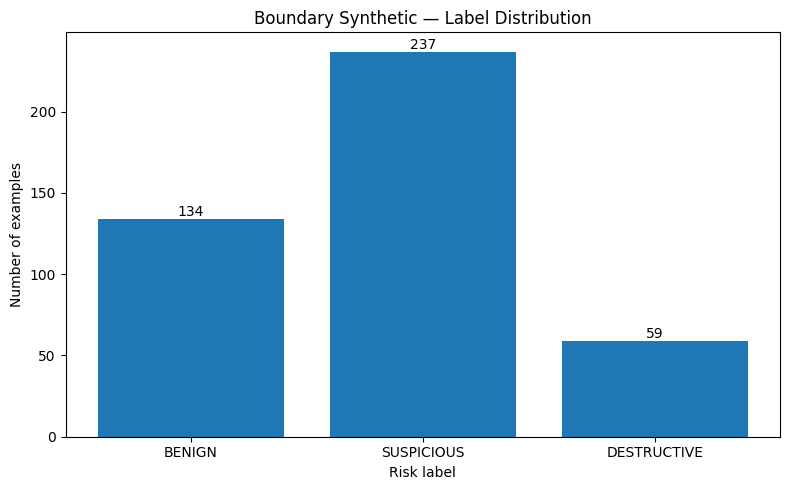

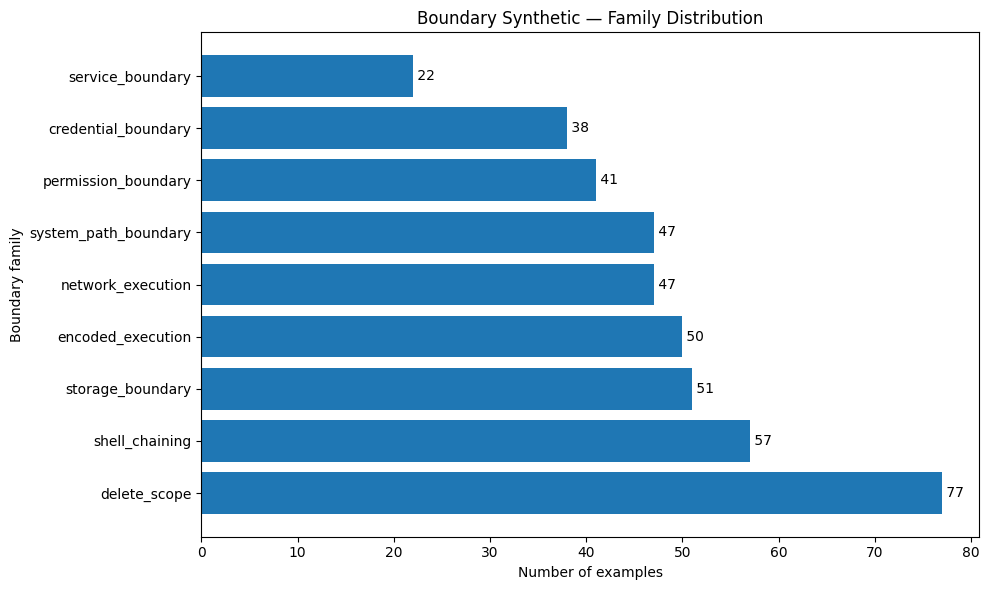

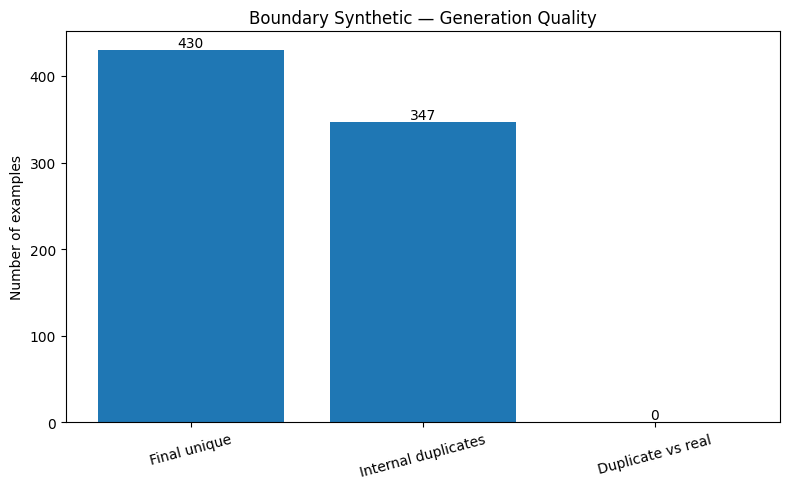

In [35]:
# =========================================================
# CELL 33 — BOUNDARY SYNTHETIC GENERATION
# CHECKPOINT + RESUME
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. PATHS
# =========================================================

BOUNDARY_CHECKPOINT_PATH = (
    f"{SYNTHETIC_DIR}/"
    "boundary_checkpoint_v1.jsonl"
)

BOUNDARY_RAW_PATH = (
    f"{SYNTHETIC_DIR}/"
    "boundary_raw_v1.jsonl"
)

BOUNDARY_ERROR_PATH = (
    f"{SYNTHETIC_DIR}/"
    "boundary_errors_v1.jsonl"
)

BOUNDARY_PROGRESS_PATH = (
    f"{SYNTHETIC_DIR}/"
    "boundary_progress_v1.json"
)


# =========================================================
# 2. LOAD JOBS
# =========================================================

boundary_jobs = load_jsonl(
    BOUNDARY_JOB_PATH
)


# =========================================================
# 3. CHECKPOINT
# =========================================================

if os.path.exists(
    BOUNDARY_CHECKPOINT_PATH
):

    checkpoint_rows = load_jsonl(
        BOUNDARY_CHECKPOINT_PATH
    )

else:

    checkpoint_rows = []


processed_jobs = {
    row["job_id"]
    for row in checkpoint_rows
    if row.get(
        "status"
    ) in [
        "accepted",
        "rejected",
    ]
}


accepted_jobs = sum(
    row.get("status")
    == "accepted"
    for row in checkpoint_rows
)


rejected_jobs = sum(
    row.get("status")
    == "rejected"
    for row in checkpoint_rows
)


# =========================================================
# 4. PROGRESS
# =========================================================

def save_boundary_progress():

    completed = (
        accepted_jobs
        + rejected_jobs
    )


    progress = {

        "total_jobs":
            len(
                boundary_jobs
            ),

        "completed_jobs":
            completed,

        "remaining_jobs":
            max(
                len(boundary_jobs)
                - completed,
                0
            ),

        "accepted_jobs":
            accepted_jobs,

        "rejected_jobs":
            rejected_jobs,

        "teacher_model":
            TEACHER_MODEL,

        "updated_at":
            time.strftime(
                "%Y-%m-%d %H:%M:%S"
            ),
    }


    tmp_path = (
        BOUNDARY_PROGRESS_PATH
        + ".tmp"
    )


    with open(
        tmp_path,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            progress,
            f,
            indent=2,
            ensure_ascii=False,
        )


    os.replace(
        tmp_path,
        BOUNDARY_PROGRESS_PATH
    )


# =========================================================
# 5. STATUS
# =========================================================

print()
print("=" * 70)
print("BOUNDARY GENERATION")
print("=" * 70)

print(
    "Jobs total:",
    len(boundary_jobs)
)

print(
    "Processed:",
    len(processed_jobs)
)

print(
    "Remaining:",
    sum(
        job["job_id"]
        not in processed_jobs
        for job in boundary_jobs
    )
)

print("=" * 70)


# =========================================================
# 6. RUN
# =========================================================

try:

    for job in tqdm(
        boundary_jobs,
        desc="Boundary generation",
    ):


        job_id = (
            job["job_id"]
        )


        if job_id in processed_jobs:

            continue


        result = (
            call_boundary_with_retry(

                job["family"],

                job["description"],

                job["allowed_labels"],

                job["count"],
            )
        )


        timestamp = time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )


        # -------------------------------------------------
        # SUCCESS
        # -------------------------------------------------

        if result["success"]:

            examples = []


            for i, example in enumerate(
                result["examples"],
                start=1,
            ):

                command = (
                    example["command"]
                )


                examples.append({

                    "synthetic_id":
                        f"{job_id}_{i:02d}",

                    "job_id":
                        job_id,

                    "command":
                        command,

                    "command_hash":
                        command_hash(
                            command
                        ),

                    "risk":
                        example[
                            "risk"
                        ],

                    "family":
                        example[
                            "family"
                        ],

                    "boundary_group":
                        example[
                            "boundary_group"
                        ],

                    "label_source":
                        "synthetic_boundary",
                })


            checkpoint_item = {

                "job_id":
                    job_id,

                "family":
                    job[
                        "family"
                    ],

                "requested_count":
                    job[
                        "count"
                    ],

                "generated_count":
                    len(
                        examples
                    ),

                "examples":
                    examples,

                "latency":
                    result[
                        "latency"
                    ],

                "attempt":
                    result[
                        "attempt"
                    ],

                "status":
                    "accepted",

                "error":
                    None,

                "timestamp":
                    timestamp,
            }


            accepted_jobs += 1


        # -------------------------------------------------
        # FAILURE
        # -------------------------------------------------

        else:

            checkpoint_item = {

                "job_id":
                    job_id,

                "family":
                    job[
                        "family"
                    ],

                "requested_count":
                    job[
                        "count"
                    ],

                "generated_count":
                    0,

                "examples":
                    [],

                "status":
                    "rejected",

                "error":
                    result[
                        "error"
                    ],

                "timestamp":
                    timestamp,
            }


            rejected_jobs += 1


        # -------------------------------------------------
        # SAVE IMMEDIATELY
        # -------------------------------------------------

        append_jsonl(
            BOUNDARY_CHECKPOINT_PATH,
            checkpoint_item
        )


        processed_jobs.add(
            job_id
        )


        save_boundary_progress()


except KeyboardInterrupt:

    print()
    print("Interrupted.")
    print(
        "Checkpoint aman, "
        "jalankan CELL 33 lagi."
    )


# =========================================================
# 7. RELOAD
# =========================================================

checkpoint_rows = load_jsonl(
    BOUNDARY_CHECKPOINT_PATH
)


valid_jobs = {
    job["job_id"]
    for job in boundary_jobs
}


checkpoint_rows = [
    row
    for row in checkpoint_rows
    if row.get(
        "job_id"
    ) in valid_jobs
]


# =========================================================
# 8. FLATTEN
# =========================================================

boundary_rows = []


for row in checkpoint_rows:

    if row.get(
        "status"
    ) != "accepted":

        continue


    boundary_rows.extend(
        row.get(
            "examples",
            []
        )
    )


# =========================================================
# 9. DEDUP AGAINST ITSELF
# =========================================================

seen_hashes = set()

boundary_unique = []

internal_duplicates = 0


for row in boundary_rows:

    key = row[
        "command_hash"
    ]


    if key in seen_hashes:

        internal_duplicates += 1

        continue


    seen_hashes.add(
        key
    )

    boundary_unique.append(
        row
    )


# =========================================================
# 10. REMOVE DUPLICATES AGAINST REAL DATA
# =========================================================

trusted_v2_rows = load_jsonl(
    TRUSTED_V2_PATH
)


real_hashes = {
    row["command_hash"]
    for row in trusted_v2_rows
}


boundary_final = []

real_duplicates = 0


for row in boundary_unique:

    if (
        row["command_hash"]
        in real_hashes
    ):

        real_duplicates += 1

        continue


    boundary_final.append(
        row
    )


# =========================================================
# 11. SAVE
# =========================================================

with open(
    BOUNDARY_RAW_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in boundary_final:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


error_rows = [
    row
    for row in checkpoint_rows
    if row.get(
        "status"
    ) == "rejected"
]


with open(
    BOUNDARY_ERROR_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in error_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 12. DISTRIBUTION
# =========================================================

label_distribution = Counter(
    row["risk"]
    for row in boundary_final
)


family_distribution = Counter(
    row["family"]
    for row in boundary_final
)


group_count = len(
    {
        row["boundary_group"]
        for row in boundary_final
    }
)

# =========================================================
# 13. SUMMARY + VISUALIZATION
# =========================================================

import matplotlib.pyplot as plt


# =========================================================
# TEXT SUMMARY
# =========================================================

print()
print("=" * 80)
print("BOUNDARY GENERATION COMPLETE")
print("=" * 80)

print(
    "Jobs:",
    len(boundary_jobs)
)

print(
    "Accepted jobs:",
    sum(
        row.get("status") == "accepted"
        for row in checkpoint_rows
    )
)

print(
    "Rejected jobs:",
    len(error_rows)
)

print(
    "Raw generated:",
    len(boundary_rows)
)

print(
    "Internal duplicates:",
    internal_duplicates
)

print(
    "Duplicates vs real:",
    real_duplicates
)

print(
    "Final unique:",
    len(boundary_final)
)

print()

print(
    "Label distribution:",
    dict(label_distribution)
)

print(
    "Boundary groups:",
    group_count
)

print()

print("Family distribution:")

for family, count in sorted(
    family_distribution.items()
):

    print(
        f"{family:<28}",
        count
    )

print()
print(
    "Saved:",
    BOUNDARY_RAW_PATH
)

print("=" * 80)


# =========================================================
# GRAPH 1 — LABEL DISTRIBUTION
# =========================================================

labels = [
    "BENIGN",
    "SUSPICIOUS",
    "DESTRUCTIVE",
]

label_counts = [
    label_distribution.get(
        label,
        0
    )
    for label in labels
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    labels,
    label_counts,
)

plt.title(
    "Boundary Synthetic — Label Distribution"
)

plt.xlabel(
    "Risk label"
)

plt.ylabel(
    "Number of examples"
)


for bar, value in zip(
    bars,
    label_counts
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 2 — FAMILY DISTRIBUTION
# =========================================================

families = [
    family
    for family, count
    in sorted(
        family_distribution.items(),
        key=lambda x: x[1],
        reverse=True,
    )
]

family_counts = [
    family_distribution[
        family
    ]
    for family in families
]


plt.figure(
    figsize=(10, 6)
)

bars = plt.barh(
    families,
    family_counts,
)

plt.title(
    "Boundary Synthetic — Family Distribution"
)

plt.xlabel(
    "Number of examples"
)

plt.ylabel(
    "Boundary family"
)


for bar, value in zip(
    bars,
    family_counts
):

    plt.text(
        bar.get_width(),

        bar.get_y()
        + bar.get_height() / 2,

        f" {value}",

        va="center",
    )


plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 3 — GENERATION QUALITY
# =========================================================

quality_names = [
    "Final unique",
    "Internal duplicates",
    "Duplicate vs real",
]

quality_values = [
    len(boundary_final),
    internal_duplicates,
    real_duplicates,
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    quality_names,
    quality_values,
)

plt.title(
    "Boundary Synthetic — Generation Quality"
)

plt.ylabel(
    "Number of examples"
)


for bar, value in zip(
    bars,
    quality_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()


BOUNDARY DATASET AUDIT
Rows: 430

Label distribution:
BENIGN      : 134
SUSPICIOUS  : 237
DESTRUCTIVE : 59

Global boundary groups: 260
Multi-label groups: 135
Single-label groups: 125

Group size distribution: {1: 104, 2: 145, 3: 8, 4: 3}

Saved: /content/drive/MyDrive/command_risk/synthetic/boundary_repaired_v1.jsonl


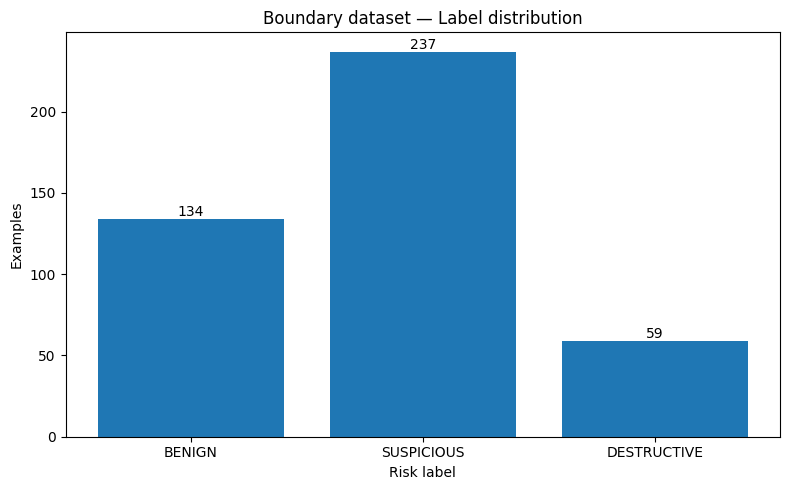

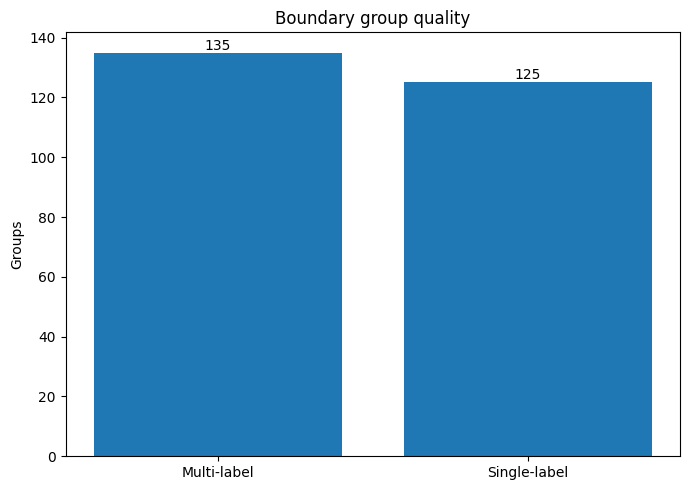

In [36]:
# =========================================================
# CELL 34 — REPAIR BOUNDARY GROUP IDS + DATASET AUDIT
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import matplotlib.pyplot as plt


# =========================================================
# 1. LOAD DATA
# =========================================================

boundary_rows = load_jsonl(
    BOUNDARY_RAW_PATH
)


print()
print("=" * 80)
print("BOUNDARY DATASET AUDIT")
print("=" * 80)

print(
    "Rows:",
    len(boundary_rows)
)


# =========================================================
# 2. FIX BOUNDARY GROUP COLLISIONS
# =========================================================
#
# Teacher may reuse:
#
# group_001
# group_002
#
# across multiple API jobs.
#
# Prefix with job_id so groups become globally unique:
#
# boundary_0001::group_001
# boundary_0002::group_001
#
# =========================================================

repaired_rows = []


for row in boundary_rows:

    item = dict(row)

    job_id = str(
        row.get(
            "job_id",
            "unknown_job"
        )
    )

    local_group = str(
        row.get(
            "boundary_group",
            "unknown_group"
        )
    )


    item[
        "boundary_group_local"
    ] = local_group


    item[
        "boundary_group"
    ] = (
        f"{job_id}::{local_group}"
    )


    repaired_rows.append(
        item
    )


# =========================================================
# 3. SAVE REPAIRED DATASET
# =========================================================

BOUNDARY_REPAIRED_PATH = (
    f"{SYNTHETIC_DIR}/"
    "boundary_repaired_v1.jsonl"
)


with open(
    BOUNDARY_REPAIRED_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in repaired_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 4. DISTRIBUTIONS
# =========================================================

label_distribution = Counter(
    row["risk"]
    for row in repaired_rows
)


family_distribution = Counter(
    row["family"]
    for row in repaired_rows
)


group_distribution = Counter(
    row["boundary_group"]
    for row in repaired_rows
)


group_sizes = Counter(
    group_distribution.values()
)


# =========================================================
# 5. VALID CONTRASTIVE GROUPS
# =========================================================
#
# A useful group should contain >= 2 labels.
# =========================================================

group_labels = defaultdict(
    set
)


for row in repaired_rows:

    group_labels[
        row["boundary_group"]
    ].add(
        row["risk"]
    )


multi_label_groups = {
    group: labels
    for group, labels
    in group_labels.items()
    if len(labels) >= 2
}


single_label_groups = {
    group: labels
    for group, labels
    in group_labels.items()
    if len(labels) == 1
}


# =========================================================
# 6. REPORT
# =========================================================

print()
print("Label distribution:")

for label in RISK_LABELS:

    print(
        f"{label:<12}:",
        label_distribution.get(
            label,
            0
        )
    )


print()

print(
    "Global boundary groups:",
    len(group_distribution)
)

print(
    "Multi-label groups:",
    len(multi_label_groups)
)

print(
    "Single-label groups:",
    len(single_label_groups)
)

print()

print(
    "Group size distribution:",
    dict(
        sorted(
            group_sizes.items()
        )
    )
)

print()

print(
    "Saved:",
    BOUNDARY_REPAIRED_PATH
)

print("=" * 80)


# =========================================================
# GRAPH 1 — LABEL DISTRIBUTION
# =========================================================

labels = RISK_LABELS

values = [
    label_distribution.get(
        label,
        0
    )
    for label in labels
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    labels,
    values
)

plt.title(
    "Boundary dataset — Label distribution"
)

plt.xlabel(
    "Risk label"
)

plt.ylabel(
    "Examples"
)


for bar, value in zip(
    bars,
    values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 2 — CONTRASTIVE GROUP QUALITY
# =========================================================

group_quality_names = [
    "Multi-label",
    "Single-label",
]

group_quality_values = [
    len(multi_label_groups),
    len(single_label_groups),
]


plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    group_quality_names,
    group_quality_values,
)

plt.title(
    "Boundary group quality"
)

plt.ylabel(
    "Groups"
)


for bar, value in zip(
    bars,
    group_quality_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()

In [37]:
# =========================================================
# CELL 35 — INDEPENDENT SYNTHETIC VALIDATOR SETUP
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


VALIDATOR_SYSTEM_PROMPT = """
You are an independent shell-command risk classifier.

You are validating synthetic training examples created by
another model.

You are NOT told the expected label.

Evaluate each command independently.

DO NOT execute commands.

This is SINGLE-LABEL classification.

Allowed labels:

BENIGN
SUSPICIOUS
DESTRUCTIVE


=========================================================
BENIGN
=========================================================

Low operational risk.

Examples:

ls -la
cat /etc/os-release
rm <TEST_FILE>
curl <TEST_URL>
systemctl status <TEST_SERVICE>


=========================================================
SUSPICIOUS
=========================================================

Not clearly catastrophic, but crosses a meaningful
security, privilege, sensitive-data, execution, or
system-safety boundary.

Examples:

sudo systemctl restart <TEST_SERVICE>
curl <TEST_URL> | bash
cat ~/.ssh/id_ed25519
rm -rf <TEMP_DIR>


=========================================================
DESTRUCTIVE
=========================================================

Clearly implies major, widespread, or irreversible damage.

Examples:

rm -rf /
rm -rf /*
mkfs.ext4 <TEST_DEVICE>
dd if=/dev/zero of=<TEST_DEVICE>


=========================================================
BOUNDARY RULES
=========================================================

Scope matters.

rm <TEST_FILE>
-> BENIGN

rm -rf <TEMP_DIR>
-> SUSPICIOUS

rm -rf /
-> DESTRUCTIVE


Pipes alone are not suspicious.

sudo alone is not destructive.

Network access alone is not suspicious.

Direct network-to-shell execution is suspicious.

Use DESTRUCTIVE only for clearly major destructive impact.


=========================================================
OUTPUT
=========================================================

Return ONLY valid JSON.

{
  "risk": "SUSPICIOUS",
  "confidence": 0.95,
  "ambiguous": false
}

Do not explain.
Do not include markdown.
"""


# =========================================================
# API CALL
# =========================================================

def call_synthetic_validator(
    command
):

    headers = {

        "Authorization":
            f"Bearer {API_KEY}",

        "Content-Type":
            "application/json",
    }


    payload = {

        "model":
            TEACHER_MODEL,

        "temperature":
            0,

        "thinking": {
            "type":
                "disabled"
        },

        "response_format": {
            "type":
                "json_object"
        },

        "messages": [

            {
                "role":
                    "system",

                "content":
                    VALIDATOR_SYSTEM_PROMPT,
            },

            {
                "role":
                    "user",

                "content":
                    command,
            },
        ],
    }


    start = time.time()


    response = requests.post(

        BASE_URL,

        headers=headers,

        json=payload,

        timeout=(
            TIMEOUT_CONNECT,
            45,
        ),
    )


    latency = (
        time.time()
        - start
    )


    response.raise_for_status()


    content = (
        response.json()
        ["choices"][0]
        ["message"]
        ["content"]
    )


    return (
        content,
        latency
    )


# =========================================================
# PARSER
# =========================================================

def parse_synthetic_validator(
    text
):

    data = json.loads(
        text.strip()
    )


    risk = str(
        data.get(
            "risk",
            ""
        )
    ).strip().upper()


    if risk not in RISK_LABELS:

        raise ValueError(
            f"Invalid risk: {risk}"
        )


    confidence = float(
        data.get(
            "confidence"
        )
    )


    if not (
        0 <= confidence <= 1
    ):

        raise ValueError(
            "Invalid confidence"
        )


    ambiguous = data.get(
        "ambiguous"
    )


    if not isinstance(
        ambiguous,
        bool
    ):

        raise ValueError(
            "ambiguous harus bool"
        )


    return {

        "risk":
            risk,

        "confidence":
            confidence,

        "ambiguous":
            ambiguous,
    }


# =========================================================
# RETRY
# =========================================================

def validate_synthetic_with_retry(
    command,
    max_retries=4,
):

    last_error = None


    for attempt in range(
        1,
        max_retries + 1,
    ):

        try:

            content, latency = (
                call_synthetic_validator(
                    command
                )
            )


            parsed = (
                parse_synthetic_validator(
                    content
                )
            )


            return {

                "success":
                    True,

                "parsed":
                    parsed,

                "latency":
                    latency,

                "attempt":
                    attempt,

                "error":
                    None,
            }


        except Exception as exc:

            last_error = str(
                exc
            )


            if attempt < max_retries:

                delay = (
                    2 ** attempt
                )

                time.sleep(
                    delay
                )


    return {

        "success":
            False,

        "parsed":
            None,

        "latency":
            None,

        "attempt":
            max_retries,

        "error":
            last_error,
    }


print()
print("=" * 70)
print("INDEPENDENT SYNTHETIC VALIDATOR")
print("=" * 70)

print(
    "Model:",
    TEACHER_MODEL
)

print(
    "Expected label hidden:",
    "YES"
)

print(
    "Parser:",
    "OK"
)

print(
    "Retry:",
    "OK"
)

print("=" * 70)


INDEPENDENT SYNTHETIC VALIDATOR
Model: deepseek-v4-flash
Expected label hidden: YES
Parser: OK
Retry: OK


In [38]:
# =========================================================
# CELL 36 — VALIDATE SYNTHETIC DATASET
# CHECKPOINT + RESUME
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


# =========================================================
# 1. PATHS
# =========================================================

SYNTHETIC_VALIDATION_CHECKPOINT = (
    f"{SYNTHETIC_DIR}/"
    "boundary_validation_checkpoint_v1.jsonl"
)

SYNTHETIC_VALIDATED_PATH = (
    f"{SYNTHETIC_DIR}/"
    "boundary_validated_v1.jsonl"
)

SYNTHETIC_VALIDATION_REJECTED_PATH = (
    f"{SYNTHETIC_DIR}/"
    "boundary_validation_rejected_v1.jsonl"
)

SYNTHETIC_VALIDATION_PROGRESS = (
    f"{SYNTHETIC_DIR}/"
    "boundary_validation_progress_v1.json"
)


# =========================================================
# 2. LOAD
# =========================================================

boundary_rows = load_jsonl(
    BOUNDARY_REPAIRED_PATH
)


if os.path.exists(
    SYNTHETIC_VALIDATION_CHECKPOINT
):

    checkpoint_rows = load_jsonl(
        SYNTHETIC_VALIDATION_CHECKPOINT
    )

else:

    checkpoint_rows = []


processed_hashes = {
    row["command_hash"]
    for row in checkpoint_rows
}


# =========================================================
# 3. STATUS
# =========================================================

print()
print("=" * 70)
print("SYNTHETIC INDEPENDENT VALIDATION")
print("=" * 70)

print(
    "Total:",
    len(boundary_rows)
)

print(
    "Processed:",
    len(processed_hashes)
)

print(
    "Remaining:",
    sum(
        row["command_hash"]
        not in processed_hashes
        for row in boundary_rows
    )
)

print("=" * 70)


# =========================================================
# 4. LOOP
# =========================================================

try:

    for row in tqdm(
        boundary_rows,
        desc="Synthetic validation",
    ):


        command_hash_value = (
            row["command_hash"]
        )


        if (
            command_hash_value
            in processed_hashes
        ):

            continue


        result = (
            validate_synthetic_with_retry(
                row["command"]
            )
        )


        timestamp = time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )


        if result["success"]:

            parsed = result[
                "parsed"
            ]


            label_match = (
                parsed["risk"]
                == row["risk"]
            )


            checkpoint_item = {

                **row,

                "generator_risk":
                    row["risk"],

                "validator_risk":
                    parsed["risk"],

                "validator_confidence":
                    parsed[
                        "confidence"
                    ],

                "validator_ambiguous":
                    parsed[
                        "ambiguous"
                    ],

                "label_match":
                    label_match,

                "validation_status":
                    "accepted",

                "latency":
                    result[
                        "latency"
                    ],

                "attempt":
                    result[
                        "attempt"
                    ],

                "timestamp":
                    timestamp,
            }


        else:

            checkpoint_item = {

                **row,

                "generator_risk":
                    row["risk"],

                "validator_risk":
                    None,

                "validator_confidence":
                    None,

                "validator_ambiguous":
                    True,

                "label_match":
                    False,

                "validation_status":
                    "api_error",

                "error":
                    result[
                        "error"
                    ],

                "timestamp":
                    timestamp,
            }


        append_jsonl(
            SYNTHETIC_VALIDATION_CHECKPOINT,
            checkpoint_item
        )


        processed_hashes.add(
            command_hash_value
        )


        progress = {

            "total":
                len(
                    boundary_rows
                ),

            "completed":
                len(
                    processed_hashes
                ),

            "remaining":
                max(
                    len(boundary_rows)
                    - len(processed_hashes),
                    0
                ),

            "updated_at":
                timestamp,
        }


        temp_path = (
            SYNTHETIC_VALIDATION_PROGRESS
            + ".tmp"
        )


        with open(
            temp_path,
            "w",
            encoding="utf-8",
        ) as f:

            json.dump(
                progress,
                f,
                indent=2,
            )


        os.replace(
            temp_path,
            SYNTHETIC_VALIDATION_PROGRESS
        )


except KeyboardInterrupt:

    print()
    print(
        "Interrupted — checkpoint aman."
    )


# =========================================================
# 5. RELOAD
# =========================================================

validation_rows = load_jsonl(
    SYNTHETIC_VALIDATION_CHECKPOINT
)


valid_hashes = {
    row["command_hash"]
    for row in boundary_rows
}


validation_rows = [
    row
    for row in validation_rows
    if row["command_hash"]
    in valid_hashes
]


# =========================================================
# 6. BASIC TRUST FILTER
# =========================================================

VALIDATOR_MIN_CONFIDENCE = 0.80


validated_rows = [
    row
    for row in validation_rows
    if (
        row.get(
            "validation_status"
        )
        == "accepted"

        and
        row.get(
            "label_match"
        ) is True

        and
        row.get(
            "validator_ambiguous"
        ) is False

        and
        row.get(
            "validator_confidence",
            0
        )
        >= VALIDATOR_MIN_CONFIDENCE
    )
]


rejected_rows = [
    row
    for row in validation_rows
    if row not in validated_rows
]


# =========================================================
# 7. SAVE
# =========================================================

with open(
    SYNTHETIC_VALIDATED_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in validated_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


with open(
    SYNTHETIC_VALIDATION_REJECTED_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in rejected_rows:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


print()
print("=" * 70)
print("SYNTHETIC VALIDATION COMPLETE")
print("=" * 70)

print(
    "Total:",
    len(validation_rows)
)

print(
    "Trusted:",
    len(validated_rows)
)

print(
    "Rejected:",
    len(rejected_rows)
)

print(
    "Acceptance rate:",
    round(
        len(validated_rows)
        / len(validation_rows),
        4
    )
)

print("=" * 70)


SYNTHETIC INDEPENDENT VALIDATION
Total: 430
Processed: 430
Remaining: 0


Synthetic validation:   0%|          | 0/430 [00:00<?, ?it/s]


SYNTHETIC VALIDATION COMPLETE
Total: 430
Trusted: 327
Rejected: 103
Acceptance rate: 0.7605



SYNTHETIC VALIDATION ANALYSIS
Generator-validator agreement: 329
Disagreement: 101
Agreement rate: 0.7651

Validated synthetic: 327

Validated distribution:
BENIGN      : 107
SUSPICIOUS  : 166
DESTRUCTIVE : 54

Disagreement pairs:
SUSPICIOUS   -> BENIGN      : 53
BENIGN       -> SUSPICIOUS  : 27
SUSPICIOUS   -> DESTRUCTIVE : 16
DESTRUCTIVE  -> SUSPICIOUS  : 5

DATASET V3 PREVIEW
BENIGN      :  2073 ( 59.98%)
SUSPICIOUS  :  1067 ( 30.87%)
DESTRUCTIVE :   316 (  9.14%)

Total: 3456


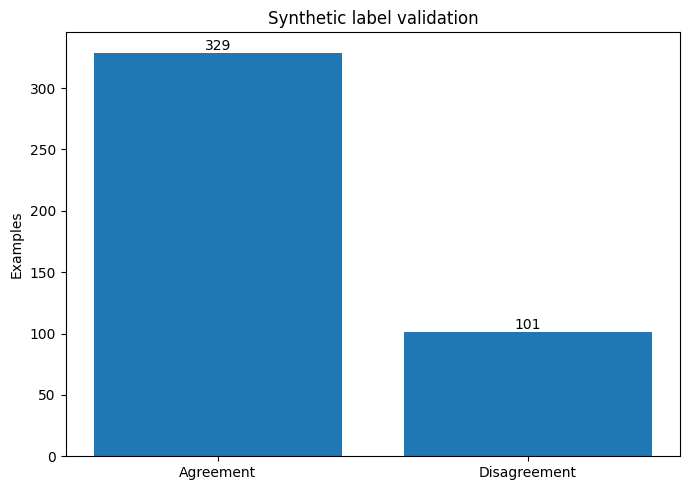

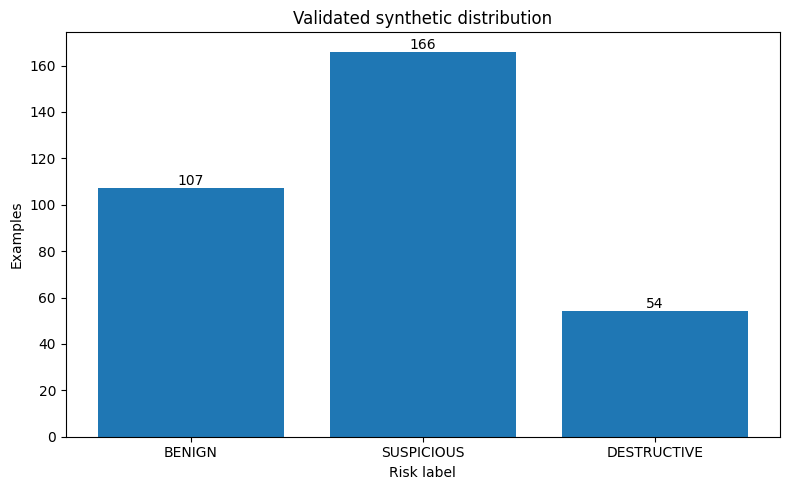

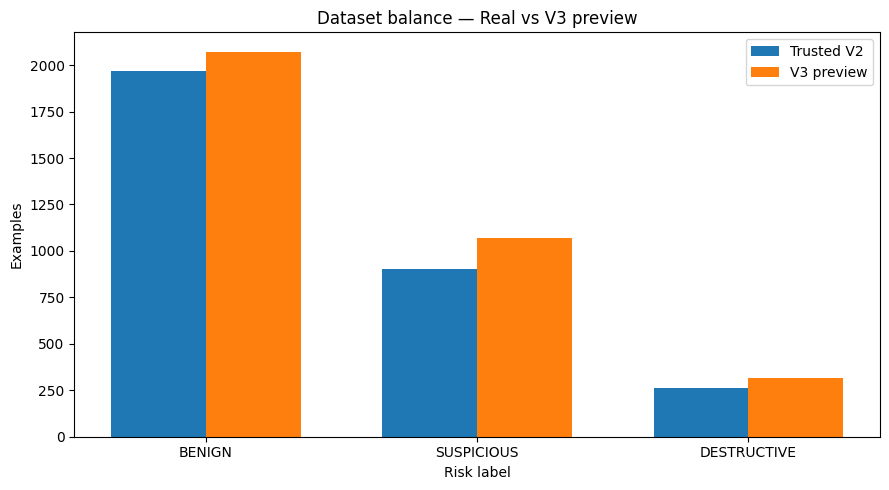

In [39]:
# =========================================================
# CELL 37 — SYNTHETIC VALIDATION ANALYSIS
# DATASET V3 PREVIEW
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import matplotlib.pyplot as plt


# =========================================================
# 1. LOAD
# =========================================================

validation_rows = load_jsonl(
    SYNTHETIC_VALIDATION_CHECKPOINT
)


validated_rows = load_jsonl(
    SYNTHETIC_VALIDATED_PATH
)


trusted_v2_rows = load_jsonl(
    TRUSTED_V2_PATH
)


# =========================================================
# 2. AGREEMENT
# =========================================================

agreement = sum(
    row.get(
        "label_match"
    ) is True
    for row in validation_rows
)


disagreement = sum(
    row.get(
        "label_match"
    ) is False
    for row in validation_rows
)


confusion = Counter(

    (
        row.get(
            "generator_risk"
        ),

        row.get(
            "validator_risk"
        ),
    )

    for row in validation_rows

    if row.get(
        "validator_risk"
    ) is not None

    and

    row.get(
        "generator_risk"
    )
    != row.get(
        "validator_risk"
    )
)


# =========================================================
# 3. VALIDATED DISTRIBUTION
# =========================================================

validated_distribution = Counter(
    row["generator_risk"]
    for row in validated_rows
)


# =========================================================
# 4. DATASET V3 PREVIEW
# =========================================================

combined_distribution = Counter(
    row["risk"]
    for row in trusted_v2_rows
)


for row in validated_rows:

    combined_distribution[
        row["generator_risk"]
    ] += 1


combined_size = (
    len(trusted_v2_rows)
    + len(validated_rows)
)


# =========================================================
# 5. TEXT SUMMARY
# =========================================================

print()
print("=" * 80)
print("SYNTHETIC VALIDATION ANALYSIS")
print("=" * 80)

print(
    "Generator-validator agreement:",
    agreement
)

print(
    "Disagreement:",
    disagreement
)

print(
    "Agreement rate:",
    round(
        agreement
        / len(validation_rows),
        4
    )
)

print()

print(
    "Validated synthetic:",
    len(validated_rows)
)

print()

print(
    "Validated distribution:"
)


for label in RISK_LABELS:

    print(
        f"{label:<12}:",
        validated_distribution.get(
            label,
            0
        )
    )


print()
print("Disagreement pairs:")


for pair, count in (
    confusion.most_common()
):

    print(
        f"{str(pair[0]):<12}"
        f" -> "
        f"{str(pair[1]):<12}"
        f": {count}"
    )


print()
print("=" * 80)
print("DATASET V3 PREVIEW")
print("=" * 80)


for label in RISK_LABELS:

    count = (
        combined_distribution[
            label
        ]
    )

    pct = (
        count
        / combined_size
        * 100
    )

    print(
        f"{label:<12}: "
        f"{count:>5} "
        f"({pct:6.2f}%)"
    )


print()

print(
    "Total:",
    combined_size
)

print("=" * 80)


# =========================================================
# GRAPH 1 — GENERATOR vs VALIDATOR
# =========================================================

quality_names = [
    "Agreement",
    "Disagreement",
]

quality_values = [
    agreement,
    disagreement,
]


plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    quality_names,
    quality_values
)

plt.title(
    "Synthetic label validation"
)

plt.ylabel(
    "Examples"
)


for bar, value in zip(
    bars,
    quality_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 2 — VALIDATED SYNTHETIC LABELS
# =========================================================

labels = RISK_LABELS

values = [
    validated_distribution.get(
        label,
        0
    )
    for label in labels
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    labels,
    values
)

plt.title(
    "Validated synthetic distribution"
)

plt.xlabel(
    "Risk label"
)

plt.ylabel(
    "Examples"
)


for bar, value in zip(
    bars,
    values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 3 — REAL V2 vs V3 PREVIEW
# =========================================================

real_counts = [
    sum(
        row["risk"] == label
        for row in trusted_v2_rows
    )
    for label in RISK_LABELS
]


v3_counts = [
    combined_distribution[
        label
    ]
    for label in RISK_LABELS
]


x = np.arange(
    len(RISK_LABELS)
)

width = 0.35


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    x - width / 2,
    real_counts,
    width,
    label="Trusted V2",
)

plt.bar(
    x + width / 2,
    v3_counts,
    width,
    label="V3 preview",
)


plt.xticks(
    x,
    RISK_LABELS
)

plt.title(
    "Dataset balance — Real vs V3 preview"
)

plt.xlabel(
    "Risk label"
)

plt.ylabel(
    "Examples"
)

plt.legend()

plt.tight_layout()

plt.show()


BOUNDARY FAMILY QUALITY
storage_boundary             n= 51  agree=0.588  trusted=0.588  conf=0.968
system_path_boundary         n= 47  agree=0.638  trusted=0.638  conf=0.953
encoded_execution            n= 50  agree=0.700  trusted=0.680  conf=0.914
delete_scope                 n= 77  agree=0.727  trusted=0.727  conf=0.937
service_boundary             n= 22  agree=0.773  trusted=0.773  conf=0.937
credential_boundary          n= 38  agree=0.842  trusted=0.842  conf=0.944
shell_chaining               n= 57  agree=0.842  trusted=0.825  conf=0.950
permission_boundary          n= 41  agree=0.878  trusted=0.878  conf=0.931
network_execution            n= 47  agree=0.957  trusted=0.957  conf=0.941

DISAGREEMENTS BY FAMILY
delete_scope               BENIGN       -> SUSPICIOUS   : 18
storage_boundary           SUSPICIOUS   -> BENIGN       : 17
encoded_execution          SUSPICIOUS   -> BENIGN       : 13
shell_chaining             SUSPICIOUS   -> BENIGN       : 9
system_path_boundary       SUSPI

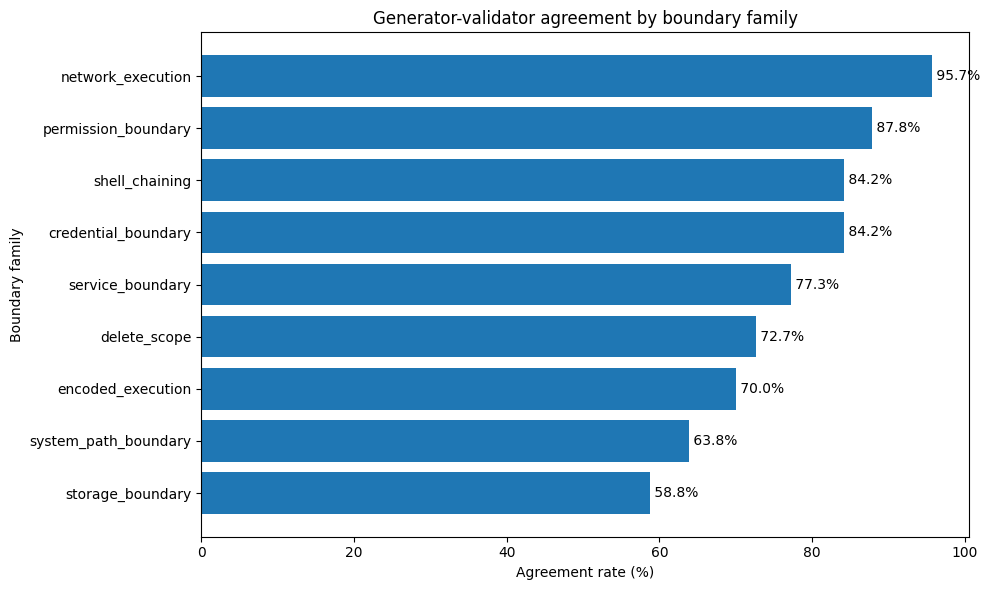

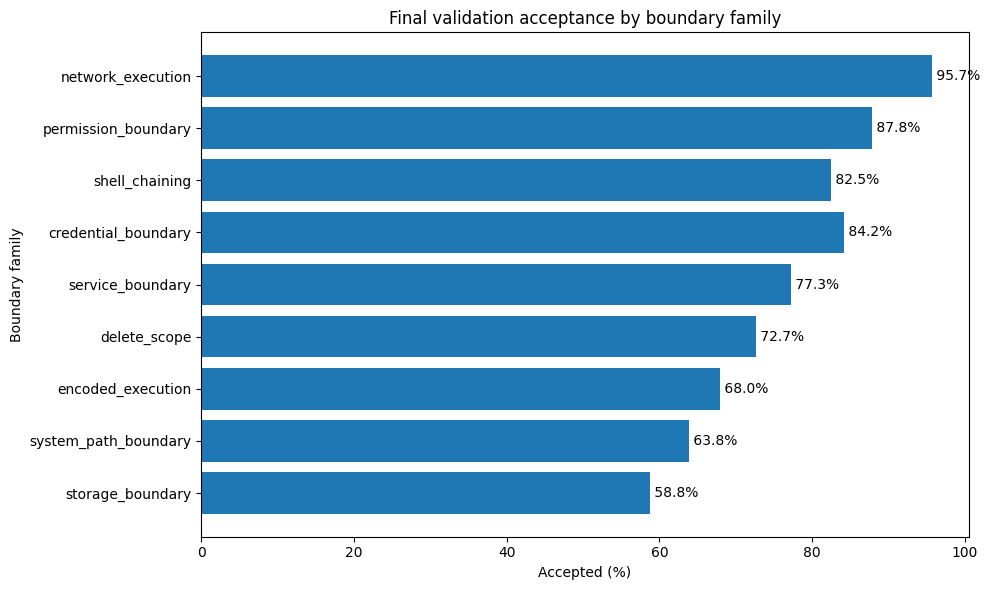

In [40]:
# =========================================================
# CELL 38 — BOUNDARY QUALITY & DISAGREEMENT AUDIT
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import matplotlib.pyplot as plt


# =========================================================
# 1. LOAD VALIDATION DATA
# =========================================================

validation_rows = load_jsonl(
    SYNTHETIC_VALIDATION_CHECKPOINT
)


# =========================================================
# 2. FAMILY STATS
# =========================================================

family_stats = {}


for row in validation_rows:

    family = row.get(
        "family",
        "unknown"
    )


    if family not in family_stats:

        family_stats[family] = {

            "total": 0,
            "agreement": 0,
            "trusted": 0,
            "confidence": [],
        }


    family_stats[
        family
    ]["total"] += 1


    if row.get(
        "label_match"
    ) is True:

        family_stats[
            family
        ]["agreement"] += 1


    if (
        row.get(
            "label_match"
        ) is True
        and
        row.get(
            "validator_ambiguous"
        ) is False
        and
        row.get(
            "validator_confidence",
            0
        ) >= 0.80
    ):

        family_stats[
            family
        ]["trusted"] += 1


    confidence = row.get(
        "validator_confidence"
    )


    if confidence is not None:

        family_stats[
            family
        ][
            "confidence"
        ].append(
            confidence
        )


# =========================================================
# 3. REPORT
# =========================================================

print()
print("=" * 90)
print("BOUNDARY FAMILY QUALITY")
print("=" * 90)


family_report = []


for family, stats in (
    family_stats.items()
):

    total = stats[
        "total"
    ]


    agreement_rate = (
        stats["agreement"]
        / total
    )


    trusted_rate = (
        stats["trusted"]
        / total
    )


    mean_conf = (
        float(
            np.mean(
                stats[
                    "confidence"
                ]
            )
        )
        if stats[
            "confidence"
        ]
        else 0
    )


    family_report.append({

        "family":
            family,

        "total":
            total,

        "agreement_rate":
            agreement_rate,

        "trusted_rate":
            trusted_rate,

        "mean_confidence":
            mean_conf,
    })


family_report = sorted(
    family_report,
    key=lambda x:
        x[
            "agreement_rate"
        ]
)


for row in family_report:

    print(
        f"{row['family']:<28} "
        f"n={row['total']:>3}  "
        f"agree={row['agreement_rate']:.3f}  "
        f"trusted={row['trusted_rate']:.3f}  "
        f"conf={row['mean_confidence']:.3f}"
    )


# =========================================================
# 4. DISAGREEMENT PAIRS BY FAMILY
# =========================================================

print()
print("=" * 90)
print("DISAGREEMENTS BY FAMILY")
print("=" * 90)


family_disagreements = Counter()


for row in validation_rows:

    if (
        row.get(
            "label_match"
        ) is False
        and
        row.get(
            "validator_risk"
        ) is not None
    ):

        key = (

            row.get(
                "family",
                "unknown"
            ),

            row.get(
                "generator_risk"
            ),

            row.get(
                "validator_risk"
            ),
        )


        family_disagreements[
            key
        ] += 1


for (
    family,
    source,
    target
), count in (
    family_disagreements
    .most_common()
):

    print(
        f"{family:<26} "
        f"{source:<12} -> "
        f"{target:<12} : "
        f"{count}"
    )


# =========================================================
# GRAPH 1 — AGREEMENT RATE PER FAMILY
# =========================================================

plot_rows = sorted(
    family_report,
    key=lambda x:
        x[
            "agreement_rate"
        ]
)


families = [
    row["family"]
    for row in plot_rows
]


agreement_rates = [
    row[
        "agreement_rate"
    ] * 100
    for row in plot_rows
]


plt.figure(
    figsize=(10, 6)
)

bars = plt.barh(
    families,
    agreement_rates
)

plt.title(
    "Generator-validator agreement by boundary family"
)

plt.xlabel(
    "Agreement rate (%)"
)

plt.ylabel(
    "Boundary family"
)


for bar, value in zip(
    bars,
    agreement_rates
):

    plt.text(
        bar.get_width(),

        bar.get_y()
        + bar.get_height() / 2,

        f" {value:.1f}%",

        va="center",
    )


plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 2 — TRUST RATE PER FAMILY
# =========================================================

trusted_rates = [
    row[
        "trusted_rate"
    ] * 100
    for row in plot_rows
]


plt.figure(
    figsize=(10, 6)
)

bars = plt.barh(
    families,
    trusted_rates
)

plt.title(
    "Final validation acceptance by boundary family"
)

plt.xlabel(
    "Accepted (%)"
)

plt.ylabel(
    "Boundary family"
)


for bar, value in zip(
    bars,
    trusted_rates
):

    plt.text(
        bar.get_width(),

        bar.get_y()
        + bar.get_height() / 2,

        f" {value:.1f}%",

        va="center",
    )


plt.tight_layout()

plt.show()


CONTROLLED BOUNDARY AUGMENTATION
Generated: 333
Unique: 52
After existing-dedup: 50

Distribution: {'DESTRUCTIVE': 18, 'SUSPICIOUS': 14, 'BENIGN': 18}

Families: {'controlled_delete_scope': 3, 'controlled_storage_boundary': 27, 'controlled_system_scope': 20}

Saved: /content/drive/MyDrive/command_risk/synthetic/controlled_boundary_raw_v1.jsonl


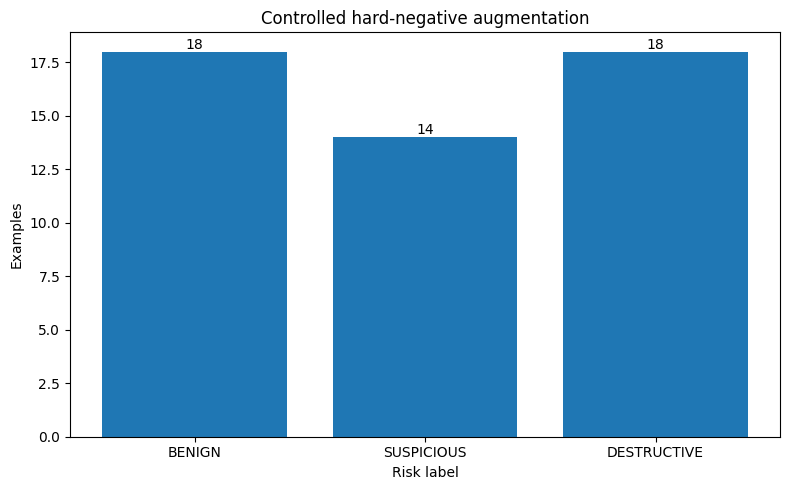

In [41]:
# =========================================================
# CELL 39 — CONTROLLED DESTRUCTIVE AUGMENTATION
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import itertools
import matplotlib.pyplot as plt


# =========================================================
# 1. SAFE PLACEHOLDER COMPONENTS
# =========================================================

TEST_DEVICES = [
    "<TEST_DEVICE>",
    "<TEST_BLOCK_DEVICE>",
    "<LAB_DISK>",
]


CRITICAL_SCOPES = [
    "<CRITICAL_SYSTEM_DIR>",
    "<SYSTEM_ROOT>",
    "<SYSTEM_DATA_DIR>",
]


TEMP_SCOPES = [
    "<TEMP_DIR>",
    "<TEST_WORKDIR>",
    "<SANDBOX_DIR>",
]


# =========================================================
# 2. CONTROLLED TEMPLATE FAMILIES
# =========================================================
#
# Important:
# These use placeholders and are training examples only.
#
# =========================================================

controlled_examples = []


def add_example(
    command,
    risk,
    family,
    boundary_group,
):

    command = normalize_command(
        command
    )


    controlled_examples.append({

        "command":
            command,

        "command_hash":
            command_hash(
                command
            ),

        "risk":
            risk,

        "family":
            family,

        "boundary_group":
            boundary_group,

        "label_source":
            "controlled_boundary",
    })


# =========================================================
# 3. DELETE SCOPE TRIPLETS
# =========================================================

for i, temp_scope in enumerate(
    TEMP_SCOPES,
    start=1,
):

    group = (
        f"controlled_delete_"
        f"{i:03d}"
    )


    add_example(
        "rm <TEST_FILE>",
        "BENIGN",
        "controlled_delete_scope",
        group,
    )


    add_example(
        f"rm -rf {temp_scope}",
        "SUSPICIOUS",
        "controlled_delete_scope",
        group,
    )


    add_example(
        "rm -rf <SYSTEM_ROOT>",
        "DESTRUCTIVE",
        "controlled_delete_scope",
        group,
    )


# =========================================================
# 4. STORAGE BOUNDARIES
# =========================================================

storage_read_templates = [

    "lsblk {device}",

    "blkid {device}",

    "fdisk -l {device}",
]


storage_suspicious_templates = [

    "dd if=<TEST_IMAGE> "
    "of={device} "
    "count=1",

    "wipefs -n {device}",
]


storage_destructive_templates = [

    "mkfs.ext4 {device}",

    "mkfs.xfs {device}",

    "dd if=/dev/zero "
    "of={device}",

    "wipefs -a {device}",
]


group_index = 0


for device in TEST_DEVICES:

    for (
        benign_template,
        suspicious_template,
        destructive_template
    ) in itertools.product(

        storage_read_templates,

        storage_suspicious_templates,

        storage_destructive_templates,
    ):

        group_index += 1


        group = (
            "controlled_storage_"
            f"{group_index:04d}"
        )


        add_example(

            benign_template.format(
                device=device
            ),

            "BENIGN",

            "controlled_storage_boundary",

            group,
        )


        add_example(

            suspicious_template.format(
                device=device
            ),

            "SUSPICIOUS",

            "controlled_storage_boundary",

            group,
        )


        add_example(

            destructive_template.format(
                device=device
            ),

            "DESTRUCTIVE",

            "controlled_storage_boundary",

            group,
        )


# =========================================================
# 5. SYSTEM-SCOPE BOUNDARIES
# =========================================================

system_read_templates = [

    "ls {scope}",

    "du -sh {scope}",

    "find {scope} -maxdepth 1 -type f",
]


system_change_templates = [

    "chmod -R u+rw {scope}",

    "chown -R <TEST_USER> {scope}",
]


system_destructive_templates = [

    "rm -rf {scope}",

    "find {scope} -type f -delete",
]


group_index = 0


for scope in CRITICAL_SCOPES:

    for (
        benign_template,
        suspicious_template,
        destructive_template
    ) in itertools.product(

        system_read_templates,

        system_change_templates,

        system_destructive_templates,
    ):

        group_index += 1


        group = (
            "controlled_system_"
            f"{group_index:04d}"
        )


        add_example(

            benign_template.format(
                scope=scope
            ),

            "BENIGN",

            "controlled_system_scope",

            group,
        )


        add_example(

            suspicious_template.format(
                scope=scope
            ),

            "SUSPICIOUS",

            "controlled_system_scope",

            group,
        )


        add_example(

            destructive_template.format(
                scope=scope
            ),

            "DESTRUCTIVE",

            "controlled_system_scope",

            group,
        )


# =========================================================
# 6. EXACT DEDUP
# =========================================================

seen_hashes = set()

controlled_unique = []


for row in controlled_examples:

    key = row[
        "command_hash"
    ]


    if key in seen_hashes:

        continue


    seen_hashes.add(
        key
    )


    controlled_unique.append(
        row
    )


# =========================================================
# 7. REMOVE DATA ALREADY PRESENT
# =========================================================

existing_rows = (

    load_jsonl(
        TRUSTED_V2_PATH
    )

    +

    load_jsonl(
        SYNTHETIC_VALIDATED_PATH
    )
)


existing_hashes = {
    row["command_hash"]
    for row in existing_rows
}


controlled_final = [
    row
    for row in controlled_unique
    if row[
        "command_hash"
    ] not in existing_hashes
]


# =========================================================
# 8. SAVE
# =========================================================

CONTROLLED_RAW_PATH = (
    f"{SYNTHETIC_DIR}/"
    "controlled_boundary_raw_v1.jsonl"
)


with open(
    CONTROLLED_RAW_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in controlled_final:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 9. SUMMARY
# =========================================================

distribution = Counter(
    row["risk"]
    for row in controlled_final
)


family_distribution = Counter(
    row["family"]
    for row in controlled_final
)


print()
print("=" * 80)
print("CONTROLLED BOUNDARY AUGMENTATION")
print("=" * 80)

print(
    "Generated:",
    len(controlled_examples)
)

print(
    "Unique:",
    len(controlled_unique)
)

print(
    "After existing-dedup:",
    len(controlled_final)
)

print()

print(
    "Distribution:",
    dict(
        distribution
    )
)

print()

print(
    "Families:",
    dict(
        family_distribution
    )
)

print()

print(
    "Saved:",
    CONTROLLED_RAW_PATH
)

print("=" * 80)


# =========================================================
# GRAPH — CONTROLLED LABEL DISTRIBUTION
# =========================================================

labels = RISK_LABELS

values = [
    distribution.get(
        label,
        0
    )
    for label in labels
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    labels,
    values
)

plt.title(
    "Controlled hard-negative augmentation"
)

plt.xlabel(
    "Risk label"
)

plt.ylabel(
    "Examples"
)


for bar, value in zip(
    bars,
    values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()

In [42]:
# =========================================================
# CELL 40 — VALIDATE CONTROLLED BOUNDARY DATA
# CHECKPOINT + RESUME
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================


CONTROLLED_VALIDATION_CHECKPOINT = (
    f"{SYNTHETIC_DIR}/"
    "controlled_validation_checkpoint_v1.jsonl"
)


CONTROLLED_VALIDATED_PATH = (
    f"{SYNTHETIC_DIR}/"
    "controlled_validated_v1.jsonl"
)


controlled_rows = load_jsonl(
    CONTROLLED_RAW_PATH
)


if os.path.exists(
    CONTROLLED_VALIDATION_CHECKPOINT
):

    checkpoint_rows = load_jsonl(
        CONTROLLED_VALIDATION_CHECKPOINT
    )

else:

    checkpoint_rows = []


processed_hashes = {
    row["command_hash"]
    for row in checkpoint_rows
}


print()
print("=" * 70)
print("CONTROLLED DATA VALIDATION")
print("=" * 70)

print(
    "Total:",
    len(controlled_rows)
)

print(
    "Processed:",
    len(processed_hashes)
)

print(
    "Remaining:",
    sum(
        row["command_hash"]
        not in processed_hashes
        for row in controlled_rows
    )
)

print("=" * 70)


try:

    for row in tqdm(
        controlled_rows,
        desc="Controlled validation",
    ):


        if (
            row["command_hash"]
            in processed_hashes
        ):

            continue


        result = (
            validate_synthetic_with_retry(
                row["command"]
            )
        )


        if result["success"]:

            parsed = (
                result["parsed"]
            )


            item = {

                **row,

                "generator_risk":
                    row["risk"],

                "validator_risk":
                    parsed["risk"],

                "validator_confidence":
                    parsed[
                        "confidence"
                    ],

                "validator_ambiguous":
                    parsed[
                        "ambiguous"
                    ],

                "label_match":
                    (
                        row["risk"]
                        == parsed["risk"]
                    ),

                "validation_status":
                    "accepted",
            }


        else:

            item = {

                **row,

                "generator_risk":
                    row["risk"],

                "validator_risk":
                    None,

                "validator_confidence":
                    None,

                "validator_ambiguous":
                    True,

                "label_match":
                    False,

                "validation_status":
                    "api_error",

                "error":
                    result[
                        "error"
                    ],
            }


        append_jsonl(
            CONTROLLED_VALIDATION_CHECKPOINT,
            item
        )


        processed_hashes.add(
            row["command_hash"]
        )


except KeyboardInterrupt:

    print(
        "Interrupted — checkpoint aman."
    )


# =========================================================
# FILTER
# =========================================================

validation_rows = load_jsonl(
    CONTROLLED_VALIDATION_CHECKPOINT
)


VALIDATOR_MIN_CONFIDENCE = 0.80


controlled_trusted = [
    row
    for row in validation_rows
    if (
        row.get(
            "validation_status"
        )
        == "accepted"

        and

        row.get(
            "label_match"
        ) is True

        and

        row.get(
            "validator_ambiguous"
        ) is False

        and

        row.get(
            "validator_confidence",
            0
        ) >= VALIDATOR_MIN_CONFIDENCE
    )
]


with open(
    CONTROLLED_VALIDATED_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in controlled_trusted:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# SUMMARY
# =========================================================

distribution = Counter(
    row["generator_risk"]
    for row in controlled_trusted
)


print()
print("=" * 70)
print("CONTROLLED VALIDATION COMPLETE")
print("=" * 70)

print(
    "Total:",
    len(validation_rows)
)

print(
    "Trusted:",
    len(controlled_trusted)
)

print(
    "Rejected:",
    len(validation_rows)
    - len(controlled_trusted)
)

print(
    "Acceptance rate:",
    round(
        len(controlled_trusted)
        / len(validation_rows),
        4
    )
)

print(
    "Distribution:",
    dict(
        distribution
    )
)

print("=" * 70)


CONTROLLED DATA VALIDATION
Total: 50
Processed: 50
Remaining: 0


Controlled validation:   0%|          | 0/50 [00:00<?, ?it/s]


CONTROLLED VALIDATION COMPLETE
Total: 50
Trusted: 48
Rejected: 2
Acceptance rate: 0.96
Distribution: {'DESTRUCTIVE': 18, 'SUSPICIOUS': 12, 'BENIGN': 18}



COMMAND RISK DATASET V3 — FROZEN
Total: 3504

Labels:
BENIGN      :  2091 ( 59.67%)
SUSPICIOUS  :  1079 ( 30.79%)
DESTRUCTIVE :   334 (  9.53%)

Sources:
real_teacher            : 3129
synthetic_boundary      : 327
controlled_boundary     : 48

Unique groups: 3390
Mean weight: 0.8209
Min weight: 0.544
Max weight: 1.0

Saved: /content/drive/MyDrive/command_risk/trusted/command_risk_dataset_v3.jsonl


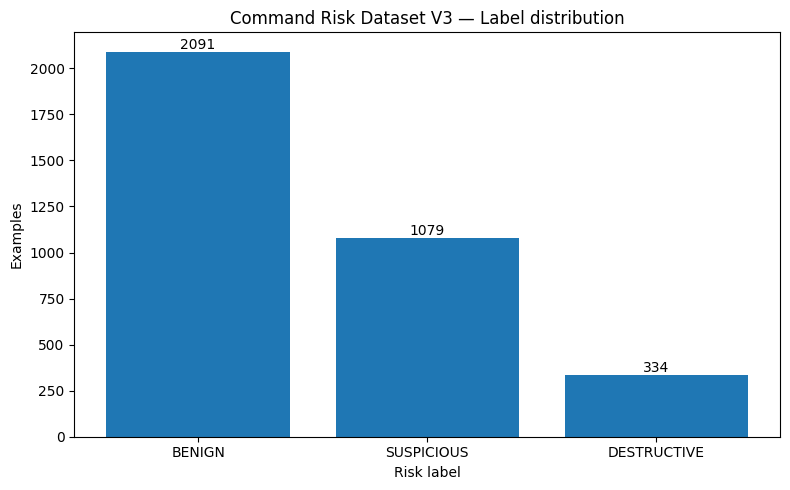

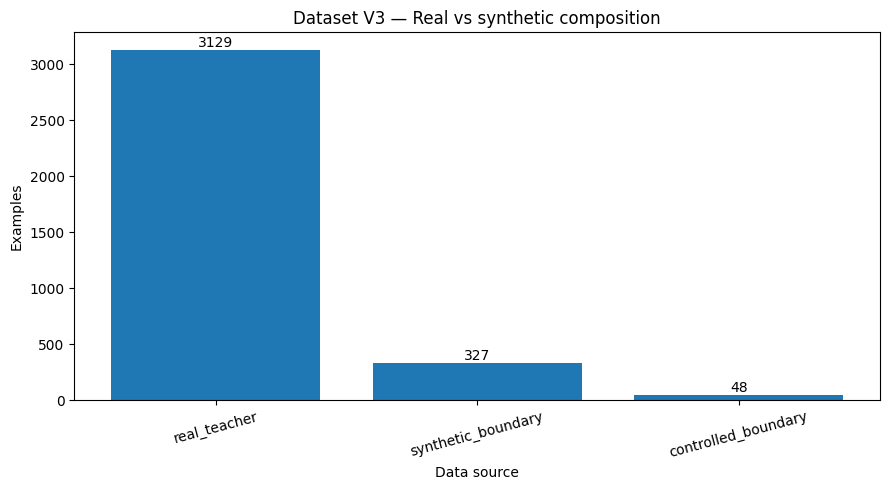

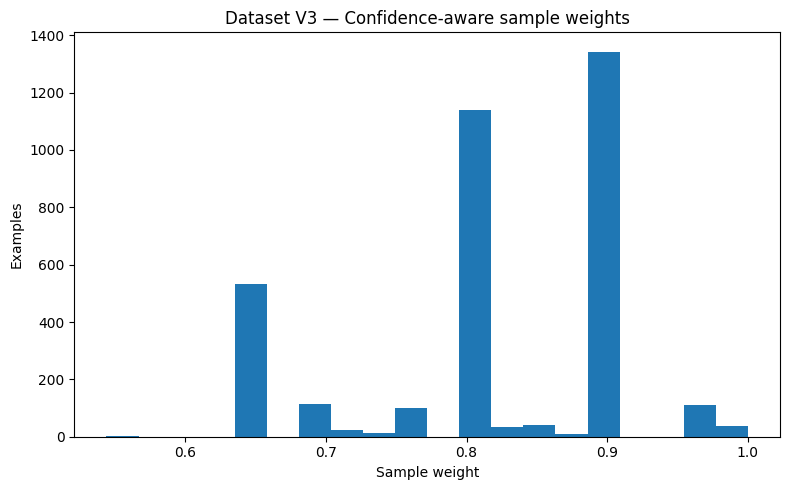

In [43]:
# =========================================================
# CELL 41 — FREEZE COMMAND RISK DATASET V3
# CONFIDENCE-AWARE WEIGHTS + GROUP IDS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import matplotlib.pyplot as plt


# =========================================================
# 1. LOAD SOURCES
# =========================================================

real_rows = load_jsonl(
    TRUSTED_V2_PATH
)


boundary_rows = load_jsonl(
    SYNTHETIC_VALIDATED_PATH
)


controlled_rows = load_jsonl(
    CONTROLLED_VALIDATED_PATH
)


# =========================================================
# 2. NORMALIZE REAL
# =========================================================

final_rows = []


for row in real_rows:

    confidence = float(
        row.get(
            "confidence",
            1.0
        )
    )


    # Confidence-aware teacher weight
    sample_weight = (
        confidence ** 2
    )


    final_rows.append({

        "command":
            row["command"],

        "command_hash":
            row["command_hash"],

        "risk":
            row["risk"],

        "static_features":
            row.get(
                "static_features",
                extract_static_features(
                    row["command"]
                )
            ),

        "source":
            "real_teacher",

        "family":
            None,

        # Each real command is independent.
        "group_id":
            "real::"
            + row[
                "command_hash"
            ],

        "teacher_confidence":
            confidence,

        "sample_weight":
            sample_weight,
    })


# =========================================================
# 3. NORMALIZE LLM BOUNDARY DATA
# =========================================================

for row in boundary_rows:

    confidence = float(
        row[
            "validator_confidence"
        ]
    )


    # Synthetic gets slightly lower base weight.
    sample_weight = (
        0.85
        * (
            confidence ** 2
        )
    )


    final_rows.append({

        "command":
            row["command"],

        "command_hash":
            row["command_hash"],

        "risk":
            row[
                "generator_risk"
            ],

        "static_features":
            extract_static_features(
                row["command"]
            ),

        "source":
            "synthetic_boundary",

        "family":
            row.get(
                "family"
            ),

        "group_id":
            "synthetic::"
            + row.get(
                "boundary_group",
                row[
                    "command_hash"
                ]
            ),

        "teacher_confidence":
            confidence,

        "sample_weight":
            sample_weight,
    })


# =========================================================
# 4. NORMALIZE CONTROLLED DATA
# =========================================================

for row in controlled_rows:

    confidence = float(
        row[
            "validator_confidence"
        ]
    )


    sample_weight = (
        0.90
        * (
            confidence ** 2
        )
    )


    final_rows.append({

        "command":
            row["command"],

        "command_hash":
            row["command_hash"],

        "risk":
            row[
                "generator_risk"
            ],

        "static_features":
            extract_static_features(
                row["command"]
            ),

        "source":
            "controlled_boundary",

        "family":
            row.get(
                "family"
            ),

        "group_id":
            "controlled::"
            + row.get(
                "boundary_group",
                row[
                    "command_hash"
                ]
            ),

        "teacher_confidence":
            confidence,

        "sample_weight":
            sample_weight,
    })


# =========================================================
# 5. FINAL HASH DEDUP
# =========================================================

seen_hashes = set()

dataset_v3 = []


for row in final_rows:

    key = row[
        "command_hash"
    ]


    if key in seen_hashes:

        continue


    seen_hashes.add(
        key
    )

    dataset_v3.append(
        row
    )


# =========================================================
# 6. SAVE
# =========================================================

DATASET_V3_PATH = (
    f"{TRUSTED_DIR}/"
    "command_risk_dataset_v3.jsonl"
)


with open(
    DATASET_V3_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in dataset_v3:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 7. DISTRIBUTIONS
# =========================================================

label_distribution = Counter(
    row["risk"]
    for row in dataset_v3
)


source_distribution = Counter(
    row["source"]
    for row in dataset_v3
)


weights = np.array(
    [
        row["sample_weight"]
        for row in dataset_v3
    ],
    dtype=float,
)


# =========================================================
# 8. SUMMARY
# =========================================================

print()
print("=" * 80)
print("COMMAND RISK DATASET V3 — FROZEN")
print("=" * 80)

print(
    "Total:",
    len(dataset_v3)
)

print()

print(
    "Labels:"
)


for label in RISK_LABELS:

    count = label_distribution.get(
        label,
        0
    )

    print(
        f"{label:<12}: "
        f"{count:>5} "
        f"({count/len(dataset_v3)*100:6.2f}%)"
    )


print()
print(
    "Sources:"
)


for source, count in (
    source_distribution.items()
):

    print(
        f"{source:<24}: "
        f"{count}"
    )


print()

print(
    "Unique groups:",
    len(
        {
            row["group_id"]
            for row in dataset_v3
        }
    )
)

print(
    "Mean weight:",
    round(
        float(
            weights.mean()
        ),
        4
    )
)

print(
    "Min weight:",
    round(
        float(
            weights.min()
        ),
        4
    )
)

print(
    "Max weight:",
    round(
        float(
            weights.max()
        ),
        4
    )
)

print()

print(
    "Saved:",
    DATASET_V3_PATH
)

print("=" * 80)


# =========================================================
# GRAPH 1 — FINAL LABEL DISTRIBUTION
# =========================================================

labels = RISK_LABELS

label_values = [
    label_distribution.get(
        label,
        0
    )
    for label in labels
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    labels,
    label_values
)

plt.title(
    "Command Risk Dataset V3 — Label distribution"
)

plt.xlabel(
    "Risk label"
)

plt.ylabel(
    "Examples"
)


for bar, value in zip(
    bars,
    label_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 2 — SOURCE COMPOSITION
# =========================================================

sources = list(
    source_distribution.keys()
)


source_values = [
    source_distribution[
        source
    ]
    for source in sources
]


plt.figure(
    figsize=(9, 5)
)

bars = plt.bar(
    sources,
    source_values
)

plt.title(
    "Dataset V3 — Real vs synthetic composition"
)

plt.xlabel(
    "Data source"
)

plt.ylabel(
    "Examples"
)


for bar, value in zip(
    bars,
    source_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.xticks(
    rotation=15
)

plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 3 — SAMPLE WEIGHT DISTRIBUTION
# =========================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    weights,
    bins=20
)

plt.title(
    "Dataset V3 — Confidence-aware sample weights"
)

plt.xlabel(
    "Sample weight"
)

plt.ylabel(
    "Examples"
)

plt.tight_layout()

plt.show()

In [ ]:
# =========================================================
# CELL 42 — GROUP-AWARE TRAIN / VALIDATION / TEST SPLIT
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import (
    StratifiedGroupKFold,
)


# =========================================================
# 1. LOAD DATASET V3
# =========================================================

dataset_v3 = load_jsonl(
    DATASET_V3_PATH
)


df = pd.DataFrame(
    dataset_v3
)


print()
print("=" * 80)
print("GROUP-AWARE DATASET SPLIT")
print("=" * 80)

print(
    "Total rows:",
    len(df)
)

print(
    "Unique groups:",
    df["group_id"].nunique()
)


# =========================================================
# 2. FIRST SPLIT
#
# 7-fold:
# ~14.3% becomes TEST
# =========================================================

X_dummy = np.zeros(
    len(df)
)

y_all = df[
    "risk"
].values

groups_all = df[
    "group_id"
].values


outer_splitter = (
    StratifiedGroupKFold(
        n_splits=7,
        shuffle=True,
        random_state=42,
    )
)


outer_splits = list(
    outer_splitter.split(
        X_dummy,
        y_all,
        groups_all,
    )
)


trainval_idx, test_idx = (
    outer_splits[0]
)


trainval_df = (
    df.iloc[
        trainval_idx
    ]
    .reset_index(
        drop=True
    )
)


test_df = (
    df.iloc[
        test_idx
    ]
    .reset_index(
        drop=True
    )
)


# =========================================================
# 3. SECOND SPLIT
#
# Split remaining dataset into:
# TRAIN + VALIDATION
#
# 6 folds of remaining:
# ~1/6 of 85.7% = ~14.3% overall
# =========================================================

inner_splitter = (
    StratifiedGroupKFold(
        n_splits=6,
        shuffle=True,
        random_state=43,
    )
)


inner_X = np.zeros(
    len(trainval_df)
)


inner_splits = list(
    inner_splitter.split(

        inner_X,

        trainval_df[
            "risk"
        ].values,

        trainval_df[
            "group_id"
        ].values,
    )
)


train_idx, val_idx = (
    inner_splits[0]
)


train_df = (
    trainval_df.iloc[
        train_idx
    ]
    .reset_index(
        drop=True
    )
)


val_df = (
    trainval_df.iloc[
        val_idx
    ]
    .reset_index(
        drop=True
    )
)


# =========================================================
# 4. GROUP LEAKAGE CHECK
# =========================================================

train_groups = set(
    train_df[
        "group_id"
    ]
)

val_groups = set(
    val_df[
        "group_id"
    ]
)

test_groups = set(
    test_df[
        "group_id"
    ]
)


assert train_groups.isdisjoint(
    val_groups
)

assert train_groups.isdisjoint(
    test_groups
)

assert val_groups.isdisjoint(
    test_groups
)


# =========================================================
# 5. COMMAND HASH LEAKAGE CHECK
# =========================================================

train_hashes = set(
    train_df[
        "command_hash"
    ]
)

val_hashes = set(
    val_df[
        "command_hash"
    ]
)

test_hashes = set(
    test_df[
        "command_hash"
    ]
)


assert train_hashes.isdisjoint(
    val_hashes
)

assert train_hashes.isdisjoint(
    test_hashes
)

assert val_hashes.isdisjoint(
    test_hashes
)


# =========================================================
# 6. SAVE SPLITS
# =========================================================

TRAIN_V3_PATH = (
    f"{PROCESSED_DIR}/"
    "command_risk_train_v3.jsonl"
)

VAL_V3_PATH = (
    f"{PROCESSED_DIR}/"
    "command_risk_val_v3.jsonl"
)

TEST_V3_PATH = (
    f"{PROCESSED_DIR}/"
    "command_risk_test_v3.jsonl"
)


def save_dataframe_jsonl(
    dataframe,
    path,
):

    with open(
        path,
        "w",
        encoding="utf-8",
    ) as f:

        for record in (
            dataframe
            .to_dict(
                orient="records"
            )
        ):

            f.write(
                json.dumps(
                    record,
                    ensure_ascii=False,
                )
                + "\n"
            )


save_dataframe_jsonl(
    train_df,
    TRAIN_V3_PATH,
)

save_dataframe_jsonl(
    val_df,
    VAL_V3_PATH,
)

save_dataframe_jsonl(
    test_df,
    TEST_V3_PATH,
)


# =========================================================
# 7. REPORT
# =========================================================

def print_split_stats(
    name,
    dataframe,
):

    distribution = Counter(
        dataframe[
            "risk"
        ]
    )


    print()
    print(
        f"[{name}]"
    )

    print(
        "Rows:",
        len(dataframe),
        f"({len(dataframe)/len(df)*100:.2f}%)"
    )

    print(
        "Groups:",
        dataframe[
            "group_id"
        ].nunique()
    )


    for label in RISK_LABELS:

        count = distribution.get(
            label,
            0
        )

        print(
            f"  {label:<12}"
            f"{count:>5} "
            f"({count/len(dataframe)*100:6.2f}%)"
        )


print_split_stats(
    "TRAIN",
    train_df,
)

print_split_stats(
    "VALIDATION",
    val_df,
)

print_split_stats(
    "TEST",
    test_df,
)


print()
print(
    "Group leakage:",
    "PASS"
)

print(
    "Hash leakage :",
    "PASS"
)

print("=" * 80)


# =========================================================
# GRAPH — SPLIT SIZES
# =========================================================

split_names = [
    "Train",
    "Validation",
    "Test",
]

split_sizes = [
    len(train_df),
    len(val_df),
    len(test_df),
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    split_names,
    split_sizes
)

plt.title(
    "Command Risk Dataset V3 — Group-aware split"
)

plt.ylabel(
    "Examples"
)


for bar, value in zip(
    bars,
    split_sizes
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()


GROUP-AWARE DATASET SPLIT
Total rows: 3504
Unique groups: 3390


In [ ]:
# =========================================================
# CELL 43 — TF-IDF WORD + CHARACTER FEATURES
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
)

from scipy.sparse import (
    hstack,
)


# =========================================================
# 1. INPUT TEXT
# =========================================================

X_train_text = (
    train_df[
        "command"
    ].astype(
        str
    )
)

X_val_text = (
    val_df[
        "command"
    ].astype(
        str
    )
)

X_test_text = (
    test_df[
        "command"
    ].astype(
        str
    )
)


# =========================================================
# 2. WORD TF-IDF
# =========================================================

word_vectorizer = (
    TfidfVectorizer(

        analyzer="word",

        ngram_range=(
            1,
            3,
        ),

        min_df=2,

        max_df=0.995,

        sublinear_tf=True,

        lowercase=True,

        max_features=30000,
    )
)


X_train_word = (
    word_vectorizer
    .fit_transform(
        X_train_text
    )
)


X_val_word = (
    word_vectorizer
    .transform(
        X_val_text
    )
)


X_test_word = (
    word_vectorizer
    .transform(
        X_test_text
    )
)


# =========================================================
# 3. CHAR TF-IDF
# =========================================================

char_vectorizer = (
    TfidfVectorizer(

        analyzer="char_wb",

        ngram_range=(
            3,
            6,
        ),

        min_df=2,

        sublinear_tf=True,

        lowercase=True,

        max_features=50000,
    )
)


X_train_char = (
    char_vectorizer
    .fit_transform(
        X_train_text
    )
)


X_val_char = (
    char_vectorizer
    .transform(
        X_val_text
    )
)


X_test_char = (
    char_vectorizer
    .transform(
        X_test_text
    )
)


# =========================================================
# 4. TEXT FEATURE MATRIX
# =========================================================

X_train_text_features = hstack(
    [
        X_train_word,
        X_train_char,
    ],
    format="csr",
)


X_val_text_features = hstack(
    [
        X_val_word,
        X_val_char,
    ],
    format="csr",
)


X_test_text_features = hstack(
    [
        X_test_word,
        X_test_char,
    ],
    format="csr",
)


# =========================================================
# 5. REPORT
# =========================================================

print()
print("=" * 80)
print("TF-IDF FEATURE EXTRACTION")
print("=" * 80)

print(
    "Word vocabulary:",
    len(
        word_vectorizer.vocabulary_
    )
)

print(
    "Char vocabulary:",
    len(
        char_vectorizer.vocabulary_
    )
)

print()

print(
    "Train matrix:",
    X_train_text_features.shape
)

print(
    "Validation:",
    X_val_text_features.shape
)

print(
    "Test:",
    X_test_text_features.shape
)

print("=" * 80)

In [ ]:
# =========================================================
# CELL 44 — STATIC FEATURES + TRAINING WEIGHTS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

from scipy.sparse import (
    csr_matrix,
    hstack,
)

from sklearn.utils.class_weight import (
    compute_class_weight,
)


# =========================================================
# 1. STATIC MATRIX BUILDER
# =========================================================

def dataframe_static_matrix(
    dataframe
):

    matrix = []


    for features in dataframe[
        "static_features"
    ]:

        row = [

            float(
                features.get(
                    feature,
                    0
                )
            )

            for feature
            in STATIC_FEATURE_NAMES
        ]


        matrix.append(
            row
        )


    return csr_matrix(
        np.asarray(
            matrix,
            dtype=np.float32,
        )
    )


# =========================================================
# 2. EXTRACT STATIC FEATURES
# =========================================================

X_train_static = (
    dataframe_static_matrix(
        train_df
    )
)

X_val_static = (
    dataframe_static_matrix(
        val_df
    )
)

X_test_static = (
    dataframe_static_matrix(
        test_df
    )
)


# =========================================================
# 3. COMBINED MATRIX
# =========================================================

X_train_combined = hstack(
    [
        X_train_text_features,
        X_train_static,
    ],
    format="csr",
)


X_val_combined = hstack(
    [
        X_val_text_features,
        X_val_static,
    ],
    format="csr",
)


X_test_combined = hstack(
    [
        X_test_text_features,
        X_test_static,
    ],
    format="csr",
)


# =========================================================
# 4. LABELS
# =========================================================

y_train = (
    train_df[
        "risk"
    ].values
)

y_val = (
    val_df[
        "risk"
    ].values
)

y_test = (
    test_df[
        "risk"
    ].values
)


# =========================================================
# 5. TEACHER SAMPLE WEIGHTS
# =========================================================

teacher_weights = (
    train_df[
        "sample_weight"
    ]
    .astype(
        float
    )
    .values
)


# =========================================================
# 6. CLASS WEIGHTS
# =========================================================

class_weight_values = (
    compute_class_weight(

        class_weight="balanced",

        classes=np.array(
            RISK_LABELS
        ),

        y=y_train,
    )
)


class_weight_map = {

    label:
        float(weight)

    for label, weight
    in zip(
        RISK_LABELS,
        class_weight_values,
    )
}


# =========================================================
# 7. SOFTEN CLASS WEIGHTS
# =========================================================
#
# Full balanced class weights can make the model
# overly aggressive on DESTRUCTIVE.
#
# sqrt() gives a softer correction.
# =========================================================

soft_class_weights = {

    label:
        np.sqrt(
            weight
        )

    for label, weight
    in class_weight_map.items()
}


class_sample_weights = np.array(
    [
        soft_class_weights[
            label
        ]

        for label in y_train
    ],
    dtype=float,
)


# =========================================================
# 8. FINAL SAMPLE WEIGHT
# =========================================================

final_train_weights = (
    teacher_weights
    * class_sample_weights
)


# Normalize mean to 1.0

final_train_weights = (

    final_train_weights
    / final_train_weights.mean()
)


# =========================================================
# 9. REPORT
# =========================================================

print()
print("=" * 80)
print("STATIC FEATURES + TRAINING WEIGHTS")
print("=" * 80)

print(
    "Static features:",
    len(
        STATIC_FEATURE_NAMES
    )
)

print(
    "Combined feature count:",
    X_train_combined.shape[1]
)

print()

print(
    "Raw balanced class weights:"
)

for label in RISK_LABELS:

    print(
        f"{label:<12}:",
        round(
            class_weight_map[
                label
            ],
            4
        )
    )


print()
print(
    "Soft class weights:"
)

for label in RISK_LABELS:

    print(
        f"{label:<12}:",
        round(
            soft_class_weights[
                label
            ],
            4
        )
    )


print()
print(
    "Final sample weight mean:",
    round(
        float(
            final_train_weights.mean()
        ),
        4
    )
)

print(
    "Final sample weight min:",
    round(
        float(
            final_train_weights.min()
        ),
        4
    )
)

print(
    "Final sample weight max:",
    round(
        float(
            final_train_weights.max()
        ),
        4
    )
)

print("=" * 80)


# =========================================================
# GRAPH — FINAL TRAINING WEIGHTS
# =========================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    final_train_weights,
    bins=25
)

plt.title(
    "Command Risk — Final training sample weights"
)

plt.xlabel(
    "Training weight"
)

plt.ylabel(
    "Examples"
)

plt.tight_layout()

plt.show()

In [ ]:
# =========================================================
# CELL 45 — MODEL A BASELINE
# TEXT-ONLY vs TEXT + STATIC
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import time
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import (
    LogisticRegression,
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)


# =========================================================
# 1. TRAIN HELPER
# =========================================================

def train_logistic_model(
    X_train,
    y_train,
    sample_weight,
):

    model = LogisticRegression(

        max_iter=3000,

        solver="liblinear",

        multi_class="ovr",

        C=2.0,

        random_state=42,
    )


    start = time.time()


    model.fit(

        X_train,

        y_train,

        sample_weight=
            sample_weight,
    )


    training_time = (
        time.time()
        - start
    )


    return (
        model,
        training_time
    )


# =========================================================
# 2. TRAIN A1 — TEXT ONLY
# =========================================================

model_a1, time_a1 = (
    train_logistic_model(

        X_train_text_features,

        y_train,

        final_train_weights,
    )
)


# =========================================================
# 3. TRAIN A2 — TEXT + STATIC
# =========================================================

model_a2, time_a2 = (
    train_logistic_model(

        X_train_combined,

        y_train,

        final_train_weights,
    )
)


# =========================================================
# 4. EVALUATION HELPER
# =========================================================

def evaluate_model(
    name,
    model,
    X,
    y,
):

    predictions = (
        model.predict(
            X
        )
    )


    accuracy = (
        accuracy_score(
            y,
            predictions
        )
    )


    precision_macro, (
        recall_macro
    ), f1_macro, _ = (
        precision_recall_fscore_support(

            y,

            predictions,

            average="macro",

            zero_division=0,
        )
    )


    precision_micro, (
        recall_micro
    ), f1_micro, _ = (
        precision_recall_fscore_support(

            y,

            predictions,

            average="micro",

            zero_division=0,
        )
    )


    per_class = (
        classification_report(

            y,

            predictions,

            labels=
                RISK_LABELS,

            output_dict=True,

            zero_division=0,
        )
    )


    cm = confusion_matrix(

        y,

        predictions,

        labels=
            RISK_LABELS,
    )


    return {

        "name":
            name,

        "accuracy":
            accuracy,

        "macro_precision":
            precision_macro,

        "macro_recall":
            recall_macro,

        "macro_f1":
            f1_macro,

        "micro_f1":
            f1_micro,

        "per_class":
            per_class,

        "confusion_matrix":
            cm,

        "predictions":
            predictions,
    }


# =========================================================
# 5. VALIDATION
# =========================================================

result_a1 = evaluate_model(

    "A1 Text only",

    model_a1,

    X_val_text_features,

    y_val,
)


result_a2 = evaluate_model(

    "A2 Text + static",

    model_a2,

    X_val_combined,

    y_val,
)


# =========================================================
# 6. TEXT REPORT
# =========================================================

results = [
    result_a1,
    result_a2,
]


print()
print("=" * 90)
print("MODEL A — BASELINE VALIDATION")
print("=" * 90)


for result in results:

    print()
    print(
        result[
            "name"
        ]
    )

    print(
        "-" * 70
    )

    print(
        "Accuracy :",
        round(
            result[
                "accuracy"
            ],
            4
        )
    )

    print(
        "Macro F1 :",
        round(
            result[
                "macro_f1"
            ],
            4
        )
    )

    print(
        "Micro F1 :",
        round(
            result[
                "micro_f1"
            ],
            4
        )
    )


    for label in RISK_LABELS:

        metrics = (
            result[
                "per_class"
            ][label]
        )

        print(
            f"{label:<12}"
            f" P={metrics['precision']:.3f}"
            f" R={metrics['recall']:.3f}"
            f" F1={metrics['f1-score']:.3f}"
        )


print()
print(
    "Training time A1:",
    round(
        time_a1,
        3
    ),
    "sec"
)

print(
    "Training time A2:",
    round(
        time_a2,
        3
    ),
    "sec"
)

print("=" * 90)


# =========================================================
# 7. SAVE MODELS
# =========================================================

MODEL_A1_PATH = (
    f"{MODEL_DIR}/"
    "command_risk_a1_text.joblib"
)


MODEL_A2_PATH = (
    f"{MODEL_DIR}/"
    "command_risk_a2_text_static.joblib"
)


joblib.dump(
    model_a1,
    MODEL_A1_PATH,
)

joblib.dump(
    model_a2,
    MODEL_A2_PATH,
)


# =========================================================
# GRAPH 1 — MACRO F1 COMPARISON
# =========================================================

model_names = [
    result[
        "name"
    ]
    for result in results
]


macro_scores = [
    result[
        "macro_f1"
    ]
    for result in results
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    model_names,
    macro_scores
)

plt.title(
    "Baseline comparison — Macro F1"
)

plt.ylabel(
    "Macro F1"
)

plt.ylim(
    0,
    1
)


for bar, value in zip(
    bars,
    macro_scores
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{value:.3f}",

        ha="center",
        va="bottom",
    )


plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 2 — PER-CLASS F1
# =========================================================

x = np.arange(
    len(
        RISK_LABELS
    )
)

width = 0.35


a1_f1 = [

    result_a1[
        "per_class"
    ][label][
        "f1-score"
    ]

    for label
    in RISK_LABELS
]


a2_f1 = [

    result_a2[
        "per_class"
    ][label][
        "f1-score"
    ]

    for label
    in RISK_LABELS
]


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    x - width / 2,
    a1_f1,
    width,
    label="Text only",
)

plt.bar(
    x + width / 2,
    a2_f1,
    width,
    label="Text + static",
)


plt.xticks(
    x,
    RISK_LABELS
)

plt.ylim(
    0,
    1
)

plt.title(
    "Baseline validation — F1 by risk class"
)

plt.ylabel(
    "F1"
)

plt.legend()

plt.tight_layout()

plt.show()


# =========================================================
# GRAPH 3 — CONFUSION MATRIX A2
# =========================================================

cm = result_a2[
    "confusion_matrix"
]


plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    cm
)

plt.title(
    "A2 Text + static — Confusion matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)


plt.xticks(
    range(
        len(
            RISK_LABELS
        )
    ),
    RISK_LABELS,
    rotation=30,
)

plt.yticks(
    range(
        len(
            RISK_LABELS
        )
    ),
    RISK_LABELS,
)


for i in range(
    len(
        RISK_LABELS
    )
):

    for j in range(
        len(
            RISK_LABELS
        )
    ):

        plt.text(
            j,
            i,
            str(
                cm[i, j]
            ),

            ha="center",
            va="center",
        )


plt.tight_layout()

plt.show()

In [ ]:
# =========================================================
# CELL 46 — BASELINE ERROR ANALYSIS
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# predictions
val_analysis = val_df.copy()

val_analysis["pred_a1"] = result_a1["predictions"]
val_analysis["pred_a2"] = result_a2["predictions"]

val_analysis["correct_a1"] = (
    val_analysis["risk"]
    == val_analysis["pred_a1"]
)

val_analysis["correct_a2"] = (
    val_analysis["risk"]
    == val_analysis["pred_a2"]
)


# =========================================================
# ERROR COUNTS
# =========================================================

a1_errors = val_analysis[
    ~val_analysis["correct_a1"]
].copy()

a2_errors = val_analysis[
    ~val_analysis["correct_a2"]
].copy()


print()
print("=" * 90)
print("BASELINE ERROR ANALYSIS")
print("=" * 90)

print("A1 errors:", len(a1_errors))
print("A2 errors:", len(a2_errors))


# =========================================================
# CONFUSION PAIRS
# =========================================================

def confusion_pair_counts(
    dataframe,
    prediction_column,
):

    return Counter(
        zip(
            dataframe["risk"],
            dataframe[prediction_column],
        )
    )


a1_pairs = confusion_pair_counts(
    a1_errors,
    "pred_a1",
)

a2_pairs = confusion_pair_counts(
    a2_errors,
    "pred_a2",
)


print()
print("A1 confusion pairs")

for pair, count in (
    a1_pairs.most_common()
):

    print(
        f"{pair[0]:<12} -> "
        f"{pair[1]:<12}: "
        f"{count}"
    )


print()
print("A2 confusion pairs")

for pair, count in (
    a2_pairs.most_common()
):

    print(
        f"{pair[0]:<12} -> "
        f"{pair[1]:<12}: "
        f"{count}"
    )


# =========================================================
# WHERE A2 HELPS / HURTS
# =========================================================

a2_helped = val_analysis[
    (~val_analysis["correct_a1"])
    &
    (val_analysis["correct_a2"])
].copy()


a2_hurt = val_analysis[
    (val_analysis["correct_a1"])
    &
    (~val_analysis["correct_a2"])
].copy()


print()
print("=" * 90)
print("STATIC FEATURE IMPACT")
print("=" * 90)

print(
    "A2 fixed A1 errors:",
    len(a2_helped)
)

print(
    "A2 introduced errors:",
    len(a2_hurt)
)


# =========================================================
# SHOW A2 HURT CASES
# =========================================================

print()
print("SAMPLE — STATIC FEATURES HURT")
print("-" * 90)


for _, row in (
    a2_hurt.head(30).iterrows()
):

    active = [
        k
        for k, v
        in row[
            "static_features"
        ].items()
        if v
    ]

    print()
    print(
        row["risk"],
        "-> A1:",
        row["pred_a1"],
        "| A2:",
        row["pred_a2"]
    )

    print(
        "features:",
        active
    )

    print(
        row["command"]
    )


# =========================================================
# GRAPH — ERROR PAIRS A1
# =========================================================

pair_names = [
    f"{a}→{b}"
    for (a, b), count
    in a1_pairs.most_common()
]

pair_values = [
    count
    for pair, count
    in a1_pairs.most_common()
]


plt.figure(
    figsize=(10, 6)
)

bars = plt.barh(
    pair_names,
    pair_values
)

plt.title(
    "A1 Text-only — Validation error pairs"
)

plt.xlabel(
    "Errors"
)

for bar, value in zip(
    bars,
    pair_values
):

    plt.text(
        bar.get_width(),
        bar.get_y()
        + bar.get_height() / 2,
        f" {value}",
        va="center",
    )

plt.tight_layout()
plt.show()


# =========================================================
# GRAPH — STATIC IMPACT
# =========================================================

impact_names = [
    "A2 fixed A1",
    "A2 hurt A1",
]

impact_values = [
    len(a2_helped),
    len(a2_hurt),
]


plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    impact_names,
    impact_values
)

plt.title(
    "Impact of static features"
)

plt.ylabel(
    "Validation examples"
)

for bar, value in zip(
    bars,
    impact_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# CELL 47 — HARD-NEGATIVE FAILURE MINING
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import matplotlib.pyplot as plt


# =========================================================
# 1. FOCUS ON A1
# =========================================================
#
# A1 is currently the stronger overall baseline.
# =========================================================

focus_errors = a1_errors.copy()


# =========================================================
# 2. IMPORTANT CONFUSION SETS
# =========================================================

suspicious_to_benign = focus_errors[
    (focus_errors["risk"] == "SUSPICIOUS")
    &
    (focus_errors["pred_a1"] == "BENIGN")
].copy()


destructive_to_suspicious = focus_errors[
    (focus_errors["risk"] == "DESTRUCTIVE")
    &
    (focus_errors["pred_a1"] == "SUSPICIOUS")
].copy()


benign_to_suspicious = focus_errors[
    (focus_errors["risk"] == "BENIGN")
    &
    (focus_errors["pred_a1"] == "SUSPICIOUS")
].copy()


suspicious_to_destructive = focus_errors[
    (focus_errors["risk"] == "SUSPICIOUS")
    &
    (focus_errors["pred_a1"] == "DESTRUCTIVE")
].copy()


# =========================================================
# 3. FEATURE SIGNAL ANALYSIS
# =========================================================

def active_feature_counts(
    dataframe
):

    counter = Counter()

    for features in (
        dataframe[
            "static_features"
        ]
    ):

        for name, value in (
            features.items()
        ):

            if value:
                counter[name] += 1

    return counter


failure_sets = {

    "SUSPICIOUS→BENIGN":
        suspicious_to_benign,

    "DESTRUCTIVE→SUSPICIOUS":
        destructive_to_suspicious,

    "BENIGN→SUSPICIOUS":
        benign_to_suspicious,

    "SUSPICIOUS→DESTRUCTIVE":
        suspicious_to_destructive,
}


print()
print("=" * 90)
print("HARD-NEGATIVE FAILURE MINING")
print("=" * 90)


for name, subset in (
    failure_sets.items()
):

    print()
    print(
        name,
        ":",
        len(subset)
    )


    features = (
        active_feature_counts(
            subset
        )
    )


    for feature, count in (
        features.most_common(
            8
        )
    ):

        print(
            f"  {feature:<26}"
            f"{count}"
        )


# =========================================================
# 4. SAVE FAILURE POOL
# =========================================================

FAILURE_POOL_PATH = (
    f"{REPAIR_DIR}/"
    "baseline_failure_pool_v1.jsonl"
)


failure_pool = []


for failure_type, subset in (
    failure_sets.items()
):

    for _, row in (
        subset.iterrows()
    ):

        failure_pool.append({

            "command":
                row["command"],

            "command_hash":
                row[
                    "command_hash"
                ],

            "actual":
                row["risk"],

            "predicted":
                row["pred_a1"],

            "failure_type":
                failure_type,

            "family":
                row.get(
                    "family"
                ),

            "source":
                row.get(
                    "source"
                ),

            "static_features":
                row[
                    "static_features"
                ],
        })


with open(
    FAILURE_POOL_PATH,
    "w",
    encoding="utf-8",
) as f:

    for row in failure_pool:

        f.write(
            json.dumps(
                row,
                ensure_ascii=False,
            )
            + "\n"
        )


# =========================================================
# 5. GRAPH
# =========================================================

failure_names = list(
    failure_sets.keys()
)

failure_values = [
    len(
        failure_sets[name]
    )
    for name in failure_names
]


plt.figure(
    figsize=(10, 5)
)

bars = plt.bar(
    failure_names,
    failure_values
)

plt.title(
    "Priority hard-negative failure pairs"
)

plt.ylabel(
    "Validation errors"
)

plt.xticks(
    rotation=15
)


for bar, value in zip(
    bars,
    failure_values
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",
        va="bottom",
    )


plt.tight_layout()
plt.show()


print()
print(
    "Failure pool saved:",
    FAILURE_POOL_PATH
)

In [ ]:
# =========================================================
# CELL 48 — LOGISTIC REGRESSION PARAMETER SEARCH
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import itertools
import matplotlib.pyplot as plt


# =========================================================
# 1. SEARCH SPACE
# =========================================================

C_VALUES = [
    0.5,
    1.0,
    2.0,
    4.0,
    8.0,
]


CLASS_WEIGHT_ALPHA = [
    0.0,
    0.25,
    0.50,
    0.75,
    1.0,
]


# =========================================================
# 2. RAW CLASS WEIGHTS
# =========================================================

raw_class_weights = (
    class_weight_map
)


# =========================================================
# 3. SEARCH
# =========================================================

search_results = []


for C_value, alpha in (
    itertools.product(
        C_VALUES,
        CLASS_WEIGHT_ALPHA,
    )
):

    # ---------------------------------------------
    # CLASS WEIGHT EXPONENT
    # ---------------------------------------------

    adjusted_weights = {

        label:
            raw_class_weights[
                label
            ] ** alpha

        for label in RISK_LABELS
    }


    class_component = np.array(
        [
            adjusted_weights[
                label
            ]
            for label
            in y_train
        ],
        dtype=float,
    )


    weights = (
        teacher_weights
        * class_component
    )


    weights = (
        weights
        / weights.mean()
    )


    # ---------------------------------------------
    # TRAIN TEXT-ONLY
    # ---------------------------------------------

    model = LogisticRegression(

        max_iter=3000,

        solver="liblinear",

        multi_class="ovr",

        C=C_value,

        random_state=42,
    )


    model.fit(

        X_train_text_features,

        y_train,

        sample_weight=
            weights,
    )


    predictions = model.predict(
        X_val_text_features
    )


    report = classification_report(

        y_val,

        predictions,

        labels=RISK_LABELS,

        output_dict=True,

        zero_division=0,
    )


    macro_f1 = (
        report[
            "macro avg"
        ][
            "f1-score"
        ]
    )


    destructive_recall = (
        report[
            "DESTRUCTIVE"
        ][
            "recall"
        ]
    )


    suspicious_f1 = (
        report[
            "SUSPICIOUS"
        ][
            "f1-score"
        ]
    )


    # ---------------------------------------------
    # COMPOSITE SCORE
    # ---------------------------------------------
    #
    # Macro F1 remains dominant.
    # Destructive recall gets extra importance.
    # ---------------------------------------------

    composite = (

        0.70
        * macro_f1

        +

        0.20
        * destructive_recall

        +

        0.10
        * suspicious_f1
    )


    search_results.append({

        "C":
            C_value,

        "alpha":
            alpha,

        "macro_f1":
            macro_f1,

        "destructive_recall":
            destructive_recall,

        "destructive_f1":
            report[
                "DESTRUCTIVE"
            ][
                "f1-score"
            ],

        "suspicious_f1":
            suspicious_f1,

        "benign_f1":
            report[
                "BENIGN"
            ][
                "f1-score"
            ],

        "accuracy":
            accuracy_score(
                y_val,
                predictions
            ),

        "composite":
            composite,

        "model":
            model,

        "weights":
            weights,
    })


# =========================================================
# 4. RANK
# =========================================================

search_results = sorted(
    search_results,
    key=lambda x:
        x[
            "composite"
        ],
    reverse=True,
)


print()
print("=" * 100)
print("LOGISTIC SEARCH RESULTS — TOP 10")
print("=" * 100)


for rank, row in enumerate(
    search_results[:10],
    start=1,
):

    print(
        f"{rank:02d}. "
        f"C={row['C']:<4} "
        f"alpha={row['alpha']:<4} "
        f"MacroF1={row['macro_f1']:.4f} "
        f"D-R={row['destructive_recall']:.4f} "
        f"D-F1={row['destructive_f1']:.4f} "
        f"S-F1={row['suspicious_f1']:.4f} "
        f"score={row['composite']:.4f}"
    )


BEST_SEARCH_RESULT = (
    search_results[0]
)


print()
print("=" * 100)
print("BEST CONFIG")
print("=" * 100)

print(
    "C:",
    BEST_SEARCH_RESULT[
        "C"
    ]
)

print(
    "Class alpha:",
    BEST_SEARCH_RESULT[
        "alpha"
    ]
)

print(
    "Macro F1:",
    round(
        BEST_SEARCH_RESULT[
            "macro_f1"
        ],
        4
    )
)

print(
    "Destructive recall:",
    round(
        BEST_SEARCH_RESULT[
            "destructive_recall"
        ],
        4
    )
)

print(
    "Destructive F1:",
    round(
        BEST_SEARCH_RESULT[
            "destructive_f1"
        ],
        4
    )
)

print(
    "Suspicious F1:",
    round(
        BEST_SEARCH_RESULT[
            "suspicious_f1"
        ],
        4
    )
)

print("=" * 100)


# =========================================================
# GRAPH — MACRO F1 BY CONFIG
# =========================================================

plot_rows = sorted(
    search_results,
    key=lambda x:
        x[
            "macro_f1"
        ],
    reverse=True,
)[:15]


names = [
    f"C={r['C']}, α={r['alpha']}"
    for r in plot_rows
]

values = [
    r[
        "macro_f1"
    ]
    for r in plot_rows
]


plt.figure(
    figsize=(11, 7)
)

bars = plt.barh(
    names[::-1],
    values[::-1]
)

plt.title(
    "Top Logistic Regression configurations — Macro F1"
)

plt.xlabel(
    "Macro F1"
)


for bar, value in zip(
    bars,
    values[::-1]
):

    plt.text(
        bar.get_width(),
        bar.get_y()
        + bar.get_height() / 2,

        f" {value:.3f}",

        va="center",
    )


plt.tight_layout()
plt.show()


# =========================================================
# GRAPH — DESTRUCTIVE RECALL vs MACRO F1
# =========================================================

plt.figure(
    figsize=(8, 6)
)


for row in search_results:

    plt.scatter(

        row[
            "destructive_recall"
        ],

        row[
            "macro_f1"
        ],
    )


plt.title(
    "Macro F1 vs DESTRUCTIVE recall"
)

plt.xlabel(
    "DESTRUCTIVE recall"
)

plt.ylabel(
    "Macro F1"
)

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# CELL 49 — FREEZE BEST TF-IDF BASELINE + TEST
# MODEL 02 — COMMAND RISK CLASSIFIER
# =========================================================

import joblib
import matplotlib.pyplot as plt


# =========================================================
# 1. BEST CONFIG
# =========================================================

BEST_C = (
    BEST_SEARCH_RESULT[
        "C"
    ]
)

BEST_ALPHA = (
    BEST_SEARCH_RESULT[
        "alpha"
    ]
)


# =========================================================
# 2. REBUILD WEIGHTS
# =========================================================

best_class_weights = {

    label:
        class_weight_map[
            label
        ] ** BEST_ALPHA

    for label
    in RISK_LABELS
}


best_weight_vector = np.array(
    [
        best_class_weights[
            label
        ]
        for label
        in y_train
    ],
    dtype=float,
)


best_train_weights = (
    teacher_weights
    * best_weight_vector
)


best_train_weights = (
    best_train_weights
    / best_train_weights.mean()
)


# =========================================================
# 3. TRAIN FINAL BASELINE
# =========================================================

final_tfidf_model = (
    LogisticRegression(

        max_iter=3000,

        solver="liblinear",

        multi_class="ovr",

        C=BEST_C,

        random_state=42,
    )
)


final_tfidf_model.fit(

    X_train_text_features,

    y_train,

    sample_weight=
        best_train_weights,
)


# =========================================================
# 4. TEST
# =========================================================

test_predictions = (
    final_tfidf_model.predict(
        X_test_text_features
    )
)


test_report = (
    classification_report(

        y_test,

        test_predictions,

        labels=RISK_LABELS,

        output_dict=True,

        zero_division=0,
    )
)


test_accuracy = (
    accuracy_score(
        y_test,
        test_predictions
    )
)


test_macro_f1 = (
    test_report[
        "macro avg"
    ][
        "f1-score"
    ]
)


test_cm = confusion_matrix(

    y_test,

    test_predictions,

    labels=RISK_LABELS,
)


# =========================================================
# 5. REPORT
# =========================================================

print()
print("=" * 90)
print("FINAL TF-IDF BASELINE — HELD-OUT TEST")
print("=" * 90)

print(
    "C:",
    BEST_C
)

print(
    "Class alpha:",
    BEST_ALPHA
)

print(
    "Accuracy:",
    round(
        test_accuracy,
        4
    )
)

print(
    "Macro F1:",
    round(
        test_macro_f1,
        4
    )
)

print()


for label in RISK_LABELS:

    metrics = (
        test_report[
            label
        ]
    )

    print(
        f"{label:<12}"
        f" P={metrics['precision']:.3f}"
        f" R={metrics['recall']:.3f}"
        f" F1={metrics['f1-score']:.3f}"
    )


print("=" * 90)


# =========================================================
# 6. SAVE
# =========================================================

FINAL_TFIDF_MODEL_PATH = (
    f"{MODEL_DIR}/"
    "command_risk_tfidf_final_candidate.joblib"
)


joblib.dump(
    final_tfidf_model,
    FINAL_TFIDF_MODEL_PATH,
)


TFIDF_CONFIG_PATH = (
    f"{MODEL_DIR}/"
    "command_risk_tfidf_config_v1.json"
)


with open(
    TFIDF_CONFIG_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        {
            "C":
                BEST_C,

            "class_weight_alpha":
                BEST_ALPHA,

            "word_ngram":
                [1, 3],

            "char_ngram":
                [3, 6],

            "static_features_used":
                False,
        },
        f,
        indent=2,
    )


# =========================================================
# GRAPH 1 — TEST F1 BY CLASS
# =========================================================

test_f1 = [
    test_report[
        label
    ][
        "f1-score"
    ]
    for label in RISK_LABELS
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    RISK_LABELS,
    test_f1
)

plt.title(
    "Final TF-IDF candidate — Test F1"
)

plt.ylabel(
    "F1"
)

plt.ylim(
    0,
    1
)


for bar, value in zip(
    bars,
    test_f1
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{value:.3f}",

        ha="center",
        va="bottom",
    )


plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 2 — TEST CONFUSION MATRIX
# =========================================================

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    test_cm
)

plt.title(
    "Final TF-IDF candidate — Test confusion matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)


plt.xticks(
    range(
        len(RISK_LABELS)
    ),
    RISK_LABELS,
    rotation=30,
)

plt.yticks(
    range(
        len(RISK_LABELS)
    ),
    RISK_LABELS,
)


for i in range(
    len(RISK_LABELS)
):

    for j in range(
        len(RISK_LABELS)
    ):

        plt.text(
            j,
            i,
            str(
                test_cm[i, j]
            ),

            ha="center",
            va="center",
        )


plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# CELL 50 — SETFIT DEPENDENCIES + DATASET PREPARATION
# MODEL 02 — COMMAND RISK CLASSIFIER
# MODEL B — SETFIT
# =========================================================

!pip install -q \
    setfit \
    sentence-transformers \
    datasets \
    accelerate


import torch
import datasets

from datasets import Dataset

from setfit import (
    SetFitModel,
    Trainer,
    TrainingArguments,
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import matplotlib.pyplot as plt


# =========================================================
# 1. DEVICE CHECK
# =========================================================

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print()
print("=" * 80)
print("SETFIT ENVIRONMENT")
print("=" * 80)

print(
    "Device:",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print(
    "Torch:",
    torch.__version__
)

print("=" * 80)


# =========================================================
# 2. LABEL ENCODING
# =========================================================

LABEL_TO_ID = {
    "BENIGN": 0,
    "SUSPICIOUS": 1,
    "DESTRUCTIVE": 2,
}

ID_TO_LABEL = {
    value: key
    for key, value
    in LABEL_TO_ID.items()
}


# =========================================================
# 3. PREPARE SETFIT DATAFRAME
# =========================================================

def prepare_setfit_dataframe(
    dataframe
):

    result = pd.DataFrame({

        "text":
            dataframe[
                "command"
            ].astype(str),

        "label":
            dataframe[
                "risk"
            ].map(
                LABEL_TO_ID
            ),
    })


    assert (
        result[
            "label"
        ].isna().sum()
        == 0
    )


    result[
        "label"
    ] = result[
        "label"
    ].astype(int)


    return result


setfit_train_df = (
    prepare_setfit_dataframe(
        train_df
    )
)

setfit_val_df = (
    prepare_setfit_dataframe(
        val_df
    )
)

setfit_test_df = (
    prepare_setfit_dataframe(
        test_df
    )
)


# =========================================================
# 4. HF DATASETS
# =========================================================

setfit_train_ds = (
    Dataset.from_pandas(
        setfit_train_df,
        preserve_index=False,
    )
)

setfit_val_ds = (
    Dataset.from_pandas(
        setfit_val_df,
        preserve_index=False,
    )
)

setfit_test_ds = (
    Dataset.from_pandas(
        setfit_test_df,
        preserve_index=False,
    )
)


# =========================================================
# 5. SUMMARY
# =========================================================

print()
print("=" * 80)
print("SETFIT DATASET")
print("=" * 80)

print(
    "Train:",
    len(setfit_train_ds)
)

print(
    "Validation:",
    len(setfit_val_ds)
)

print(
    "Test:",
    len(setfit_test_ds)
)

print()

print(
    "Train distribution:"
)

train_dist = Counter(
    setfit_train_df[
        "label"
    ]
)


for label_id, count in sorted(
    train_dist.items()
):

    print(
        f"{ID_TO_LABEL[label_id]:<12}",
        count
    )

print("=" * 80)

In [ ]:
# =========================================================
# CELL 51 — SETFIT MODEL + TRAINING CONFIGURATION
# MODEL B — SETFIT
# =========================================================


# =========================================================
# 1. BASE MODEL
# =========================================================

SETFIT_BASE_MODEL = (
    "BAAI/bge-small-en-v1.5"
)


SETFIT_OUTPUT_DIR = (
    f"{MODEL_DIR}/"
    "setfit_bge_small_v1"
)


# =========================================================
# 2. MODEL
# =========================================================

setfit_model = (
    SetFitModel.from_pretrained(
        SETFIT_BASE_MODEL,
    )
)


# =========================================================
# 3. TRAINING ARGUMENTS
# =========================================================
#
# Current SetFit API supports:
# - Trainer
# - TrainingArguments
# - sampling_strategy
# - num_epochs
# - body_learning_rate
# - head_learning_rate
#
# Start conservative.
#
# =========================================================

setfit_args = TrainingArguments(

    output_dir=
        SETFIT_OUTPUT_DIR,

    batch_size=16,

    num_epochs=(
        1,
        12,
    ),

    body_learning_rate=(
        2e-5,
        1e-5,
    ),

    head_learning_rate=
        1e-2,

    sampling_strategy=
        "oversampling",

    num_iterations=
        10,

    warmup_proportion=
        0.1,

    use_amp=
        torch.cuda.is_available(),

    seed=
        42,

    report_to=
        "none",

    logging_strategy=
        "steps",

    logging_steps=
        25,

    eval_strategy=
        "epoch",

    save_strategy=
        "epoch",

    save_total_limit=
        2,

    load_best_model_at_end=
        True,
)


# =========================================================
# 4. CUSTOM METRIC
# =========================================================

def setfit_metrics(
    y_pred,
    y_true,
):

    y_pred = np.asarray(
        y_pred
    )

    y_true = np.asarray(
        y_true
    )


    return {

        "accuracy":
            accuracy_score(
                y_true,
                y_pred,
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),
    }


# =========================================================
# 5. TRAINER
# =========================================================

setfit_trainer = Trainer(

    model=
        setfit_model,

    args=
        setfit_args,

    train_dataset=
        setfit_train_ds,

    eval_dataset=
        setfit_val_ds,

    metric=
        setfit_metrics,
)


# =========================================================
# 6. STATUS
# =========================================================

print()
print("=" * 80)
print("SETFIT MODEL READY")
print("=" * 80)

print(
    "Base model:",
    SETFIT_BASE_MODEL
)

print(
    "Output:",
    SETFIT_OUTPUT_DIR
)

print(
    "AMP:",
    torch.cuda.is_available()
)

print(
    "Embedding epochs:",
    1
)

print(
    "Classifier epochs:",
    12
)

print(
    "Sampling:",
    "oversampling"
)

print("=" * 80)

In [ ]:
# =========================================================
# CELL 52 — TRAIN SETFIT
# MODEL B — SETFIT
# =========================================================

import time


print()
print("=" * 80)
print("TRAINING SETFIT MODEL")
print("=" * 80)


start_time = time.time()


setfit_trainer.train()


training_seconds = (
    time.time()
    - start_time
)


# =========================================================
# SAVE FINAL MODEL
# =========================================================

SETFIT_FINAL_PATH = (
    f"{MODEL_DIR}/"
    "setfit_bge_small_final"
)


setfit_model.save_pretrained(
    SETFIT_FINAL_PATH
)


# =========================================================
# EVALUATE VALIDATION
# =========================================================

validation_metrics = (
    setfit_trainer.evaluate()
)


print()
print("=" * 80)
print("SETFIT TRAINING COMPLETE")
print("=" * 80)

print(
    "Training time:",
    round(
        training_seconds / 60,
        2
    ),
    "minutes"
)

print()

print(
    "Validation metrics:"
)

for key, value in (
    validation_metrics.items()
):

    if isinstance(
        value,
        float
    ):

        print(
            f"{key:<30}",
            round(
                value,
                4
            )
        )

    else:

        print(
            f"{key:<30}",
            value
        )


print()
print(
    "Saved:",
    SETFIT_FINAL_PATH
)

print("=" * 80)

In [ ]:
# =========================================================
# CELL 53 — SETFIT VALIDATION EVALUATION
# MODEL B — SETFIT
# =========================================================

import matplotlib.pyplot as plt


# =========================================================
# 1. PREDICT VALIDATION
# =========================================================

setfit_val_predictions_raw = (
    setfit_model.predict(
        setfit_val_df[
            "text"
        ].tolist()
    )
)


setfit_val_predictions = np.asarray(
    setfit_val_predictions_raw,
    dtype=int,
)


setfit_val_true = (
    setfit_val_df[
        "label"
    ].values
)


# =========================================================
# 2. REPORT
# =========================================================

setfit_val_report = (
    classification_report(

        setfit_val_true,

        setfit_val_predictions,

        labels=[
            0,
            1,
            2,
        ],

        target_names=
            RISK_LABELS,

        output_dict=True,

        zero_division=0,
    )
)


setfit_val_accuracy = (
    accuracy_score(
        setfit_val_true,
        setfit_val_predictions,
    )
)


setfit_val_macro_f1 = (
    setfit_val_report[
        "macro avg"
    ][
        "f1-score"
    ]
)


setfit_val_cm = (
    confusion_matrix(

        setfit_val_true,

        setfit_val_predictions,

        labels=[
            0,
            1,
            2,
        ],
    )
)


# =========================================================
# 3. TEXT REPORT
# =========================================================

print()
print("=" * 90)
print("MODEL B — SETFIT VALIDATION")
print("=" * 90)

print(
    "Accuracy:",
    round(
        setfit_val_accuracy,
        4
    )
)

print(
    "Macro F1:",
    round(
        setfit_val_macro_f1,
        4
    )
)

print()


for label in RISK_LABELS:

    metrics = (
        setfit_val_report[
            label
        ]
    )


    print(
        f"{label:<12}"
        f" P={metrics['precision']:.3f}"
        f" R={metrics['recall']:.3f}"
        f" F1={metrics['f1-score']:.3f}"
    )


print("=" * 90)


# =========================================================
# GRAPH 1 — TF-IDF vs SETFIT MACRO F1
# =========================================================

comparison_names = [
    "TF-IDF A1",
    "SetFit",
]


comparison_macro_f1 = [

    result_a1[
        "macro_f1"
    ],

    setfit_val_macro_f1,
]


plt.figure(
    figsize=(8, 5)
)

bars = plt.bar(
    comparison_names,
    comparison_macro_f1,
)

plt.title(
    "Validation Macro F1 — TF-IDF vs SetFit"
)

plt.ylabel(
    "Macro F1"
)

plt.ylim(
    0,
    1
)


for bar, value in zip(
    bars,
    comparison_macro_f1
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height(),

        f"{value:.3f}",

        ha="center",
        va="bottom",
    )


plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 2 — PER-CLASS F1 COMPARISON
# =========================================================

tfidf_f1 = [

    result_a1[
        "per_class"
    ][label][
        "f1-score"
    ]

    for label
    in RISK_LABELS
]


setfit_f1 = [

    setfit_val_report[
        label
    ][
        "f1-score"
    ]

    for label
    in RISK_LABELS
]


x = np.arange(
    len(
        RISK_LABELS
    )
)

width = 0.35


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    x - width / 2,
    tfidf_f1,
    width,
    label="TF-IDF",
)

plt.bar(
    x + width / 2,
    setfit_f1,
    width,
    label="SetFit",
)


plt.xticks(
    x,
    RISK_LABELS
)

plt.ylim(
    0,
    1
)

plt.title(
    "Validation F1 by risk class"
)

plt.ylabel(
    "F1"
)

plt.legend()

plt.tight_layout()
plt.show()


# =========================================================
# GRAPH 3 — SETFIT CONFUSION MATRIX
# =========================================================

plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    setfit_val_cm
)

plt.title(
    "SetFit — Validation confusion matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)


plt.xticks(
    range(
        len(
            RISK_LABELS
        )
    ),
    RISK_LABELS,
    rotation=30,
)

plt.yticks(
    range(
        len(
            RISK_LABELS
        )
    ),
    RISK_LABELS,
)


for i in range(
    len(
        RISK_LABELS
    )
):

    for j in range(
        len(
            RISK_LABELS
        )
    ):

        plt.text(
            j,
            i,
            str(
                setfit_val_cm[
                    i,
                    j
                ]
            ),

            ha="center",
            va="center",
        )


plt.tight_layout()
plt.show()